# 888102 — From Raw Data to Insight
## Chapter 6 · Data Preparation  +  Chapter 7 · Data Visualization

**Course 888102** · International College of Digital Innovation, Chiang Mai University
· Lecture material by Piyachat Udomwong, Ph.D.

Welcome! This single notebook is the **complete classroom material** for two
connected chapters of the course. Everything from the lecture slides is inside —
the theory, every example, and the graded homework — so in class we work here,
and you read the PDF slides at home as a summary/review.

> 📖 **Self-study slides:** `Chapter_06_Data_Preparation_2023.pdf` and
> `Chapter_07_Data_Visualisation.pdf` (provided separately). Read them before or
> after class — every slide's content appears in this notebook with runnable code.

## Where we are in the course

| Chapter | Topic | Material |
|---|---|---|
| 1 | Overview of Big Data | slides |
| 2 | Data | slides |
| 3 | Big Data | slides |
| 4 | Business problems and data science solutions | slides |
| 5 | Big Data technology | slides |
| **6** | **Data preparation** | **this notebook — Part I** |
| **7** | **Data visualization** | **this notebook — Part II** |
| 8 | Statistics and probability | slides |
| 9 | Machine learning | slides |
| 10 | Supervised learning (regression & classification) | slides |
| 11 | Unsupervised learning | slides |
| 12 | Text mining | slides |

Chapters 6 and 7 belong together because they are two consecutive steps of the
**data science pipeline** you saw in Chapter 4:

```
 collect data          PREPARE the data         VISUALIZE & explore        model / decide
(Chapters 1-5)   →   Part I  = Chapter 6   →   Part II = Chapter 7   →   (Chapters 8-12)
```

Raw data is never clean (Part I fixes that), and clean data is just numbers until
you can *see* it (Part II fixes that). By the end of this notebook you will have
walked a dataset all the way from messy spreadsheet to finished chart.

## Contents

**[Part I — Chapter 6: Data Preparation](#Part-I-—-Chapter-6:-Data-Preparation)**
theory of data quality → hands-on cleaning with pandas → **Homework A**

**[Part II — Chapter 7: Data Visualization](#Part-II-—-Chapter-7:-Data-Visualization)**
chart types for numerical & categorical data → how to choose a chart → **Homework B**

> **How to use this notebook:** run every cell in order (press `Shift + Enter`).
> Read the explanation, run the code, and look carefully at the result. Small
> **"✏️ Try it"** challenges are scattered throughout — do them, they are the
> fastest way to learn!


# Part I — Chapter 6: Data Preparation

*(self-study slides: `Chapter_06_Data_Preparation_2023.pdf`)*

## Learning objectives

By the end of Part I you will be able to:

1. **Understand the concept** of data preparation.
2. **Know the tools** for data preparation (pandas!).
3. **Select and use** the right tool to fix each kind of data problem.

## Part I outline

1. What is data preparation?
2. Getting started — the tools
3. **Data quality dimensions** — accuracy, completeness, consistency, timeliness, validity, uniqueness, conformity
4. **Most common data problems**
   - 4.1 Missing values — ignore, fill, predict · 4.1b why the data is missing (MCAR / MAR / MNAR)
   - 4.2 Inconsistent formatting · 4.2b cleaning free-text categories
   - 4.3 Duplicates · 4.4 Inconsistent datatypes
   - 4.5 **Outliers** — identify, explain, then decide
   - 4.6 **Merging several sources** — concat vs. merge, and how row counts betray a bad join
5. **Encoding categorical data** — one-hot, ordinal, the dummy variable trap, high cardinality
6. **Normalization and standardization** — why scaling matters, robust scaling, and data leakage
7. Summary — a cleaning checklist, a worked end-to-end pipeline, glossary, and a self-check quiz
8. [**Homework A**](#8.-Homework) 📝


## 1. What is data preparation?

> *"No data is clean, but most is useful."* — Dean Abbott, Chief Data Scientist at SmarterHQ

**Data preparation** (also called **data wrangling** or **data preprocessing**) is
the process of preparing raw data so that it is suitable for further processing
and analysis.

The most common data preparation tasks are:

- **Merging** several data sources into one dataset for analysis
- **Identifying gaps** (empty cells) in data and either filling or removing them
- **Deleting** irrelevant or unnecessary data
- **Identifying severe outliers** and either explaining the inconsistencies or deleting them

### Why does it matter?

Data preparation ensures **data integrity** — the accuracy, completeness, and
quality of data as it is maintained over time and across formats. Data integrity
is vital because it is the only way to make sure the data is **good enough to make
decisions upon**. If you analyze dirty data, you get wrong answers — no matter how
fancy your charts or models are. This idea has a famous nickname:
**"garbage in, garbage out."**


## 2. Getting started — the tools

In this course our data preparation tool is Python's **pandas** library — the same
library we use to hold tables of data everywhere else. A few pandas methods will do
almost all of the cleaning work for us:

| Problem | pandas tool |
|---|---|
| find missing values | `df.isna()`, `df.isna().sum()` |
| remove missing values | `df.dropna()` |
| fill missing values | `df.fillna(...)` |
| find duplicates | `df.duplicated()` |
| remove duplicates | `df.drop_duplicates()` |
| fix text | `df["col"].str.replace(...)`, `.str.strip()` |
| fix dates | `pd.to_datetime(...)` |
| fix numbers stored as text | `pd.to_numeric(...)`, `df["col"].astype(...)` |
| encode categories | `pd.get_dummies(...)`, `.map(...)` |

Run the cell below first — everything else depends on it.


In [1]:
# Import the libraries (run this cell first — everything below depends on it!)
import numpy as np                 # numbers and math
import pandas as pd                # tables of data ("DataFrames")
import matplotlib.pyplot as plt   # drawing charts
import seaborn as sns              # prettier charts + example datasets

sns.set_theme(style="whitegrid")   # a clean look for every chart
pd.set_option("display.max_columns", None)  # always show every column
print("Libraries ready!")

Libraries ready!


## 3. Data quality dimensions

Data quality dimensions are **the characteristics against which we measure quality
to ensure that data is trustworthy**. The lecture lists seven of them:

| # | Dimension | One-line meaning |
|---|---|---|
| 1 | **Accuracy** | values match the real world (or an agreed-upon source) |
| 2 | **Completeness** | no required values are missing |
| 3 | **Consistency** | the same fact agrees across different datasets |
| 4 | **Timeliness** | data is recorded and available without a long delay |
| 5 | **Validity** | values come from the set of allowed values |
| 6 | **Uniqueness** | each real-world thing appears only once |
| 7 | **Conformity** | values of one attribute all use the same format and type |

Let's reproduce the lecture's example for each dimension in pandas.


### 3.1 Accuracy

*Data accuracy is the degree to which data represent real-world things, events,
or an agreed-upon source.*

The lecture's example: person A's birth date is **December 13, 1941**, and the
database expects **USA-format dates (MM/DD/YYYY)**.

- `12/13/1941` ✅ correct
- `12/14/1941` ❌ wrong date (December 14 is not A's birthday)
- `13/12/1941` ❌ European format (day first) — there is no month 13!


In [2]:
# Three recorded versions of A's birth date — only the first one is accurate
recorded = pd.Series(["12/13/1941", "12/14/1941", "13/12/1941"], name="BIRTH_DATE")

# Ask pandas to read them as USA-format dates (MM/DD/YYYY).
# errors="coerce" means: if a value is impossible, replace it with NaT ("not a time").
parsed = pd.to_datetime(recorded, format="%m/%d/%Y", errors="coerce")

pd.DataFrame({"recorded": recorded, "parsed as USA date": parsed})

,recorded,parsed as USA date
0,12/13/1941,1941-12-13
1,12/14/1941,1941-12-14
2,13/12/1941,NaT


**How to read it:** `13/12/1941` became `NaT` — the computer *can* catch it,
because month 13 does not exist. But `12/14/1941` parsed without any error even
though it is the wrong birthday! **Accuracy problems often cannot be detected by
the computer alone** — you need to compare against the real world or a trusted
reference source, like below.


In [3]:
# The lecture's Thailand airports table — one Location was typed incorrectly
airports = pd.DataFrame({
    "Airport": ["Suvarnabhumi Airport", "Don Mueang International Airport",
                "Phuket International Airport", "Chiang Mai International Airport",
                "Hat Yai International Airport", "Mae Fah Luang Chiang Rai International Airport"],
    "Location": ["Bangkok (Bang Phli, Samut Prakan)", "Bangkok", "Phuket",
                 "Chiang Rai",   # <-- the error from the slide: CNX is in Chiang Mai!
                 "Songkhla", "Chiang Rai"],
    "IATA": ["BKK", "DMK", "HKT", "CNX", "HDY", "CEI"],
})

# A trusted reference source: the official IATA -> city list
reference = {"BKK": "Bangkok (Bang Phli, Samut Prakan)", "DMK": "Bangkok",
             "HKT": "Phuket", "CNX": "Chiang Mai", "HDY": "Songkhla",
             "CEI": "Chiang Rai"}

# Compare every row against the reference and flag the mismatches
airports["expected"] = airports["IATA"].map(reference)
airports["accurate?"] = airports["Location"] == airports["expected"]
airports

,Airport,Location,IATA,expected,accurate?
0,Suvarnabhumi Airport,"Bangkok (Bang Phli, Samut Prakan)",BKK,"Bangkok (Bang Phli, Samut Prakan)",True
1,Don Mueang International Airport,Bangkok,DMK,Bangkok,True
2,Phuket International Airport,Phuket,HKT,Phuket,True
3,Chiang Mai International Airport,Chiang Rai,CNX,Chiang Mai,False
4,Hat Yai International Airport,Songkhla,HDY,Songkhla,True
5,Mae Fah Luang Chiang Rai International Airport,Chiang Rai,CEI,Chiang Rai,True


**How to read it:** row 3 has `accurate? = False` — Chiang Mai International
Airport (CNX) was recorded as located in *Chiang Rai*. Comparing against a
trusted reference table is the standard way to check accuracy.

> ✏️ **Try it:** change the wrong `"Chiang Rai"` in row 3 to `"Chiang Mai"` in the
> code above and re-run the cell. Every row should now say `True`.


### 3.2 Completeness

*All required records and values should be available with no missing information.*

The lecture's example: a table of Chiang Mai postcodes where one district name is
missing.


In [4]:
# Chiang Mai postcode table from the lecture — the district for 50140 is missing
postcodes = pd.DataFrame({
    "Postcode": ["50000", "50110", "50120", "50130", "50130", "50140",
                 "50150", "50160", "50160", "50170", "50180", "50190"],
    "District": ["Muang Chiang Mai", "Fang", "San Pa Tong", "San Kamphaeng",
                 "Mae On", np.nan,        # <-- the missing value (shown as "?" on the slide)
                 "Mae Taeng", "Doi Lor", "Chom Thong", "Chiang Dao", "Mae Rim", "Phrao"],
    "Province": ["Chiang Mai"] * 12,
})

# isna() marks every missing cell with True; .sum() counts them per column
print("Missing values per column:")
print(postcodes.isna().sum())

# Show only the incomplete rows
postcodes[postcodes["District"].isna()]

Missing values per column:
Postcode    0
District    1
Province    0
dtype: int64


,Postcode,District,Province
5,50140,NaN,Chiang Mai


**How to read it:** `isna().sum()` is the fastest "health check" for any dataset —
one line tells you how many values are missing in every column. Here the row with
postcode 50140 has no district (it should be *Saraphi*). We will learn what to
**do** about missing values in section 4.1.


### 3.3 Consistency

*Consistent data can be explained as how closely your data aligns with another
dataset or a reference dataset.*

The lecture's example: students' grades reported by **two different sources** —
and the grade of student `430` does not agree.


In [5]:
# Source 1: the full gradebook
gradebook = pd.DataFrame({
    "ID": [423, 424, 430],
    "Student Name": ["Thomas Goldman", "Angela Lee", "Freddy Smith"],
    "Score": [95, 84, 75],
    "Grade": ["A", "B+", "B"],
})

# Source 2: the grades published on the announcement board
announced = pd.DataFrame({
    "ID": [423, 424, 430],
    "Grade": ["A", "B+", "A"],   # <-- student 430 got "A" here, but "B" above!
})

# Merge the two sources on the student ID, then compare the two grade columns
check = gradebook.merge(announced, on="ID", suffixes=("_gradebook", "_announced"))
check["consistent?"] = check["Grade_gradebook"] == check["Grade_announced"]
check

,ID,Student Name,Score,Grade_gradebook,Grade_announced,consistent?
0,423,Thomas Goldman,95,A,A,True
1,424,Angela Lee,84,B+,B+,True
2,430,Freddy Smith,75,B,A,False


**How to read it:** merging the two sources on the shared key (`ID`) puts both
versions of the grade side by side, and a simple `==` comparison exposes the
disagreement: student 430 is a **B** in the gradebook but an **A** on the board.
Which one is right? The data alone cannot tell you — you must go back to the
source. That is what consistency checks are for: they *find* the conflicts.


### 3.4 Timeliness

*Timeliness is the time lag between the actual event time and the moment the
event is captured in a system and made available for use.*

Two examples from the lecture:

- A table of country leaders that still lists **Barack Obama** (USA) and
  **Stephen Harper** (Canada) — the data was correct once, but it is **outdated**.
- A pizza restaurant promises delivery within 50 minutes, but the order clerk
  enters the order **two hours late**. Every value in the database is *correct* —
  yet the pizza arrives late and the customer is angry. The problem is not
  accuracy; it is **timeliness**.


In [6]:
# The lecture's outdated leaders table, plus a column recording when it was updated
leaders = pd.DataFrame({
    "country": ["USA", "Canada"],
    "leader": ["Barack Obama", "Stephen Harper"],
    "last_updated": pd.to_datetime(["2014-06-01", "2014-06-01"]),
})

# How old is this data right now?
age_in_years = (pd.Timestamp.today() - leaders["last_updated"]).dt.days / 365
leaders["data age (years)"] = age_in_years.round(1)
leaders

,country,leader,last_updated,data age (years)
0,USA,Barack Obama,2014-06-01,12.3
1,Canada,Stephen Harper,2014-06-01,12.3


**How to read it:** every value in this table *was* accurate when it was written —
but the data is many years old, and both leaders have changed since. Storing a
`last_updated` timestamp with your data is the practical way to measure timeliness.


### 3.5 Validity

*Data validity describes the closeness of a data value to predetermined values or
a calculation.*

The lecture's example: a Thai postcode is valid only if it matches the expected
pattern — **exactly 5 digits**, and for Chiang Mai province it must start with
**50**. Two rows on the slide break the rule: `501400` (6 digits) and `55160`
(wrong prefix).


In [7]:
# The postcode column from the lecture, including the two invalid entries
postcodes2 = pd.DataFrame({
    "Postcode": ["50000", "50110", "50120", "50130", "50130", "501400",
                 "50150", "50160", "55160", "50170", "50180", "50190"],
    "District": ["Muang Chiang Mai", "Fang", "San Pa Tong", "San Kamphaeng",
                 "Mae On", "Saraphi", "Mae Taeng", "Doi Lor", "Chom Thong",
                 "Chiang Dao", "Mae Rim", "Phrao"],
})

# The validity rule: "50" followed by exactly 3 more digits (5 digits in total).
# str.match() tests every value against this pattern and returns True/False.
postcodes2["valid?"] = postcodes2["Postcode"].str.match(r"^50\d{3}$")

# Show the rows that break the rule
postcodes2[~postcodes2["valid?"]]

,Postcode,District,valid?
5,501400,Saraphi,False
8,55160,Chom Thong,False


**How to read it:** the rule caught exactly the two rows highlighted on the slide —
`501400` has six digits and `55160` does not start with 50. Validity checks are
easy to automate because the rule is known **in advance** (a list of allowed
values, a range, or a pattern like this one).

> ✏️ **Try it:** add a made-up postcode like `"5A160"` to the list and re-run the
> cell. Does the rule catch it?


### 3.6 Uniqueness

*Uniqueness is violated when the occurrence of an object or an event gets
recorded multiple times in a dataset.*

The lecture shows two different situations, both about the same student:

1. **Same entity, different identities** — "Freddy Smith" (ID 430) and
   "Fred Smith" (ID 480) are two records, but only one student exists.
2. **Same entity, same identity** — the record for ID 430 appears twice,
   character for character.


In [8]:
# Case 2 first: the exact same record entered twice
students = pd.DataFrame({
    "ID": [430, 430],
    "Student Name": ["Freddy Smith", "Freddy Smith"],
    "Score": [75, 75],
    "Grade": ["B", "B"],
})
print("Exact duplicates found:", students.duplicated().sum())
print("After drop_duplicates():")
students.drop_duplicates()

Exact duplicates found: 1
After drop_duplicates():


,ID,Student Name,Score,Grade
0,430,Freddy Smith,75,B


In [9]:
# Case 1: the same student hiding behind two different identities
students2 = pd.DataFrame({
    "ID": [430, 480],
    "Student Name": ["Freddy Smith", "Fred Smith"],
    "Score": [75, 75],
    "Grade": ["B", "B"],
})
print("Exact duplicates found:", students2.duplicated().sum())  # 0 — pandas sees 2 different rows!
students2

Exact duplicates found: 0


,ID,Student Name,Score,Grade
0,430,Freddy Smith,75,B
1,480,Fred Smith,75,B


**How to read it:** `duplicated()` / `drop_duplicates()` handle the easy case
(identical rows) in one line. But "Freddy Smith" vs "Fred Smith" with different
IDs looks like two valid records to the computer — finding these *hidden*
duplicates needs extra evidence (same birth date? same address?) and often a
human decision. This is called **entity resolution**, and it is one of the
hardest parts of real-world data cleaning.


### 3.7 Conformity

*Conformity means that the data values of the same attribute must be represented
in a uniform format and data type.*

The lecture's example: an orders table where every customer's date — and one
amount — is written in a different style.


In [10]:
# The lecture's orders table: three date styles and one amount written in words
orders = pd.DataFrame({
    "Customer": ["Don", "Joe", "Tim"],
    "Order Dt": ["2019/2/12",            # YYYY/M/DD
                 "12/24/2019",           # MM/DD/YYYY  <- the expected format
                 "2019/2/12 22:09:01"],  # YYYY/M/DD HH:MM:SS
    "Order Amt": ["$100", "Five Hundred Dollars", "$300"],
})
orders

,Customer,Order Dt,Order Amt
0,Don,2019/2/12,$100
1,Joe,12/24/2019,Five Hundred Dollars
2,Tim,2019/2/12 22:09:01,$300


**How to read it:** each row *individually* makes sense to a human, but a computer
program expecting `MM/DD/YYYY` dates and numeric amounts will crash or — worse —
silently misread them. Section 4.2 shows how to repair exactly this table.

That completes the seven quality dimensions. Now let's get our hands dirty and
**fix** the most common problems.


## 4. Most common data problems

The lecture names four problems you will meet in almost every real dataset:

1. **Missing values**
2. **Inconsistent formatting**
3. **Duplicates**
4. **Inconsistent datatypes**

For each one: what it looks like, and the pandas tools that fix it.


### 4.1 Missing values

*Missing or incomplete data are errors where the data do not represent the true
values of what the variables are set out to measure.*

The lecture's example: an ice-cream shop recorded the temperature every day, but
forgot to record **sales for days 1–4**. The two classic strategies are:

- **Ignore** the missing values — drop the rows (or the whole column).
- **Fill in** the missing values — with a typical value (mean, median, most
  frequent) or by **predicting** them with an algorithm.


In [11]:
# The ice-cream table from the lecture slide — sales are missing for days 1-4
icecream = pd.DataFrame({
    "Day": range(1, 13),
    "Temperature (C)": [14.2, 16.4, 11.9, 15.2, 18.5, 22.1,
                        19.4, 25.1, 23.4, 18.1, 22.6, 17.2],
    "Ice Cream Sales ($)": [np.nan, np.nan, np.nan, np.nan, 406, 522,
                            412, 614, 544, 421, 445, 408],
})
print("Missing values per column:")
print(icecream.isna().sum())
icecream

Missing values per column:
Day                    0
Temperature (C)        0
Ice Cream Sales ($)    4
dtype: int64


,Day,Temperature (C),Ice Cream Sales ($)
0,1,14.2,NaN
1,2,16.4,NaN
2,3,11.9,NaN
3,4,15.2,NaN
4,5,18.5,406.0
5,6,22.1,522.0
6,7,19.4,412.0
7,8,25.1,614.0
8,9,23.4,544.0
9,10,18.1,421.0


In [12]:
# Strategy 1 — IGNORE: drop every row that has any missing value
dropped = icecream.dropna()
print("Rows before:", len(icecream), " ->  after dropna():", len(dropped))
dropped

Rows before: 12  ->  after dropna(): 8


,Day,Temperature (C),Ice Cream Sales ($)
4,5,18.5,406.0
5,6,22.1,522.0
6,7,19.4,412.0
7,8,25.1,614.0
8,9,23.4,544.0
9,10,18.1,421.0
10,11,22.6,445.0
11,12,17.2,408.0


In [13]:
# Strategy 2 — FILL with a typical value: here, the mean of the known sales
mean_sales = icecream["Ice Cream Sales ($)"].mean()
print("Mean of the known sales: $", round(mean_sales, 2))

filled = icecream.copy()
filled["Ice Cream Sales ($)"] = filled["Ice Cream Sales ($)"].fillna(round(mean_sales))
filled

Mean of the known sales: $ 471.5


,Day,Temperature (C),Ice Cream Sales ($)
0,1,14.2,472.0
1,2,16.4,472.0
2,3,11.9,472.0
3,4,15.2,472.0
4,5,18.5,406.0
5,6,22.1,522.0
6,7,19.4,412.0
7,8,25.1,614.0
8,9,23.4,544.0
9,10,18.1,421.0


**How to read it:** `dropna()` threw away 4 of the 12 days (one third of our
data!), while `fillna(mean)` kept all rows but pretends days 1–4 were perfectly
average days. Both strategies lose something — that is why the choice depends on
**how much** data is missing and **why**.

But wait — we know something extra: on cold days people buy less ice cream! Days
1–4 were the **coldest** days, so filling with the overall mean probably
*overestimates* those sales. The lecture's third option — **predict the missing
values with an algorithm** — can use the temperature to make a smarter guess:


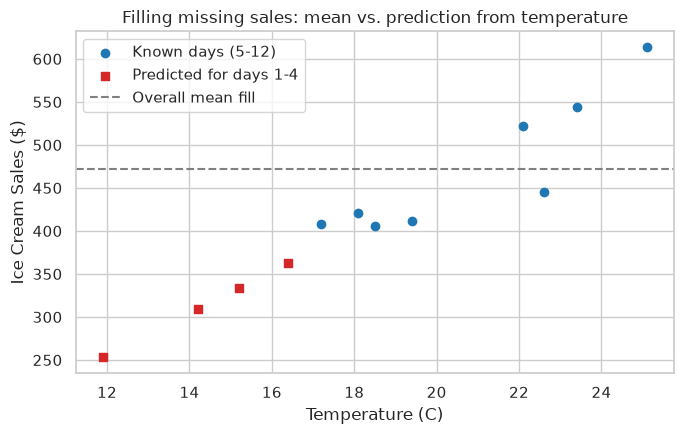

,Day,Temperature (C),Ice Cream Sales ($)
0,1,14.2,309.0
1,2,16.4,363.0
2,3,11.9,253.0
3,4,15.2,334.0
4,5,18.5,406.0
5,6,22.1,522.0
6,7,19.4,412.0
7,8,25.1,614.0
8,9,23.4,544.0
9,10,18.1,421.0


In [14]:
# Strategy 3 — PREDICT from another column: fit a straight line sales ~ temperature
known = icecream.dropna()
slope, intercept = np.polyfit(known["Temperature (C)"], known["Ice Cream Sales ($)"], deg=1)

predicted = icecream.copy()
missing = predicted["Ice Cream Sales ($)"].isna()
predicted.loc[missing, "Ice Cream Sales ($)"] = (
    slope * predicted.loc[missing, "Temperature (C)"] + intercept
).round()

# Show the three strategies side by side for the 4 repaired days
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(known["Temperature (C)"], known["Ice Cream Sales ($)"],
           label="Known days (5-12)", color="tab:blue")
ax.scatter(predicted.loc[missing, "Temperature (C)"],
           predicted.loc[missing, "Ice Cream Sales ($)"],
           label="Predicted for days 1-4", color="tab:red", marker="s")
ax.axhline(mean_sales, color="gray", ls="--", label="Overall mean fill")
ax.set_xlabel("Temperature (C)")
ax.set_ylabel("Ice Cream Sales ($)")
ax.set_title("Filling missing sales: mean vs. prediction from temperature")
ax.legend()
plt.tight_layout()
plt.show()

predicted

**How to read it:** the red squares (predicted values) sit *below* the gray
dashed line (the mean fill) — the prediction respects the fact that days 1–4 were
cold, so it fills in lower sales. This is exactly what the slide means by
*"predicting values using an algorithm."*

> ✏️ **Try it:** fill the missing sales with the **median** instead of the mean
> (`.median()`). Is the result very different here? When would the median be the
> safer choice? *(Hint: think about outliers.)*


### 4.1b Why the data is missing changes what you may do about it

Before choosing a strategy, ask **why** the value is absent. Statisticians name three cases, and they have
very different consequences:

| Mechanism | Meaning | Example | Is dropping or filling safe? |
|---|---|---|---|
| **MCAR** — missing completely at random | The gap has nothing to do with anything | A sensor lost power for an hour | Dropping is safe (you just lose data) |
| **MAR** — missing at random | The gap depends on *other observed* columns | Sales missing only on the coldest days | Fill it, using those other columns |
| **MNAR** — missing not at random | The gap depends on the *missing value itself* | People with very high incomes decline to state their income | Dangerous — any fill biases the result |

The ice-cream data is **MAR**: sales are missing exactly on days 1–4, which happen to be cold. That is
precisely why predicting from temperature (Strategy 3) beat filling with the mean.

**MNAR is the case to fear.** If high earners refuse to answer, then every value you fill in is too low, and
no amount of clever imputation fixes it — the information simply is not there. The honest response is to
report the missingness rather than paper over it.

In [15]:
# What each mechanism does to your answer. The truth is known here, so we can measure the damage.
rng_missing = np.random.default_rng(888102)

n = 2_000
income = rng_missing.gamma(shape=5.0, scale=8_000, size=n)     # the TRUE incomes
true_mean = income.mean()

# MCAR: 30% of values vanish for no reason at all.
mcar = income.copy()
mcar[rng_missing.random(n) < 0.30] = np.nan

# MNAR: people with high incomes decline to answer.
mnar = income.copy()
declines = rng_missing.random(n) < (income / income.max()) ** 0.5
mnar[declines] = np.nan

summary = pd.DataFrame({
    "Values kept": [n, np.isfinite(mcar).sum(), np.isfinite(mnar).sum()],
    "Mean of what remains": [true_mean, np.nanmean(mcar), np.nanmean(mnar)],
}, index=["TRUE (nothing missing)", "MCAR (random gaps)", "MNAR (high earners decline)"])
summary["Error vs. truth"] = summary["Mean of what remains"] - true_mean
summary["Error %"] = (summary["Error vs. truth"] / true_mean * 100).round(1)
summary.round(0)

,Values kept,Mean of what remains,Error vs. truth,Error %
TRUE (nothing missing),2000,39583.0,0.0,0.0
MCAR (random gaps),1401,39465.0,-118.0,-0.0
MNAR (high earners decline),938,35579.0,-4004.0,-10.0


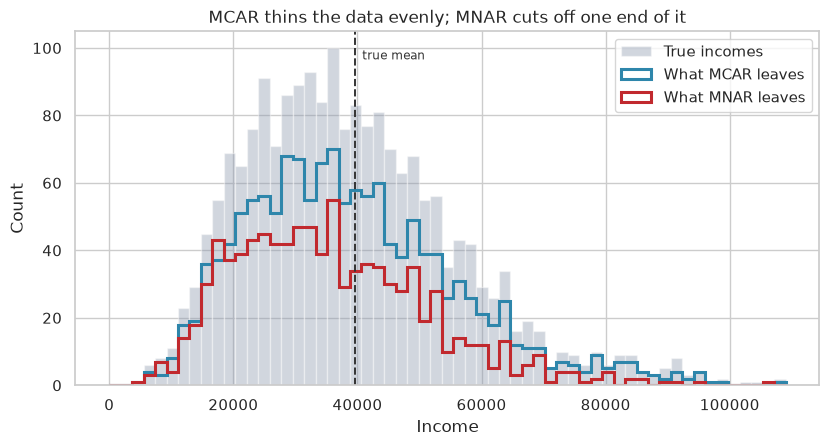

In [16]:
fig, ax = plt.subplots(figsize=(9.6, 4.6))
bins = np.linspace(0, np.percentile(income, 99.5), 60)
ax.hist(income, bins=bins, alpha=0.40, color="#8D99AE", label="True incomes")
ax.hist(mcar[np.isfinite(mcar)], bins=bins, histtype="step", linewidth=2.2,
        color="#2E86AB", label="What MCAR leaves")
ax.hist(mnar[np.isfinite(mnar)], bins=bins, histtype="step", linewidth=2.2,
        color="#C1292E", label="What MNAR leaves")
ax.axvline(true_mean, color="#333", linestyle="--", linewidth=1.4)
ax.text(true_mean * 1.03, ax.get_ylim()[1] * 0.92, "true mean", fontsize=8.5, color="#333")
ax.set_xlabel("Income")
ax.set_ylabel("Count")
ax.set_title("MCAR thins the data evenly; MNAR cuts off one end of it")
ax.legend()
plt.show()

**How to read it:** the MCAR curve has the same *shape* as the truth, just lower — random gaps thin the data
evenly, so the mean survives almost untouched. The MNAR curve is a different shape: the right tail has been
cut away, because that is exactly who declined to answer. Its mean lands about 10% below the truth — and,
crucially, it would stay about 10% below no matter how many more respondents you collected, because the bias
is in *who answers*, not in how many.

**No imputation method can repair MNAR**, because the pattern of what is missing carries the very information
you need. What you can do is *record* it: keep a flag saying the value was missing, and say so in your report.

In [17]:
# A missingness INDICATOR: keep the fact that a value was absent, even after filling it.
icecream_flagged = icecream.copy()
icecream_flagged["sales_was_missing"] = icecream_flagged["Ice Cream Sales ($)"].isna()
icecream_flagged["Ice Cream Sales ($)"] = icecream_flagged["Ice Cream Sales ($)"].fillna(
    icecream_flagged["Ice Cream Sales ($)"].mean().round())

print("The fill is now visible rather than hidden:")
icecream_flagged.head(6)

The fill is now visible rather than hidden:


,Day,Temperature (C),Ice Cream Sales ($),sales_was_missing
0,1,14.2,472.0,True
1,2,16.4,472.0,True
2,3,11.9,472.0,True
3,4,15.2,472.0,True
4,5,18.5,406.0,False
5,6,22.1,522.0,False


**How to read it:** after this, nobody downstream can mistake an imputed value for a measured one. The extra
column costs almost nothing and it is often *informative in its own right* — "this customer left the income
field blank" can be a genuinely predictive feature.

⚠️ **A trap for later chapters.** If you fill missing values using the mean of the *whole* dataset and then
split into training and test sets, the test set's values have leaked into the training data. Always split
first, compute the fill from the training set only, and apply it to both. Section 6.3 comes back to this.

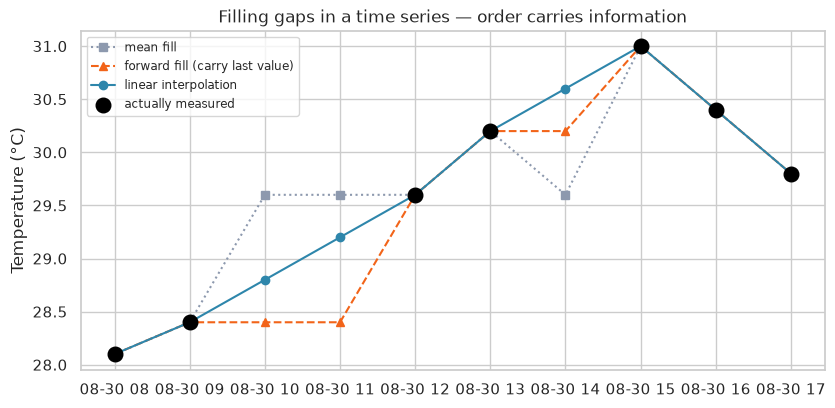

/tmp/ipykernel_1867996/732646522.py:25: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  sensor.round(2)


,time,temp_c,forward fill,interpolated,mean fill
0,2026-08-30 08:00:00,28.1,28.1,28.1,28.1
1,2026-08-30 09:00:00,28.4,28.4,28.4,28.4
2,2026-08-30 10:00:00,NaN,28.4,28.8,29.6
3,2026-08-30 11:00:00,NaN,28.4,29.2,29.6
4,2026-08-30 12:00:00,29.6,29.6,29.6,29.6
5,2026-08-30 13:00:00,30.2,30.2,30.2,30.2
6,2026-08-30 14:00:00,NaN,30.2,30.6,29.6
7,2026-08-30 15:00:00,31.0,31.0,31.0,31.0
8,2026-08-30 16:00:00,30.4,30.4,30.4,30.4
9,2026-08-30 17:00:00,29.8,29.8,29.8,29.8


In [18]:
# For data in time order, "the value before" is usually a better fill than the overall mean.
sensor = pd.DataFrame({
    "time": pd.date_range("2026-08-30 08:00", periods=10, freq="h"),
    "temp_c": [28.1, 28.4, np.nan, np.nan, 29.6, 30.2, np.nan, 31.0, 30.4, 29.8],
})
sensor["forward fill"] = sensor["temp_c"].ffill()
sensor["interpolated"] = sensor["temp_c"].interpolate()
sensor["mean fill"] = sensor["temp_c"].fillna(sensor["temp_c"].mean().round(1))

fig, ax = plt.subplots(figsize=(9.6, 4.4))
ax.plot(sensor["time"], sensor["mean fill"], marker="s", linestyle=":",
        color="#8D99AE", label="mean fill")
ax.plot(sensor["time"], sensor["forward fill"], marker="^", linestyle="--",
        color="#F26419", label="forward fill (carry last value)")
ax.plot(sensor["time"], sensor["interpolated"], marker="o",
        color="#2E86AB", label="linear interpolation")
ax.scatter(sensor.loc[sensor["temp_c"].notna(), "time"],
           sensor.loc[sensor["temp_c"].notna(), "temp_c"],
           s=110, color="black", zorder=5, label="actually measured")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Filling gaps in a time series — order carries information")
ax.legend(fontsize=8.5)
plt.show()

sensor.round(2)

**How to read it:** the mean fill drags the two missing morning readings up to the daily average, inventing a
temperature spike that never happened. Forward fill holds the last known value — sensible for something that
changes slowly. Linear interpolation draws a straight line between the known neighbors and is usually the
best choice for a smooth physical quantity.

The general principle: **use whatever structure the data has.** Time series have order; the ice-cream data had
a related column. A fill that ignores available structure is throwing information away.

### 4.2 Inconsistent formatting

*Data is not presented in the same format or value — non-standard formats that
cannot be processed by the system.*

Let's repair the lecture's orders table from section 3.7: three different date
styles, and one amount written as English words.


In [19]:
# The broken table again
orders = pd.DataFrame({
    "Customer": ["Don", "Joe", "Tim"],
    "Order Dt": ["2019/2/12", "12/24/2019", "2019/2/12 22:09:01"],
    "Order Amt": ["$100", "Five Hundred Dollars", "$300"],
})

# Fix the dates: format="mixed" lets pandas figure out each row's style separately
orders["Order Dt (fixed)"] = pd.to_datetime(orders["Order Dt"], format="mixed")

orders

,Customer,Order Dt,Order Amt,Order Dt (fixed)
0,Don,2019/2/12,$100,2019-02-12 00:00:00
1,Joe,12/24/2019,Five Hundred Dollars,2019-12-24 00:00:00
2,Tim,2019/2/12 22:09:01,$300,2019-02-12 22:09:01


In [20]:
# Fix the amounts, step by step:
# 1) translate the words into digits (a small lookup table)
words_to_number = {"Five Hundred Dollars": "$500"}
amt = orders["Order Amt"].replace(words_to_number)

# 2) remove the "$" sign, then convert the text to real numbers
orders["Order Amt (fixed)"] = pd.to_numeric(amt.str.replace("$", "", regex=False))

orders[["Customer", "Order Dt (fixed)", "Order Amt (fixed)"]]

,Customer,Order Dt (fixed),Order Amt (fixed)
0,Don,2019-02-12 00:00:00,100
1,Joe,2019-12-24 00:00:00,500
2,Tim,2019-02-12 22:09:01,300


**How to read it:** after cleaning, every date is a real `datetime` and every
amount is a real number — now we can sort by date, compute totals, and plot. The
general recipe for formatting problems is always the same:

1. **Look** at the raw values (`df["col"].unique()` is your friend).
2. **Standardize** the text with `str.replace()` / `.str.strip()` / lookup tables.
3. **Convert** to the proper type with `pd.to_datetime()` or `pd.to_numeric()`.


### 4.2b The messiest column in any real dataset: free-text categories

Dates and currency symbols are the tidy end of formatting problems. The genuinely painful case is a category
column that humans typed by hand, where the same category arrives spelled a dozen ways.

In [21]:
# One province, typed by many different people over several years.
raw = pd.Series([
    "Chiang Mai", "chiang mai", "CHIANG MAI", " Chiang Mai ", "Chiangmai",
    "Chiang  Mai", "chiang-mai", "CM", "Chiang Mai\n", "Chiang Rai", "chiang rai",
])

print(f"Distinct values as typed: {raw.nunique()}")
print(sorted(raw.unique()))
print("\nA naive value_counts() would report eleven 'different' provinces:")
print(raw.value_counts().to_string())

Distinct values as typed: 11
[' Chiang Mai ', 'CHIANG MAI', 'CM', 'Chiang  Mai', 'Chiang Mai', 'Chiang Mai\n', 'Chiang Rai', 'Chiangmai', 'chiang mai', 'chiang rai', 'chiang-mai']

A naive value_counts() would report eleven 'different' provinces:
Chiang Mai      1
chiang mai      1
CHIANG MAI      1
 Chiang Mai     1
Chiangmai       1
Chiang  Mai     1
chiang-mai      1
CM              1
Chiang Mai\n    1
Chiang Rai      1
chiang rai      1


In [22]:
# Clean it in stages, checking after each one.
step1 = raw.str.strip()                                   # remove leading/trailing whitespace
step2 = step1.str.replace(r"\s+", " ", regex=True)        # collapse runs of spaces and newlines
step3 = step2.str.replace("-", " ", regex=False)          # normalize separators
step4 = step3.str.lower()                                 # case-fold so CHIANG == chiang

aliases = {"cm": "chiang mai", "chiangmai": "chiang mai", "cr": "chiang rai"}
step5 = step4.replace(aliases)                            # map known abbreviations
final = step5.str.title()                                 # one canonical presentation

stages = pd.DataFrame({
    "0. as typed": raw, "1. strip": step1, "2. collapse spaces": step2,
    "3. separators": step3, "4. lowercase": step4, "5. aliases": step5, "6. final": final,
})
print("Distinct values remaining after each stage:")
print(stages.nunique().to_string())
print()
stages[["0. as typed", "6. final"]]

Distinct values remaining after each stage:
0. as typed           11
1. strip               9
2. collapse spaces     8
3. separators          7
4. lowercase           4
5. aliases             2
6. final               2



,0. as typed,6. final
0,Chiang Mai,Chiang Mai
1,chiang mai,Chiang Mai
2,CHIANG MAI,Chiang Mai
3,Chiang Mai,Chiang Mai
4,Chiangmai,Chiang Mai
5,Chiang Mai,Chiang Mai
6,chiang-mai,Chiang Mai
7,CM,Chiang Mai
8,Chiang Mai\n,Chiang Mai
9,Chiang Rai,Chiang Rai


In [23]:
print("Now the counts mean something:")
print(final.value_counts().to_string())

# The reusable version.
def clean_category(series, aliases=None):
    cleaned = (series.astype(str)
               .str.strip()
               .str.replace(r"\s+", " ", regex=True)
               .str.replace("-", " ", regex=False)
               .str.lower())
    if aliases:
        cleaned = cleaned.replace(aliases)
    return cleaned.str.title()

print("\nSame result from the reusable function:",
      clean_category(raw, aliases).equals(final))

Now the counts mean something:
Chiang Mai    9
Chiang Rai    2

Same result from the reusable function: True


**How to read it:** eleven "distinct" values collapse to two real provinces. Note the order of the stages —
**case-folding must come after** the whitespace fixes, and the alias table must come after case-folding, or
`"CM"` would not match the lowercase key `"cm"`.

⚠️ **The alias table is the dangerous part**, because it encodes judgment. Deciding that `"CM"` means Chiang
Mai is a guess about what a data-entry clerk meant, and it might be wrong. Write the table down explicitly,
as here, rather than burying such decisions in a chain of `.replace()` calls — someone will need to audit it.

> ✏️ **Try it:** add `"เชียงใหม่"` (the Thai spelling) to the raw list. Does the pipeline handle it? What
> would you have to add, and what does that tell you about cleaning bilingual data?

### 4.3 Duplicates

*Data duplication occurs when data appears in the dataset more than one time —
entered multiple times but sometimes displayed in different ways.*

The lecture's example is a patients database where the **doctor information**
(Doctor Id, Doctor, Room) is repeated on every row of that doctor's patients.


In [24]:
# The patients table from the lecture
patients = pd.DataFrame({
    "Patient Id": [134, 178, 198, 210, 258],
    "Name": ["Jeff", "David", "Lisa", "Frank", "Rachel"],
    "D.o.B": ["4-Jul-1993", "8-Feb-1987", "18-Dec-1979", "29-Apr-1983", "8-Feb-1987"],
    "Gender": ["Male", "Male", "Female", "Male", "Female"],
    "Phone": [7876453, 8635467, 7498735, 7943521, 8367242],
    "Doctor Id": ["01", "02", "01", "01", "02"],
    "Doctor": ["Dr Hyde", "Dr Jekyll", "Dr Hyde", "Dr Hyde", "Dr Jekyll"],
    "Room": ["03", "06", "03", "03", "06"],
})
patients

,Patient Id,Name,D.o.B,Gender,Phone,Doctor Id,Doctor,Room
0,134,Jeff,4-Jul-1993,Male,7876453,01,Dr Hyde,03
1,178,David,8-Feb-1987,Male,8635467,02,Dr Jekyll,06
2,198,Lisa,18-Dec-1979,Female,7498735,01,Dr Hyde,03
3,210,Frank,29-Apr-1983,Male,7943521,01,Dr Hyde,03
4,258,Rachel,8-Feb-1987,Female,8367242,02,Dr Jekyll,06


In [25]:
# No row is duplicated as a whole...
print("Fully duplicated rows:", patients.duplicated().sum())

# ...but the doctor columns repeat the same facts again and again:
print("Duplicated doctor entries:",
      patients.duplicated(subset=["Doctor Id", "Doctor", "Room"]).sum())

# The fix: keep the doctor facts ONCE in their own small table
doctors = patients[["Doctor Id", "Doctor", "Room"]].drop_duplicates().reset_index(drop=True)
doctors

Fully duplicated rows: 0
Duplicated doctor entries: 3


,Doctor Id,Doctor,Room
0,01,Dr Hyde,03
1,02,Dr Jekyll,06


In [26]:
# ...and keep only the doctor's ID in the patients table.
patients_clean = patients.drop(columns=["Doctor", "Room"])
patients_clean

,Patient Id,Name,D.o.B,Gender,Phone,Doctor Id
0,134,Jeff,4-Jul-1993,Male,7876453,01
1,178,David,8-Feb-1987,Male,8635467,02
2,198,Lisa,18-Dec-1979,Female,7498735,01
3,210,Frank,29-Apr-1983,Male,7943521,01
4,258,Rachel,8-Feb-1987,Female,8367242,02


**How to read it:** "Dr Hyde / Room 03" was stored three times — if Dr Hyde moves
to Room 05, you must remember to update three rows, and forgetting one creates an
*inconsistency* (section 3.3!). Splitting the data into two linked tables stores
each fact **once**. When you need the full picture back, `merge` joins them:
`patients_clean.merge(doctors, on="Doctor Id")`.

> ✏️ **Try it:** run `patients_clean.merge(doctors, on="Doctor Id")` in a new cell
> and check that you get the original table back.


### 4.4 Inconsistent datatypes

Even when values *look* right, they may be stored as the wrong **type** — numbers
kept as text are the classic case. Text numbers cannot be summed, averaged, or
plotted, and sorting them gives surprising results.


In [27]:
# Scores accidentally stored as text (note the quotes!)
scores = pd.DataFrame({"student": ["May", "Beam", "Fah", "Nok"],
                       "score": ["95", "84", "100", "9"]})
print(scores.dtypes)          # score is "object" = text, not a number!
print()
print("Sorted as TEXT (wrong!):")
print(scores.sort_values("score")["score"].tolist())   # "100" < "84" < "9" < "95" ?!

# The fix: convert the column to a numeric type
scores["score"] = scores["score"].astype(int)
print()
print("Sorted as NUMBERS (correct):")
print(scores.sort_values("score")["score"].tolist())

student    str
score      str
dtype: object

Sorted as TEXT (wrong!):
['100', '84', '9', '95']

Sorted as NUMBERS (correct):
[9, 84, 95, 100]


**How to read it:** as text, `"100"` sorts *before* `"84"` because text is
compared character by character (`"1" < "8"`). One `astype(int)` fixes it. Always
check `df.dtypes` right after loading any dataset — a numeric column showing
`object` is a red flag. When a column contains some values that *cannot* be
converted, use `pd.to_numeric(col, errors="coerce")` — the bad values become
`NaN` and you can then handle them like any missing data (section 4.1).


---
## 4.5 Outliers — identify, explain, then decide

The lecture's list of data preparation tasks includes *"identifying severe outliers and explaining the
inconsistencies, or deleting them."* Note the order carefully: **identify → explain → decide.** Deleting a
point because it is inconvenient is not data cleaning, it is data fabrication.

Three standard detection methods:

| Method | Rule | Assumes | Good for |
|---|---|---|---|
| **Z-score** | \|z\| > 3, where z = (x − mean) / s.d. | Roughly bell-shaped data | Symmetric distributions |
| **IQR (Tukey)** | Outside Q1 − 1.5×IQR or Q3 + 1.5×IQR | Nothing about shape | Skewed data — the safer default |
| **Domain rule** | Violates a known fact (age > 120) | You know the domain | Impossible values |

In [28]:
# Daily sales for a café, with three unusual days deliberately included.
sales = pd.Series([
    4_200, 4_450, 3_980, 4_310, 4_505, 4_120, 4_390, 4_260, 4_480, 4_050,
    4_330, 4_180, 4_410, 4_270, 4_520,
    12_800,     # a festival day — REAL, and the most interesting day of the month
    41,         # a half-day closure — real but not comparable
    -4_300,     # a refund batch entered with the wrong sign — an ERROR
])

mean, std = sales.mean(), sales.std()
z_scores = (sales - mean) / std

q1, q3 = sales.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

audit = pd.DataFrame({
    "sales": sales,
    "z-score": z_scores.round(2),
    "z flags?": z_scores.abs() > 3,
    "IQR flags?": (sales < lower) | (sales > upper),
})
print(f"mean = {mean:,.0f}   s.d. = {std:,.0f}")
print(f"Q1 = {q1:,.0f}   Q3 = {q3:,.0f}   IQR fences: [{lower:,.0f}, {upper:,.0f}]\n")
audit[audit["z flags?"] | audit["IQR flags?"]]

mean = 4,055   s.d. = 3,103
Q1 = 4,135   Q3 = 4,440   IQR fences: [3,678, 4,898]



,sales,z-score,z flags?,IQR flags?
15,12800,2.82,False,True
16,41,-1.29,False,True
17,-4300,-2.69,False,True


**How to read it:** the IQR rule flags all three unusual days. The z-score rule flags **none of them** — not
even the impossible negative value.

That is not a fluke, and it is the most important practical fact about z-scores: **the outliers themselves
inflate the mean and the standard deviation.** Here the three odd days push the standard deviation up to about
3,100 baht even though ordinary days vary by only a couple of hundred, so the ±3 s.d. boundary stretches out
past ±9,000 and swallows the very points it was meant to catch. This is called *masking*.

The IQR method uses quartiles, which barely move when a few extreme values are added, so it does not suffer
from the same problem. **When in doubt, use the IQR rule.**

/tmp/ipykernel_1867996/3628085097.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax_box.boxplot(sales, vert=True, widths=0.5)


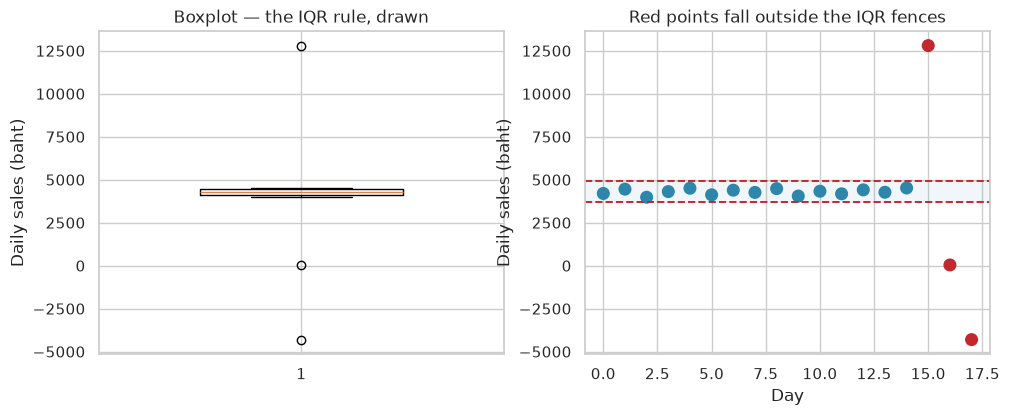

In [29]:
fig, (ax_box, ax_strip) = plt.subplots(1, 2, figsize=(11.5, 4.2))

ax_box.boxplot(sales, vert=True, widths=0.5)
ax_box.set_ylabel("Daily sales (baht)")
ax_box.set_title("Boxplot — the IQR rule, drawn")

ax_strip.scatter(range(len(sales)), sales, s=70,
                 color=["#C1292E" if flag else "#2E86AB" for flag in audit["IQR flags?"]])
ax_strip.axhline(upper, color="#C1292E", linestyle="--", linewidth=1.4)
ax_strip.axhline(lower, color="#C1292E", linestyle="--", linewidth=1.4)
ax_strip.axhspan(lower, upper, color="#2E86AB", alpha=0.07)
ax_strip.set_xlabel("Day")
ax_strip.set_ylabel("Daily sales (baht)")
ax_strip.set_title("Red points fall outside the IQR fences")

plt.show()

**How to read it:** a boxplot *is* the IQR rule made visible — the whiskers stop at the fences and anything
beyond is drawn as an individual point. This is why boxplots are the standard first look at a numeric column,
and Part II returns to them properly.

### Now the hard part: what to do about each one

The three flagged days are flagged for three completely different reasons, and they deserve three different
responses:

| Day | Value | What it is | What to do |
|---|---|---|---|
| Festival | 12,800 | **Real and important** | **Keep it.** Deleting it would erase the best day of the month |
| Half-day closure | 41 | **Real but not comparable** | Exclude it *with a stated reason*, or add an "open hours" column |
| Refund batch | −4,300 | **An error** — sales cannot be negative | Fix the sign if you can verify it; otherwise mark it missing |

**A statistical test can tell you a point is unusual. Only domain knowledge can tell you why.** That is what
the lecture means by "explaining the inconsistencies."

In [30]:
# Three responses, three different answers. The choice is not neutral.
impossible = sales < 0                                   # a hard domain rule
verified_error_fixed = sales.where(~impossible, sales.abs())

options = pd.DataFrame({
    "Rows kept": [
        len(sales),
        (~audit["IQR flags?"]).sum(),
        len(sales),
        (~impossible).sum(),
    ],
    "Mean daily sales": [
        sales.mean(),
        sales[~audit["IQR flags?"]].mean(),
        sales.clip(lower=lower, upper=upper).mean(),
        sales[~impossible].mean(),
    ],
}, index=[
    "Do nothing",
    "Delete everything flagged",
    "Winsorize (clip to the fences)",
    "Fix the error, keep the real days",
])
options["Median (for comparison)"] = [
    sales.median(), sales[~audit["IQR flags?"]].median(),
    sales.clip(lower=lower, upper=upper).median(), sales[~impossible].median(),
]
options.round(0)

,Rows kept,Mean daily sales,Median (for comparison)
Do nothing,18,4055.0,4290.0
Delete everything flagged,15,4297.0,4310.0
Winsorize (clip to the fences),18,4262.0,4290.0
"Fix the error, keep the real days",17,4547.0,4310.0


**How to read it:** four defensible treatments, four different means — the spread between them is larger than
most effects you would ever try to detect. Notice how little the **median** moves across all four rows. That
is the practical argument for robust statistics: if your conclusion depends on how you treated three points,
it was never a strong conclusion.

**Whatever you choose, write it down.** "We excluded one half-day closure and corrected one sign error;
festival days were retained" is a sentence that belongs in the report, not a decision buried in a notebook.

> ✏️ **Try it:** compute the mean and median with the festival day removed as well. Which statistic changes
> more, and what does that tell you about which one to report for skewed data like daily sales?

---
## 4.6 Merging several sources into one dataset

The very first task on the lecture's list is *"combining several data sources into one dataset for
analysis."* It is also where the largest and quietest errors happen, because a bad merge produces a table that
looks completely normal.

Two operations, often confused:

- **Concatenate** (`pd.concat`) — stack tables that have the *same columns*, adding rows.
- **Merge / join** (`pd.merge`) — combine tables that share a *key column*, adding columns.

In [31]:
# CONCATENATE: three branches each send the same monthly report.
nimman = pd.DataFrame({"date": ["2026-08-01", "2026-08-02"], "sales": [4_200, 4_450]})
suthep = pd.DataFrame({"date": ["2026-08-01", "2026-08-02"], "sales": [2_100, 2_260]})
airport = pd.DataFrame({"Date": ["2026-08-01", "2026-08-02"], "Sales": [5_050, 4_890]})  # different case!

combined = pd.concat([nimman.assign(branch="Nimman"),
                      suthep.assign(branch="Suthep"),
                      airport.assign(branch="Airport")], ignore_index=True)
print("Concatenating without checking the column names first:")
print(combined.to_string(index=False))
print("\nThe Airport branch's data landed in NEW columns, and its rows are empty in the old ones.")

Concatenating without checking the column names first:
      date  sales  branch       Date  Sales
2026-08-01 4200.0  Nimman        NaN    NaN
2026-08-02 4450.0  Nimman        NaN    NaN
2026-08-01 2100.0  Suthep        NaN    NaN
2026-08-02 2260.0  Suthep        NaN    NaN
       NaN    NaN Airport 2026-08-01 5050.0
       NaN    NaN Airport 2026-08-02 4890.0

The Airport branch's data landed in NEW columns, and its rows are empty in the old ones.


In [32]:
# The fix: standardize column names BEFORE combining, and always tag the source.
def standardize(frame, branch):
    frame = frame.copy()
    frame.columns = [column.strip().lower() for column in frame.columns]
    frame["branch"] = branch
    return frame

combined = pd.concat([standardize(nimman, "Nimman"),
                      standardize(suthep, "Suthep"),
                      standardize(airport, "Airport")], ignore_index=True)
print(combined.to_string(index=False))
print(f"\nRows: {len(combined)}  (expected 2 + 2 + 2 = 6)")
print(f"Missing values: {combined.isna().sum().sum()}")

      date  sales  branch
2026-08-01   4200  Nimman
2026-08-02   4450  Nimman
2026-08-01   2100  Suthep
2026-08-02   2260  Suthep
2026-08-01   5050 Airport
2026-08-02   4890 Airport

Rows: 6  (expected 2 + 2 + 2 = 6)
Missing values: 0


**How to read it:** `pd.concat` aligns on column *names*, and `"Sales"` is not `"sales"`. Nothing raised an
error — pandas dutifully created new columns and filled the rest with `NaN`. The result would sum to the wrong
total and look perfectly plausible while doing so.

**Standardize column names before you combine anything**, and add a column recording which source each row
came from. That single extra column pays for itself the first time a number looks wrong.

In [33]:
# MERGE: the classic failure is a key that is not unique on one side.
customers = pd.DataFrame({
    "customer_id": [1, 2, 3],
    "name": ["Nam", "Bo", "Ploy"],
})
orders = pd.DataFrame({
    "order_id": [101, 102, 103, 104, 105],
    "customer_id": [1, 1, 2, 2, 2],
    "amount": [250, 180, 300, 120, 90],
})

merged = customers.merge(orders, on="customer_id", how="left")
print(f"customers: {len(customers)} rows")
print(f"orders   : {len(orders)} rows")
print(f"merged   : {len(merged)} rows   <- not 3, and not 5\n")
print(merged.to_string(index=False))

customers: 3 rows
orders   : 5 rows
merged   : 6 rows   <- not 3, and not 5

 customer_id name  order_id  amount
           1  Nam     101.0   250.0
           1  Nam     102.0   180.0
           2   Bo     103.0   300.0
           2   Bo     104.0   120.0
           2   Bo     105.0    90.0
           3 Ploy       NaN     NaN


In [34]:
# Why the row count matters: it silently changes what an average means.
print("Average customer 'name' count is fine, but watch what happens to a per-customer figure.\n")

wrong = merged["amount"].mean()
right = merged.groupby("customer_id")["amount"].sum().mean()

print(f"Mean of the merged 'amount' column   : {wrong:,.1f}  <- mean per ORDER")
print(f"Mean total spend per customer        : {right:,.1f}  <- mean per CUSTOMER")
print("\nBoth are legitimate numbers. Only one answers 'what does a customer spend?',")
print("and after a one-to-many merge it is very easy to report the other by accident.")

# The habit that catches this class of bug.
def merge_checked(left, right, **kwargs):
    result = left.merge(right, **kwargs)
    print(f"  merge: {len(left)} x {len(right)} -> {len(result)} rows", end="")
    if len(result) > max(len(left), len(right)):
        print("   [!] rows MULTIPLIED — the key is not unique on one side")
    elif len(result) < len(left):
        print("   [!] rows LOST — unmatched keys were dropped")
    else:
        print("   ok")
    return result

print("\nUsing a checked merge instead:")
_ = merge_checked(customers, orders, on="customer_id", how="left")
_ = merge_checked(customers, orders.query("customer_id != 2"), on="customer_id", how="inner")

Average customer 'name' count is fine, but watch what happens to a per-customer figure.

Mean of the merged 'amount' column   : 188.0  <- mean per ORDER
Mean total spend per customer        : 313.3  <- mean per CUSTOMER

Both are legitimate numbers. Only one answers 'what does a customer spend?',
and after a one-to-many merge it is very easy to report the other by accident.

Using a checked merge instead:
  merge: 3 x 5 -> 6 rows   [!] rows MULTIPLIED — the key is not unique on one side
  merge: 3 x 2 -> 2 rows   [!] rows LOST — unmatched keys were dropped


**How to read it:** merging 3 customers with 5 orders gave 5 rows, because each customer matched several
orders. Every customer's name is now repeated once per order — so averaging any *customer-level* column over
the merged table silently weights each customer by how much they ordered.

pandas also offers a built-in guard: `validate="one_to_one"`, `"one_to_many"`, or `"many_to_one"` will raise
an error if the relationship is not what you claimed. **State what you expect and let the library check it**
— that is far better than discovering the problem three charts later.

> ✏️ **Try it:** re-run the merge with `validate="one_to_one"`. Read the error message carefully — it names
> exactly which side of the merge broke your assumption.

## 5. Encoding categorical data

Most machine learning algorithms **cannot handle categorical variables** — they
need numbers. So categorical variables are *converted* to numerical values. The
right conversion depends on the kind of category (remember Chapter 2!):

| Variable kind | Encoding | Idea |
|---|---|---|
| **Nominal** (no order — colors, cities) | **One-hot encoding** | one 0/1 column per category |
| **Ordinal** (has an order — Poor < Good < ...) | **Ordinal encoding** | one number per category, respecting the order |


In [35]:
# One-hot encoding — the color example from the lecture
colors = pd.DataFrame({"Color": ["Red", "Red", "Yellow", "Green", "Yellow"]})

# pd.get_dummies creates one column per category: 1 = presence, 0 = absence
one_hot = pd.get_dummies(colors["Color"]).astype(int)
one_hot = one_hot[["Red", "Yellow", "Green"]]      # same column order as the slide

pd.concat([colors, one_hot], axis=1)

,Color,Red,Yellow,Green
0,Red,1,0,0
1,Red,1,0,0
2,Yellow,0,1,0
3,Green,0,0,1
4,Yellow,0,1,0


**How to read it:** each row has exactly one `1` — the column of its color. No
category is "bigger" than another, which is exactly right for nominal data.

Why not just use Red = 1, Yellow = 2, Green = 3? Because the algorithm would then
believe Green (3) is "three times" Red (1) and that Yellow sits "between" them —
an order that **does not exist**. One-hot encoding avoids inventing a fake order.


In [36]:
# Ordinal encoding — the rating example from the lecture
ratings = pd.DataFrame({"rating": ["Poor", "Good", "Very Good", "Excellent",
                                   "Good", "Excellent"]})

# The order is real here, so we assign increasing numbers, exactly as on the slide
order = {"Poor": 1, "Good": 2, "Very Good": 3, "Excellent": 4}
ratings["rating_encoded"] = ratings["rating"].map(order)
ratings

,rating,rating_encoded
0,Poor,1
1,Good,2
2,Very Good,3
3,Excellent,4
4,Good,2
5,Excellent,4


**How to read it:** the encoding **retains the ordinal nature** of the variable:
Excellent (4) > Very Good (3) > Good (2) > Poor (1). A `.map()` with a dictionary
you write yourself is the simplest way to control the order.

> ✏️ **Try it:** one-hot encode the `weekday` idea: make a small DataFrame with
> values `["Mon", "Sat", "Sun", "Mon"]` and run `pd.get_dummies` on it. How many
> new columns do you get?


### 5.1 Two things that go wrong with one-hot encoding

**The dummy variable trap.** If you know a row is not Red and not Yellow, then it *must* be Green — the last
column carries no new information, and the columns are perfectly predictable from each other. Some models
(notably linear regression) break on this. Dropping one column fixes it.

In [37]:
colors = pd.DataFrame({"Color": ["Red", "Red", "Yellow", "Green", "Yellow"]})

full = pd.get_dummies(colors["Color"]).astype(int)[["Red", "Yellow", "Green"]]
dropped = pd.get_dummies(colors["Color"], drop_first=True).astype(int)

print("All three columns — every row sums to exactly 1, so any one column is redundant:")
print(pd.concat([colors, full, full.sum(axis=1).rename("row sum")], axis=1).to_string(index=False))

print("\nWith drop_first=True — the dropped category becomes the 'reference' (all zeros):")
print(pd.concat([colors, dropped], axis=1).to_string(index=False))

All three columns — every row sums to exactly 1, so any one column is redundant:
 Color  Red  Yellow  Green  row sum
   Red    1       0      0        1
   Red    1       0      0        1
Yellow    0       1      0        1
 Green    0       0      1        1
Yellow    0       1      0        1

With drop_first=True — the dropped category becomes the 'reference' (all zeros):
 Color  Red  Yellow
   Red    1       0
   Red    1       0
Yellow    0       1
 Green    0       0
Yellow    0       1


**How to read it:** with all three columns present, every row sums to 1, so the third column is exactly
`1 - Red - Yellow`. With `drop_first=True` the missing category is represented by *all zeros* and is called
the **reference category** — coefficients in a model are then interpreted as differences relative to it.

**When to drop:** for linear and logistic regression, drop one. For tree-based models (Chapter 10) it makes no
difference, and keeping all columns is often easier to read.

**The second problem: high cardinality.** One-hot encoding a column with many distinct values explodes the
table.

In [38]:
rng_card = np.random.default_rng(3)

for name, n_categories in [("province", 77), ("postcode", 5_000), ("product_sku", 120_000)]:
    print(f"{name:12s}: {n_categories:>7,} categories -> {n_categories:>7,} new columns after one-hot")

n_rows = 100_000
print(f"\nOn {n_rows:,} rows, one-hot encoding product_sku would create a "
      f"{n_rows:,} x {120_000:,} table.")
print(f"As dense 8-byte floats that is {n_rows * 120_000 * 8 / 1e12:.1f} TB — from ONE column.")

print("\nPractical alternatives:")
print("  * Group rare categories into 'Other' — often the top 20 plus 'Other' captures most rows.")
print("  * Use a sparse representation, which stores only the non-zero entries.")
print("  * Use a model that handles categories natively (many tree implementations do).")

province    :      77 categories ->      77 new columns after one-hot
postcode    :   5,000 categories ->   5,000 new columns after one-hot
product_sku : 120,000 categories -> 120,000 new columns after one-hot

On 100,000 rows, one-hot encoding product_sku would create a 100,000 x 120,000 table.
As dense 8-byte floats that is 0.1 TB — from ONE column.

Practical alternatives:
  * Group rare categories into 'Other' — often the top 20 plus 'Other' captures most rows.
  * Use a sparse representation, which stores only the non-zero entries.
  * Use a model that handles categories natively (many tree implementations do).


Original distinct categories : 200
After keeping the top 10   : 11
Rows still individually named: 59.5%

Columns after one-hot: 200 -> 11


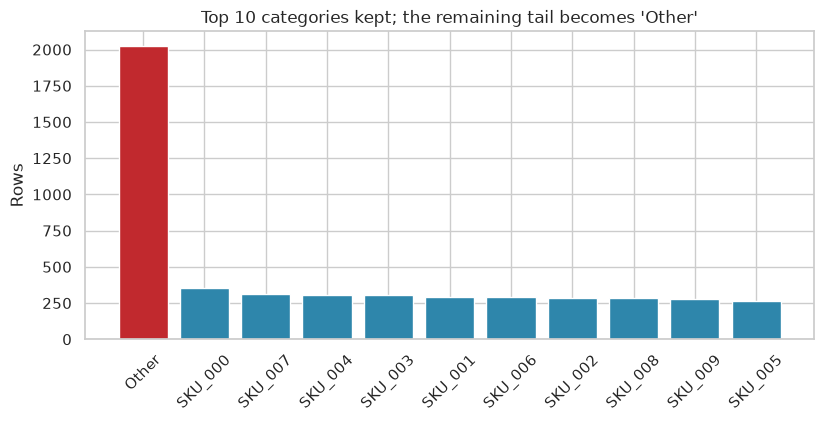

In [39]:
# Grouping rare categories: keep the ones that matter, bucket the long tail.
categories = rng_card.choice([f"SKU_{i:03d}" for i in range(200)], size=5_000,
                             p=np.r_[np.full(10, 0.06), np.full(190, 0.4 / 190)])
counts = pd.Series(categories).value_counts()

top_n = 10
keep = counts.head(top_n).index
grouped = pd.Series(categories).where(pd.Series(categories).isin(keep), "Other")

print(f"Original distinct categories : {counts.nunique() if False else counts.size}")
print(f"After keeping the top {top_n}   : {grouped.nunique()}")
print(f"Rows still individually named: {(grouped != 'Other').mean():.1%}")
print(f"\nColumns after one-hot: {counts.size} -> {grouped.nunique()}")

fig, ax = plt.subplots(figsize=(9.4, 4))
top_counts = grouped.value_counts()
ax.bar(top_counts.index, top_counts.values,
       color=["#C1292E" if name == "Other" else "#2E86AB" for name in top_counts.index])
ax.set_ylabel("Rows")
ax.set_title(f"Top {top_n} categories kept; the remaining tail becomes 'Other'")
ax.tick_params(axis="x", rotation=45)
plt.show()

**How to read it:** ten categories cover most of the rows, and the other 190 collapse into a single "Other"
bucket. Two hundred columns become eleven, and very little is lost — because a category appearing in a handful
of rows could never have supported a reliable estimate anyway.

⚠️ **Choose the cut on the training data only.** If you pick the top 10 using the whole dataset, information
about the test set has leaked into your preprocessing. This is the same warning as Section 4.1b, and it is
about to appear a third time.

## 6. Normalization and standardization

Different features live on very different scales (age: 0–100, salary:
0–1,000,000). Standardization and normalization **put all features on the same
scale**, which many algorithms need to work well.

| Method | Formula | Result |
|---|---|---|
| **Normalization** (min-max) | $x_{norm} = \dfrac{x - x_{min}}{x_{max} - x_{min}}$ | every value falls between **0 and 1** |
| **Standardization** (z-score) | $x_{std} = \dfrac{x - \bar{x}}{S.D.}$ | mean becomes **0**, standard deviation **1** |

The lecture demonstrates both on the `tip` column of the classic **tips** dataset
(restaurant bills and tips) — let's reproduce its three histograms.


In [40]:
# Load the tips dataset (needs internet the first time, like the Titanic data)
tips = sns.load_dataset("tips")
tip = tips["tip"]
print(tip.describe().round(2))

count    244.00
mean       3.00
std        1.38
min        1.00
25%        2.00
50%        2.90
75%        3.56
max       10.00
Name: tip, dtype: float64


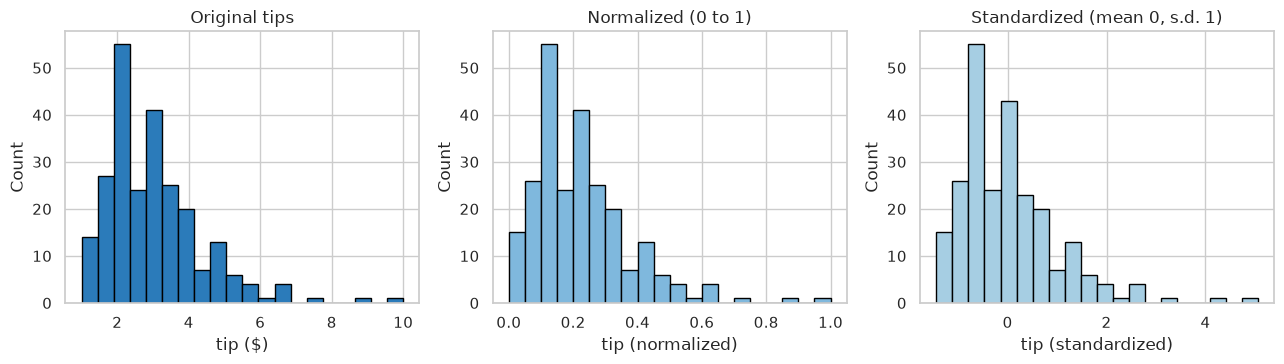

Normalized   -> min: 0.0  max: 1.0
Standardized -> mean: 0.0  s.d.: 1.0


In [41]:
# Apply the two formulas — plain arithmetic on the whole column at once
tip_normalized   = (tip - tip.min()) / (tip.max() - tip.min())
tip_standardized = (tip - tip.mean()) / tip.std()

# The three histograms side by side, like the lecture slide
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].hist(tip, bins=20, color="#2b7bba", edgecolor="black")
axes[0].set_title("Original tips")
axes[0].set_xlabel("tip ($)")
axes[1].hist(tip_normalized, bins=20, color="#7fb8dd", edgecolor="black")
axes[1].set_title("Normalized (0 to 1)")
axes[1].set_xlabel("tip (normalized)")
axes[2].hist(tip_standardized, bins=20, color="#a6cee3", edgecolor="black")
axes[2].set_title("Standardized (mean 0, s.d. 1)")
axes[2].set_xlabel("tip (standardized)")
for ax in axes:
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Normalized   -> min:", round(tip_normalized.min(), 2), " max:", round(tip_normalized.max(), 2))
print("Standardized -> mean:", round(tip_standardized.mean(), 2), " s.d.:", round(tip_standardized.std(), 2))

**How to read it:** all three histograms have exactly the **same shape** — only
the numbers on the x-axis change! Scaling never changes the *distribution* of the
data, only its scale:

- after **normalization** the values run from 0 to 1;
- after **standardization** the values center on 0 with standard deviation 1.

> 💡 **Tip:** in real projects you will often use `MinMaxScaler` and
> `StandardScaler` from the scikit-learn library — they apply the very same
> formulas, plus conveniences for machine-learning pipelines (Chapter 9!).

> ✏️ **Try it:** normalize and standardize the `total_bill` column the same way
> and plot its three histograms.


### 6.1 Why scaling matters — a demonstration

Scaling looks like a formality until you see what happens without it. Any method that measures **distance**
between records — k-means (Chapter 11), k-nearest neighbors, and many others — is dominated by whichever
feature happens to have the largest numeric range.

In [42]:
# 300 customers described by age (years) and annual income (baht).
rng_scale = np.random.default_rng(888102)
n = 300
customers = pd.DataFrame({
    "age": rng_scale.integers(20, 71, n),
    "income": rng_scale.lognormal(mean=np.log(480_000), sigma=0.55, size=n).round(-3),
})

# Who is most similar to this person?
query = pd.Series({"age": 26, "income": 520_000})

def nearest(frame, point, k=5):
    distances = np.sqrt(((frame - point) ** 2).sum(axis=1))
    return frame.loc[distances.nsmallest(k).index].assign(distance=distances.nsmallest(k).round(2))

raw_neighbors = nearest(customers, query)

mean, std = customers.mean(), customers.std()
scaled = (customers - mean) / std
query_scaled = (query - mean) / std
scaled_neighbors = customers.loc[nearest(scaled, query_scaled).index]

print(f"Query customer: age {query['age']}, income {query['income']:,.0f}\n")
print("5 nearest neighbors using RAW units:")
print(raw_neighbors.to_string())
print(f"  -> their ages: {sorted(raw_neighbors['age'])}")
print(f"  -> mean age gap from the query: {abs(raw_neighbors['age'] - query['age']).mean():.1f} years\n")

print("5 nearest neighbors after STANDARDIZING:")
print(scaled_neighbors.to_string())
print(f"  -> their ages: {sorted(scaled_neighbors['age'])}")
print(f"  -> mean age gap from the query: {abs(scaled_neighbors['age'] - query['age']).mean():.1f} years")

Query customer: age 26, income 520,000

5 nearest neighbors using RAW units:
     age    income  distance
284   25  519000.0   1000.00
259   59  522000.0   2000.27
117   69  523000.0   3000.31
14    39  516000.0   4000.02
112   66  514000.0   6000.13
  -> their ages: [25, 39, 59, 66, 69]
  -> mean age gap from the query: 26.0 years

5 nearest neighbors after STANDARDIZING:
     age    income
284   25  519000.0
21    24  533000.0
122   25  564000.0
143   24  500000.0
52    24  491000.0
  -> their ages: [24, 24, 24, 25, 25]
  -> mean age gap from the query: 1.6 years


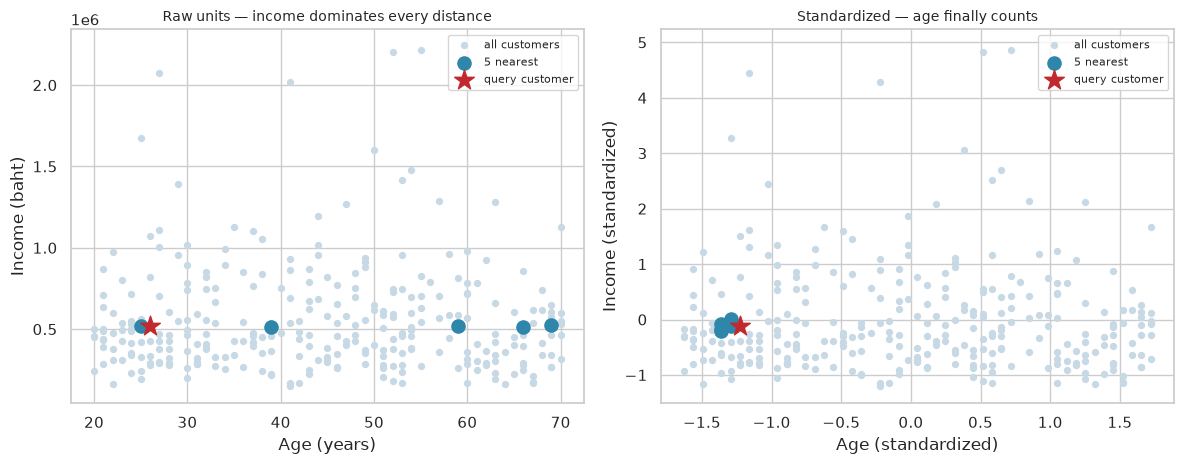

In [43]:
fig, (ax_raw, ax_scaled) = plt.subplots(1, 2, figsize=(12, 4.8))

for ax, frame, q, neighbors, title, xlabel, ylabel in [
    (ax_raw, customers, query, raw_neighbors.index,
     "Raw units — income dominates every distance", "Age (years)", "Income (baht)"),
    (ax_scaled, scaled, query_scaled, scaled_neighbors.index,
     "Standardized — age finally counts", "Age (standardized)", "Income (standardized)"),
]:
    ax.scatter(frame["age"], frame["income"], s=18, color="#C7D9E5", label="all customers")
    ax.scatter(frame.loc[neighbors, "age"], frame.loc[neighbors, "income"],
               s=90, color="#2E86AB", label="5 nearest")
    ax.scatter([q["age"]], [q["income"]], s=220, marker="*", color="#C1292E",
               zorder=5, label="query customer")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**How to read it:** in raw units, "nearest" means *nearest in income* and nothing else — the five neighbors
have almost the same income as the query customer and ages scattered across the whole range, because a 40-year
age gap contributes 40 to a distance that is already measured in tens of thousands. Age is not
under-weighted; it is effectively ignored.

After standardizing, both features contribute on comparable terms, and the neighbors are people who are
*similar in both respects* — the mean age gap collapses. Look at the left panel: the whole population is
squashed into a vertical line, which is exactly what the distance calculation "sees".

Neither picture is correct in the abstract. But if you intended age and income to matter equally, only the
second one does what you meant.

**Which methods need scaling?**

| Needs scaling | Does not need scaling |
|---|---|
| k-means, k-nearest neighbors, hierarchical clustering | Decision trees, random forests, gradient boosting |
| PCA and other distance/variance-based reductions | Rule-based systems |
| Neural networks (for stable training) | Naive Bayes (in its usual forms) |
| Regression with regularization | Plain linear regression (coefficients simply rescale) |

### 6.2 A third option: robust scaling

Min-max normalization has a specific weakness. Because it divides by `max - min`, **one extreme value squashes
everything else into a tiny corner of the 0–1 range.**

In [44]:
# A column with one extreme value — a typo that added two zeros.
values = pd.Series([18, 22, 25, 31, 28, 24, 26, 23, 27, 2_800])

minmax = (values - values.min()) / (values.max() - values.min())
zscore = (values - values.mean()) / values.std()
q1, q3 = values.quantile([0.25, 0.75])
robust = (values - values.median()) / (q3 - q1)

comparison = pd.DataFrame({"original": values, "min-max": minmax.round(4),
                           "z-score": zscore.round(2), "robust": robust.round(2)})
print(comparison.to_string(index=False))
print(f"\nThe nine ordinary values now occupy min-max range "
      f"[{minmax[:9].min():.4f}, {minmax[:9].max():.4f}] — a span of {minmax[:9].max()-minmax[:9].min():.4f}.")
print("Almost all of the 0-1 range is reserved for the single outlier.")

 original  min-max  z-score  robust
       18   0.0000    -0.32   -1.67
       22   0.0014    -0.32   -0.78
       25   0.0025    -0.32   -0.11
       31   0.0047    -0.31    1.22
       28   0.0036    -0.31    0.56
       24   0.0022    -0.32   -0.33
       26   0.0029    -0.31    0.11
       23   0.0018    -0.32   -0.56
       27   0.0032    -0.31    0.33
     2800   1.0000     2.85  616.56

The nine ordinary values now occupy min-max range [0.0000, 0.0047] — a span of 0.0047.
Almost all of the 0-1 range is reserved for the single outlier.


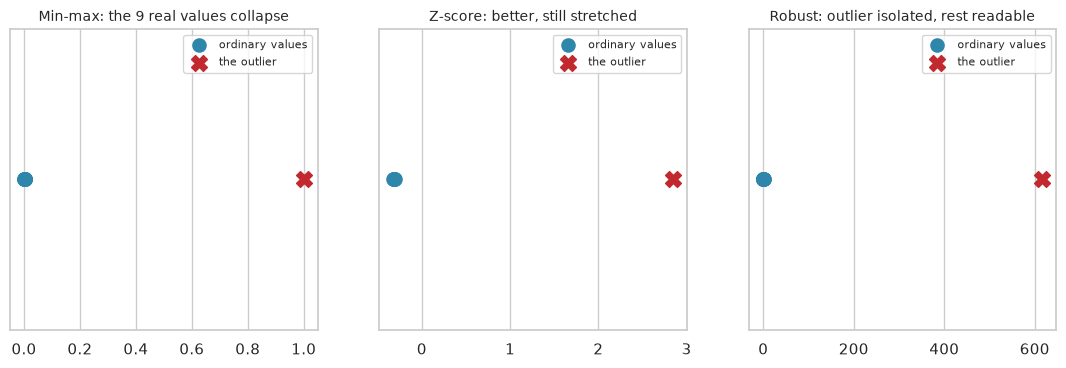

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))
for ax, series, title in [(axes[0], minmax, "Min-max: the 9 real values collapse"),
                          (axes[1], zscore, "Z-score: better, still stretched"),
                          (axes[2], robust, "Robust: outlier isolated, rest readable")]:
    ax.scatter(series[:9], np.zeros(9), s=90, color="#2E86AB", label="ordinary values")
    ax.scatter(series[9:], [0], s=130, color="#C1292E", marker="X", label="the outlier")
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
plt.show()

**How to read it:** in the min-max panel the nine ordinary values are indistinguishable — they have been
compressed into a sliver near zero so that the single typo can occupy the rest of the scale. Robust scaling
divides by the interquartile range and centers on the median, neither of which the outlier can move much, so
the ordinary values stay spread out and readable.

| Method | Formula | Use when |
|---|---|---|
| **Min-max** | (x − min) / (max − min) | You need a bounded 0–1 range and have no outliers |
| **Z-score** | (x − mean) / s.d. | The default; data roughly symmetric |
| **Robust** | (x − median) / IQR | Outliers are present and you do not want to remove them |

### 6.3 The rule that catches almost everyone: fit on the training data only

Every preprocessing step that *learns something from the data* — a mean for filling, a min and max for
scaling, a list of top categories — must learn it from the **training set alone**, then apply the same learned
values to the test set.

Getting this wrong is called **data leakage**, and it is the single most common reason a model that looked
excellent in a notebook performs badly in production.

In [46]:
rng_leak = np.random.default_rng(888102)

data = pd.Series(rng_leak.normal(50, 10, 200))
train, test = data[:150], data[150:]

# WRONG: scale using statistics computed from everything.
all_mean, all_std = data.mean(), data.std()
test_wrong = (test - all_mean) / all_std

# RIGHT: learn the statistics on the training set, then apply them unchanged.
train_mean, train_std = train.mean(), train.std()
test_right = (test - train_mean) / train_std

print(f"Statistics from ALL the data : mean {all_mean:.3f}, s.d. {all_std:.3f}")
print(f"Statistics from TRAINING only: mean {train_mean:.3f}, s.d. {train_std:.3f}")
print(f"\nThey differ slightly — and that difference is information about the test set")
print("that has silently entered the preprocessing.\n")
print(f"Largest disagreement between the two scaled test sets: "
      f"{(test_wrong - test_right).abs().max():.4f}")

Statistics from ALL the data : mean 49.696, s.d. 9.319
Statistics from TRAINING only: mean 49.798, s.d. 9.379

They differ slightly — and that difference is information about the test set
that has silently entered the preprocessing.

Largest disagreement between the two scaled test sets: 0.0267


**How to read it:** the numerical difference here is small, and that is exactly what makes leakage so hard to
notice — nothing looks wrong. The problem is not the size of the difference but its *direction*: the test set
helped decide how the test set would be scaled, so the evaluation is no longer an honest estimate of
performance on data the model has never seen.

The discipline is simple and non-negotiable:

1. **Split first**, before any cleaning that learns from data.
2. **Fit** the imputer, scaler, and encoder on the training set.
3. **Transform** both sets with those same fitted values.

This is exactly why scikit-learn separates `.fit()` from `.transform()`, and why its `Pipeline` object exists
— it makes the correct order the easy one. Chapters 9 and 10 use it throughout.

> ✏️ **Try it:** change the split so the test set is the *first* 150 values and the training set the last 50.
> Does the disagreement grow? What does that suggest about splitting time-ordered data at random?

## 7. Summary — a data-cleaning checklist

When you receive a new dataset, walk through this checklist — it covers everything
in this chapter:

| Step | Question | Tool |
|---|---|---|
| 1. First look | What columns, types, size? | `df.head()`, `df.info()`, `df.dtypes` |
| 2. Missing values | Any gaps? Drop, fill, or predict? | `df.isna().sum()`, `dropna()`, `fillna()` |
| 3. Duplicates | Any repeated records? | `df.duplicated().sum()`, `drop_duplicates()` |
| 4. Formats & types | Dates as dates? Numbers as numbers? | `pd.to_datetime()`, `pd.to_numeric()`, `astype()` |
| 5. Validity | Do values obey the rules? | comparisons, `str.match()`, reference tables |
| 6. Encoding | Categories needed as numbers? | `pd.get_dummies()`, `.map()` |
| 7. Scaling | Features on the same scale? | min-max formula, z-score formula |

And keep the seven **quality dimensions** in mind — accuracy, completeness,
consistency, timeliness, validity, uniqueness, conformity — they tell you *what
to look for*; the checklist tells you *how to fix it*.

Now it's your turn. 👇


---
## 7.1 Putting it together — one messy table, end to end

Everything above, applied once to a single deliberately awful dataset. Read the raw table first and try to
count the problems yourself before running the cleaning cell.

In [47]:
messy = pd.DataFrame({
    "booking_id": [1001, 1002, 1003, 1003, 1004, 1005, 1006, 1007],
    "guest":      [" Somchai ", "Nara", "somchai", "somchai", "Ploy", None, "Anan", "Nara"],
    "city":       ["Chiang Mai", "CM", "chiang  mai", "chiang  mai", "Bangkok", "BKK", "Chiang Rai", "CM"],
    "check_in":   ["2026/8/1", "08/02/2026", "2026-08-03", "2026-08-03",
                   "2026/8/4", "08/05/2026", "2026-08-06", "08/07/2026"],
    "nights":     ["3", "2", "1", "1", "4", "2", "TWO", "3"],
    "rate_thb":   ["1,200", "950", "1,100", "1,100", "2,400", "1,050", "980", "-950"],
    "room_type":  ["Deluxe", "standard", "DELUXE", "DELUXE", "Suite", "Standard", "deluxe", "standard"],
})
print(f"{len(messy)} rows, {messy.shape[1]} columns. How many problems can you spot?\n")
messy

8 rows, 7 columns. How many problems can you spot?



,booking_id,guest,city,check_in,nights,rate_thb,room_type
0,1001,Somchai,Chiang Mai,2026/8/1,3,"1,200",Deluxe
1,1002,Nara,CM,08/02/2026,2,950,standard
2,1003,somchai,chiang mai,2026-08-03,1,"1,100",DELUXE
3,1003,somchai,chiang mai,2026-08-03,1,"1,100",DELUXE
4,1004,Ploy,Bangkok,2026/8/4,4,"2,400",Suite
5,1005,NaN,BKK,08/05/2026,2,"1,050",Standard
6,1006,Anan,Chiang Rai,2026-08-06,TWO,980,deluxe
7,1007,Nara,CM,08/07/2026,3,-950,standard


In [48]:
# Step 0 — a health check, before touching anything.
print("Dtypes (everything is text, which is already a warning):")
print(messy.dtypes.to_string())
print(f"\nMissing values:\n{messy.isna().sum().to_string()}")
print(f"\nFully duplicated rows: {messy.duplicated().sum()}")
print(f"Duplicated booking_id : {messy['booking_id'].duplicated().sum()}")

Dtypes (everything is text, which is already a warning):
booking_id    int64
guest           str
city            str
check_in        str
nights          str
rate_thb        str
room_type       str

Missing values:
booking_id    0
guest         1
city          0
check_in      0
nights        0
rate_thb      0
room_type     0

Fully duplicated rows: 1
Duplicated booking_id : 1


In [49]:
clean = messy.copy()
report = []

# 1. UNIQUENESS — drop the exact duplicate row.
before = len(clean)
clean = clean.drop_duplicates().reset_index(drop=True)
report.append(f"dropped {before - len(clean)} exact duplicate row(s)")

# 2. CONFORMITY — normalize the free-text columns.
clean["guest"] = clean_category(clean["guest"])
clean["city"] = clean_category(clean["city"], {"cm": "chiang mai", "bkk": "bangkok"})
clean["room_type"] = clean["room_type"].str.strip().str.title()

# 3. CONFORMITY — parse the three date styles into real datetimes.
clean["check_in"] = pd.to_datetime(clean["check_in"], format="mixed", dayfirst=False)

# 4. DATATYPES — numbers currently stored as text, with separators and a word.
clean["nights"] = pd.to_numeric(clean["nights"].replace({"TWO": "2"}), errors="coerce")
clean["rate_thb"] = pd.to_numeric(clean["rate_thb"].str.replace(",", "", regex=False),
                                  errors="coerce")

# 5. VALIDITY — a rate cannot be negative; treat it as unknown rather than guessing.
invalid_rate = clean["rate_thb"] < 0
report.append(f"marked {invalid_rate.sum()} negative rate(s) as missing")
clean.loc[invalid_rate, "rate_thb"] = np.nan

# 6. COMPLETENESS — record what was missing, then fill.
clean["rate_was_missing"] = clean["rate_thb"].isna()
clean["guest_was_missing"] = clean["guest"].isna() | (clean["guest"] == "None")
clean.loc[clean["guest"] == "None", "guest"] = np.nan
median_rate = clean.groupby("room_type")["rate_thb"].transform("median")
clean["rate_thb"] = clean["rate_thb"].fillna(median_rate)
report.append(f"filled {clean['rate_was_missing'].sum()} rate(s) with the median for that room type")

# 7. Derived column, now that the types are right.
clean["total_thb"] = clean["nights"] * clean["rate_thb"]

print("Cleaning report:")
for line in report:
    print(f"  - {line}")
print()
clean

Cleaning report:
  - dropped 1 exact duplicate row(s)
  - marked 1 negative rate(s) as missing
  - filled 1 rate(s) with the median for that room type



,booking_id,guest,city,check_in,nights,rate_thb,room_type,rate_was_missing,guest_was_missing,total_thb
0,1001,Somchai,Chiang Mai,2026-08-01,3,1200.0,Deluxe,False,False,3600.0
1,1002,Nara,Chiang Mai,2026-08-02,2,950.0,Standard,False,False,1900.0
2,1003,Somchai,Chiang Mai,2026-08-03,1,1100.0,Deluxe,False,False,1100.0
3,1004,Ploy,Bangkok,2026-08-04,4,2400.0,Suite,False,False,9600.0
4,1005,NaN,Bangkok,2026-08-05,2,1050.0,Standard,False,True,2100.0
5,1006,Anan,Chiang Rai,2026-08-06,2,980.0,Deluxe,False,False,1960.0
6,1007,Nara,Chiang Mai,2026-08-07,3,1000.0,Standard,True,False,3000.0


In [50]:
print("Final health check:")
print(clean.dtypes.to_string())
print(f"\nRows: {len(clean)} (from {len(messy)})")
print(f"Missing values remaining:\n{clean.isna().sum()[clean.isna().sum() > 0].to_string() or '  none'}")
print(f"\nDistinct cities: {sorted(clean['city'].dropna().unique())}")
print(f"Distinct room types: {sorted(clean['room_type'].unique())}")
print(f"\nTotal revenue: {clean['total_thb'].sum():,.0f} THB")

Final health check:
booking_id                    int64
guest                           str
city                            str
check_in             datetime64[us]
nights                        int64
rate_thb                    float64
room_type                       str
rate_was_missing               bool
guest_was_missing              bool
total_thb                   float64

Rows: 7 (from 8)
Missing values remaining:
guest    1

Distinct cities: ['Bangkok', 'Chiang Mai', 'Chiang Rai']
Distinct room types: ['Deluxe', 'Standard', 'Suite']

Total revenue: 23,260 THB


**How to read it:** every step maps to one of the seven quality dimensions, and the `report` list is doing the
most important job in the cell — **recording what was changed**. A cleaning script that transforms data
silently is unauditable, and six months later nobody, including you, will remember why the totals moved.

Note two judgment calls that the code makes visible rather than hiding:

- `"TWO"` was translated to `2`. That is a guess about intent. It is almost certainly right, and it is still a
  guess, which is why it sits in an explicit lookup rather than in a general "convert words to numbers" step.
- The negative rate was marked **missing** rather than corrected to positive. Without a source document to
  check against, `-950` might be a sign error or a refund, and inventing one interpretation would be worse
  than admitting we do not know.

Look closely at the two `guest` lines in the cleaning cell. `clean_category` begins with `.astype(str)`,
which turns a real missing value into the **string** `"None"` — a classic and very easy bug, because the
column then looks populated while containing a word instead of a name. The next two lines detect that string
and convert it back to a proper `NaN`, which is why the final health check reports one missing guest rather
than a guest called "None".

> ✏️ **Try it:** delete those two repair lines and re-run. How many missing guests does the final health check
> report now, and what would `clean["guest"].value_counts()` show? Then fix `clean_category` itself so it
> preserves missing values instead of stringifying them — that is the better place for the fix.

---
## 7.2 Glossary — Part I

| Term | Meaning |
|---|---|
| **Data preparation / wrangling / preprocessing** | Making raw data suitable for analysis |
| **Data integrity** | Accuracy, completeness, and quality maintained over time and formats |
| **Garbage in, garbage out** | Bad input data produces bad conclusions, however good the method |
| **Accuracy** | Values match the real world or an agreed reference |
| **Completeness** | No required values are missing |
| **Consistency** | The same fact agrees across sources |
| **Timeliness** | The lag between the event and its availability is acceptable |
| **Validity** | Values obey a known rule, range, or pattern |
| **Uniqueness** | Each real-world entity appears exactly once |
| **Conformity** | One attribute uses one format and one type throughout |
| **Entity resolution** | Deciding whether two records describe the same real thing |
| **MCAR / MAR / MNAR** | Missing completely at random / at random / not at random |
| **Imputation** | Filling a missing value with an estimate |
| **Missingness indicator** | A flag column recording that a value was originally absent |
| **Outlier** | A value far from the rest; not automatically an error |
| **IQR rule** | Flag values outside Q1 − 1.5×IQR or Q3 + 1.5×IQR |
| **Masking** | Outliers inflating the mean and s.d. so they escape a z-score rule |
| **Winsorizing** | Clipping extreme values to a threshold instead of deleting them |
| **Concatenate vs. merge** | Stack rows with the same columns / join columns on a shared key |
| **One-hot encoding** | One 0/1 column per category, for nominal variables |
| **Ordinal encoding** | One increasing number per category, respecting a real order |
| **Dummy variable trap** | One-hot columns being perfectly predictable from each other |
| **High cardinality** | A category column with so many values that one-hot explodes |
| **Normalization (min-max)** | Rescale to the 0–1 range |
| **Standardization (z-score)** | Rescale to mean 0, standard deviation 1 |
| **Robust scaling** | Rescale using the median and IQR, resisting outliers |
| **Data leakage** | Information from the test set influencing training or preprocessing |

---
## 7.3 Check your understanding — Part I

**Q1.** A survey has 30% missing income values, and the people who skipped it were mostly high earners. Which
mechanism is this, and can you impute your way out of it?

<details><summary>Answer</summary>

MNAR — missing not at random. No, you cannot impute your way out. The missingness depends on the missing value
itself, so every fill is systematically too low. The honest response is to report the missingness rate and
treat conclusions about the mean income as unreliable.
</details>

**Q2.** Why did the z-score rule flag fewer outliers than the IQR rule in Section 4.5?

<details><summary>Answer</summary>

Masking. The extreme values inflate the mean and especially the standard deviation, pushing the ±3 s.d.
boundary outward until it encloses the very points it was meant to catch. Quartiles barely move when extreme
values are added, so the IQR rule does not suffer from this.
</details>

**Q3.** A festival day has ten times normal sales. Should you delete it?

<details><summary>Answer</summary>

No. It is real, and it is probably the most commercially interesting day in the data. Deleting a value because
it is extreme, rather than because it is wrong, is fabricating a tidier dataset than the one that exists. If it
distorts an average, report the median as well, or analyze festival days separately.
</details>

**Q4.** You concatenate three branch reports and the row count is right, but the total is too low. What is the
first thing to check?

<details><summary>Answer</summary>

Column names. `pd.concat` aligns on names, so `"Sales"` and `"sales"` become two separate columns, each half
full of `NaN`. Summing one of them misses the other branch entirely. Standardize names before combining.
</details>

**Q5.** Merging 500 customers with 3,000 orders gives 3,000 rows. You compute the mean of the `age` column.
What did you actually measure?

<details><summary>Answer</summary>

The mean age *per order*, not per customer — each customer's age is repeated once for every order they placed,
so frequent buyers are weighted more heavily. To get the mean customer age, deduplicate on `customer_id` first.
</details>

**Q6.** Why encode Poor/Good/Excellent as 1/2/3 but Red/Yellow/Green as three separate columns?

<details><summary>Answer</summary>

Because ratings have a real order and colors do not. Encoding colors as 1/2/3 would tell the model that Green
is three times Red and that Yellow lies between them — an ordering that does not exist. This is the Chapter 2
nominal-versus-ordinal distinction, cashed out in code.
</details>

**Q7.** Your product column has 120,000 distinct SKUs. What is wrong with one-hot encoding it?

<details><summary>Answer</summary>

It creates 120,000 columns, which is computationally impossible as a dense table and statistically useless —
most SKUs appear in too few rows to estimate anything. Keep the top few dozen and bucket the rest as "Other",
use a sparse representation, or use a model that handles categories natively.
</details>

**Q8.** You normalize a column to 0–1 and every value except one lands between 0.00 and 0.01. Why?

<details><summary>Answer</summary>

Min-max divides by `max − min`, so a single extreme value stretches the denominator and compresses everything
else into a sliver. Either handle the outlier first or use robust scaling, which divides by the IQR instead.
</details>

**Q9.** You fill missing values with the column mean, then split into training and test sets, and your model
scores brilliantly. What is the problem?

<details><summary>Answer</summary>

Data leakage. The mean was computed using the test set, so information about the test set entered the training
data and the score is optimistic. Split first, compute the fill from the training set only, and apply it to
both.
</details>

**Q10.** Which quality dimension can never be checked from inside the dataset, and why does that matter?

<details><summary>Answer</summary>

Accuracy. Whether a value matches reality requires an external reference — the airports example needed an
official IATA list. It matters because a dataset can pass every automated check and still be wrong about the
world.
</details>

## 8. Homework A (Data Preparation) 📝

**Instructions**

- Complete all **6 exercises** (plus the bonus if you want an extra challenge).
- Write your code in the empty cells below each question — replace `# YOUR CODE HERE`.
- Answer the short interpretation questions **in the markdown cell** provided
  (double-click the cell to edit, `Shift + Enter` when done).
- When finished: `File ▸ Save`, then submit this `.ipynb` file.

First, fill in your details:


### 👤 Student information

- **Name:** *(double-click here and type your name)*
- **Student ID:**
- **Date:**


### The homework dataset — 🏨 Riverside Hotel

You are the new data analyst of *Riverside Hotel* in Chiang Mai. The receptionist
kept the booking records in a spreadsheet… not very carefully. Run the cell below
to create the dataset (do **not** modify it). It contains booking records with
these columns:

| Column | Meaning | Problems hiding inside |
|---|---|---|
| `booking_id` | unique ID of the booking | some rows were entered twice |
| `room_type` | Standard, Deluxe, Suite | nominal categorical |
| `check_in` | check-in date, written as `DD-MM-YYYY` | stored as text |
| `nights` | number of nights | numerical |
| `guests` | number of guests | some values are missing |
| `price_total` | total price of the stay | stored as text, some with `" baht"` and commas |
| `satisfaction` | guest rating: Poor / Good / Very Good / Excellent | ordinal, some values missing |


In [51]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
rng = np.random.default_rng(888102)
n = 120

room_type = rng.choice(["Standard", "Deluxe", "Suite"], n, p=[0.5, 0.35, 0.15])
nights = rng.integers(1, 8, n)
guests = rng.integers(1, 5, n).astype(float)
base_price = {"Standard": 900, "Deluxe": 1500, "Suite": 2800}
price = [base_price[r] * k + int(rng.choice([0, 50, 100])) for r, k in zip(room_type, nights)]
satisfaction = rng.choice(["Poor", "Good", "Very Good", "Excellent"], n, p=[0.1, 0.35, 0.35, 0.2])
day = rng.integers(1, 29, n)
month = rng.integers(1, 13, n)

bookings = pd.DataFrame({
    "booking_id": np.arange(2001, 2001 + n),
    "room_type": room_type,
    "check_in": [f"{d:02d}-{m:02d}-2025" for d, m in zip(day, month)],
    "nights": nights,
    "guests": guests,
    "price_total": [f"{p:,} baht" if p >= 10000 else str(p) for p in price],
    "satisfaction": satisfaction,
})

# ...and now the receptionist's mistakes:
bookings.loc[rng.choice(n, 12, replace=False), "guests"] = np.nan        # forgot the guests
bookings.loc[rng.choice(n, 8, replace=False), "satisfaction"] = np.nan   # forgot the rating
dupes = bookings.sample(6, random_state=888102)                          # entered 6 bookings twice
bookings = (pd.concat([bookings, dupes])
              .sample(frac=1, random_state=888102)                       # shuffle the rows
              .reset_index(drop=True))

print("Dataset created:", bookings.shape[0], "rows,", bookings.shape[1], "columns")
bookings.head(8)

Dataset created: 126 rows, 7 columns


,booking_id,room_type,check_in,nights,guests,price_total,satisfaction
0,2065,Standard,10-07-2025,7,4.0,6400,Very Good
1,2024,Suite,12-11-2025,4,1.0,"11,250 baht",Good
2,2008,Deluxe,17-01-2025,4,3.0,6100,Very Good
3,2049,Standard,18-12-2025,7,NaN,6350,Poor
4,2019,Standard,06-06-2025,2,NaN,1800,Excellent
5,2092,Standard,14-12-2025,3,1.0,2800,Very Good
6,2080,Suite,05-11-2025,3,4.0,8400,Poor
7,2102,Deluxe,25-12-2025,5,2.0,7500,Very Good


---
### Exercise 1 — First look 🔍

Inspect the dataset before touching anything:

1. Show the **shape** (rows, columns) and the **dtypes** of every column.
2. Count the **missing values** in every column (hint: `isna().sum()`).

**Question 1:** Which columns have missing values? Which columns have the *wrong
datatype* (look at `price_total` and `check_in`)?


In [52]:
# YOUR CODE HERE (Exercise 1)


**✍️ Your answer to Question 1:** *(double-click to edit)*

---
### Exercise 2 — Duplicates

1. Count how many rows are exact **duplicates** (hint: `duplicated().sum()`).
2. Remove them with `drop_duplicates()` and save the result as `bookings_clean`.
3. Print the number of rows before and after.

**Question 2:** How many duplicated rows did you find? Why is it important to
remove duplicates *before* computing statistics such as the hotel's total revenue?


In [53]:
# YOUR CODE HERE (Exercise 2)


**✍️ Your answer to Question 2:**

---
### Exercise 3 — Missing values

Work on `bookings_clean` from Exercise 2:

1. Fill the missing `guests` with the **median** number of guests
   (hint: `fillna(...)` — the median of a whole column is `col.median()`).
2. Fill the missing `satisfaction` with the **most frequent** rating
   (hint: `col.mode()[0]` gives the most frequent value).
3. Check with `isna().sum()` that no missing values remain.

**Question 3:** Why is the *median* a reasonable choice for `guests`, and the
*most frequent value* a reasonable choice for `satisfaction`? (Hint: what kind of
variable is each one?)


In [54]:
# YOUR CODE HERE (Exercise 3)


**✍️ Your answer to Question 3:**

---
### Exercise 4 — Fix formats and datatypes

Still on `bookings_clean`:

1. Convert `price_total` to real numbers. You will need to remove the text
   `" baht"` and the thousands commas first
   (hint: `.str.replace(" baht", "")` then `.str.replace(",", "")`, then
   `pd.to_numeric(...)`). Save it in a new column `price_num`.
2. Convert `check_in` to real dates
   (hint: `pd.to_datetime(..., format="%d-%m-%Y")`).
3. Show `dtypes` again to confirm both columns changed.

**Question 4:** What was the average booking price (`price_num.mean()`)? Could
you have computed it *before* this exercise? Why not?


In [55]:
# YOUR CODE HERE (Exercise 4)


**✍️ Your answer to Question 4:**

---
### Exercise 5 — Encoding categorical data

1. **One-hot encode** `room_type` with `pd.get_dummies(...)` and show the first
   few rows.
2. **Ordinal encode** `satisfaction` into a new column `satisfaction_num` using a
   dictionary and `.map(...)` — respect the order
   Poor = 1 < Good = 2 < Very Good = 3 < Excellent = 4.

**Question 5:** Why do we one-hot encode `room_type` but ordinal-encode
`satisfaction`? What would go wrong if we encoded `room_type` as
Standard = 1, Deluxe = 2, Suite = 3?


In [56]:
# YOUR CODE HERE (Exercise 5)


**✍️ Your answer to Question 5:**

---
### Exercise 6 — Normalization and standardization

Use the numeric price column `price_num` from Exercise 4:

1. **Normalize** it with the min-max formula and **standardize** it with the
   z-score formula (write the formulas yourself, like in section 6).
2. Plot the histograms of the original, normalized, and standardized prices side
   by side (three subplots). Add titles and axis labels.
3. Print the min and max of the normalized version, and the mean and standard
   deviation of the standardized version, to verify the formulas worked.

**Question 6:** Compare the three histograms. What changed, and what stayed
exactly the same?


In [57]:
# YOUR CODE HERE (Exercise 6)


**✍️ Your answer to Question 6:**

---
### Bonus — Build a cleaning pipeline 🚀

Write **one function** `clean_bookings(df)` that takes the raw `bookings`
DataFrame and performs the whole cleanup from Exercises 2–5 in order: remove
duplicates → fill missing values → fix `price_num` and `check_in` → add
`satisfaction_num`. The function must **return the cleaned DataFrame** and print
a short report: rows before, rows after, and missing values remaining.

Then call it on the raw data: `clean_bookings(bookings)`.

**Bonus question:** Why is it useful to have the whole cleanup in a single
function, instead of scattered cells? (Hint: what happens when the hotel sends
you next month's spreadsheet?)


In [58]:
# YOUR CODE HERE (Bonus)


**✍️ Your answer to the bonus question:**

---
🎉 **Well done!** You have practiced the full data preparation workflow from
Chapter 6: inspecting a dataset, removing duplicates, handling missing values,
fixing formats and datatypes, encoding categorical data, and scaling numeric data.

**Checklist before submitting:**

- [ ] Every cell runs without errors (`Kernel ▸ Restart & Run All` is a good final test)
- [ ] All six ✍️ answers are filled in
- [ ] Your charts in Exercise 6 have titles and axis labels
- [ ] Your name and student ID are at the top of the homework section


---
# 🌉 From Part I to Part II — why visualization comes next

In Part I you turned a messy spreadsheet into a clean, well-typed table. But a
clean table is still just numbers — to *understand* it (and to show it to your
boss, your customers, or your professor) you need pictures.

In fact, visualization already sneaked into Part I twice:

- we **plotted** ice-cream sales against temperature to fill missing values
  intelligently (section 4.1), and
- we used **histograms** to see that normalization and standardization change the
  scale but never the shape (section 6).

That is no accident: **cleaning and visualizing form a loop.** You clean a bit,
plot it, spot something strange (an outlier, a gap, an impossible value), clean
again. Part II gives you the full toolbox for the "plot it" half: which chart fits
which data type, how to build every chart in Python, and how to read them like a
data scientist.

> ⚠️ One rule carries over directly: **never visualize dirty data.** Every chart
> in Part II assumes the data behind it has passed the Part I checklist first.


# Part II — Chapter 7: Data Visualization

*(self-study slides: `Chapter_07_Data_Visualisation.pdf`)*

## Learning objectives

By the end of Part II you will be able to:

1. **Understand the principles** of data visualization used for different data types.
2. **Select and create** visualizations with data.
3. **Interpret and understand** graphs of distributions for different data types.

## Part II outline

1. What is data visualization? — including **1.1 the three jobs a chart can do**: record, explore, explain
2. Getting started with Python plotting — including **2.1 what the human eye judges accurately**
3. **Visualization for numerical data** — histogram, density, boxplot, violin, scatter, line, heatmap, bubble, correlogram
4. **Visualization for categorical data** — bar, grouped bar, stacked bar, 100% stacked bar, pie, treemap
5. **Map and network** — choropleth, bubble map, network, and why raw counts mislead on a map
6. Summary — how to choose the right chart
7. **How the same data can tell three different stories** — truncated axes, dual axes, color, small multiples
8. Glossary · 9. Self-check quiz · 10. Key takeaways
11. [**Homework B**](#7.-Homework) 📝


## 1. What is data visualization?

> Data visualization is a way to **communicate information clearly and efficiently**
> to users via graphics, plots, information graphics, tables, and charts.

Humans are much better at spotting patterns in *pictures* than in *tables of numbers*.
A good chart can reveal a trend, an outlier, or a relationship in seconds.

### Functions of visualizations

| Function | What it means | Examples |
|---|---|---|
| **Record** information | Store a visual snapshot of reality | Photographs, blueprints |
| **Explore** information (analyze) | Process, calculate and reason about data; get feedback and interact | A histogram of SAT scores to see the distribution |
| **Explain** information (present) | Share, persuade, collaborate, and emphasize important aspects of data | A map of customers per state; a heat map of store sales (best = green, worst = red) |

### Two big families of data

The correct chart depends on the **type of data** you have:

- **Numerical (quantitative)** data — numbers you can measure: age, height, temperature, price…
- **Categorical (qualitative)** data — labels or groups: passenger class, movie title, political party, drink type…

Keep this distinction in mind — it is the theme of the whole chapter.

### 1.1 Three jobs a chart can do

Every visualization exists to **record**, **explore**, or **explain** — and knowing which one you are making
changes how you build it.

| Job | Purpose | Goal | Typical example |
|---|---|---|---|
| **Record** | Keep a faithful trace of what happened | Accuracy, not persuasion | A technical photograph of a bridge crack, a blueprint, a lab micrograph |
| **Explore** | Reason about data you do not understand yet | Reveal everything, including surprises | A heat map highlighting the best- and worst-performing store |
| **Explain** | Share a conclusion and persuade an audience | Make one point land | A map coloring provinces by COVID-19 case count, for a press briefing |

The distinction is practical, not philosophical. An exploratory chart should be quick, dense, and show
everything — you are looking for what you did not expect, so hiding anything defeats the purpose. An
explanatory chart should be slow to make, sparse, and ruthlessly focused — the audience gets a few seconds and
one idea.

The most common mistake in student work (and in industry) is **showing an exploratory chart to an audience**:
a dense, unlabeled, twelve-series plot that made sense to its author and communicates nothing.

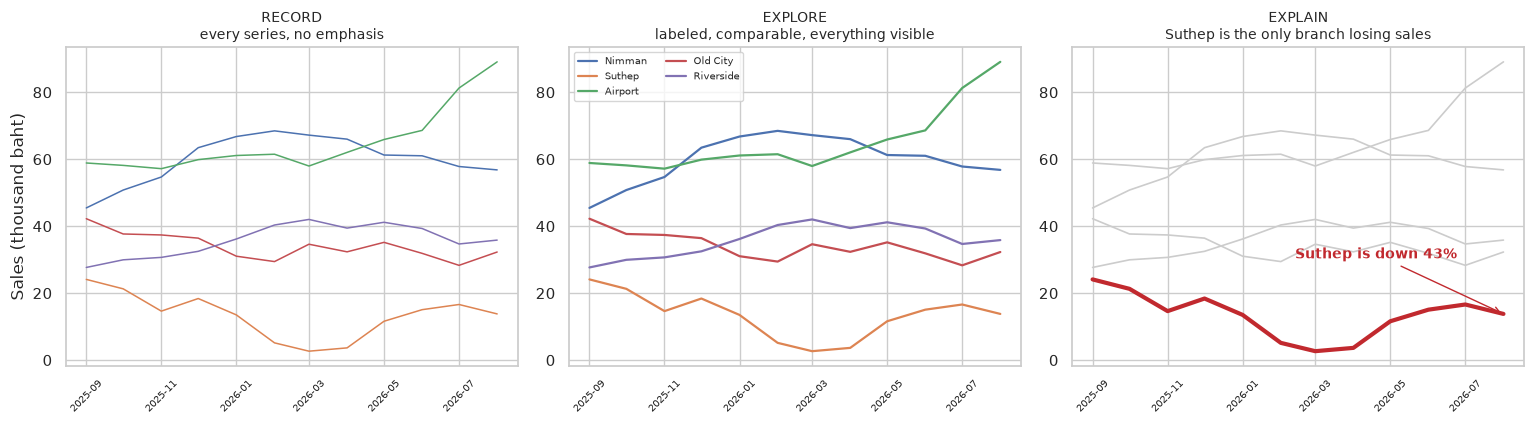

In [59]:
# The same data, drawn for each of the three jobs.
rng_jobs = np.random.default_rng(888102)

months = pd.date_range("2025-09-01", periods=12, freq="MS")
branches = ["Nimman", "Suthep", "Airport", "Old City", "Riverside"]
data = pd.DataFrame(
    {b: (base + np.cumsum(rng_jobs.normal(trend, 4, 12)))
     for b, base, trend in zip(branches, [42, 30, 55, 38, 26], [1.2, -1.6, 0.8, 0.3, 0.5])},
    index=months,
)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))

# RECORD — every number, faithfully, no emphasis.
axes[0].plot(data.index, data.values, linewidth=1.1)
axes[0].set_title("RECORD\nevery series, no emphasis", fontsize=10)
axes[0].set_ylabel("Sales (thousand baht)")
axes[0].tick_params(axis="x", rotation=45, labelsize=7)

# EXPLORE — same data, but ranked and labeled so the analyst can poke at it.
for column in data.columns:
    axes[1].plot(data.index, data[column], linewidth=1.6, label=column)
axes[1].legend(fontsize=7, ncol=2)
axes[1].set_title("EXPLORE\nlabeled, comparable, everything visible", fontsize=10)
axes[1].tick_params(axis="x", rotation=45, labelsize=7)

# EXPLAIN — one point, everything else pushed into the background.
for column in data.columns:
    if column == "Suthep":
        axes[2].plot(data.index, data[column], linewidth=3, color="#C1292E", zorder=5)
    else:
        axes[2].plot(data.index, data[column], linewidth=1.2, color="#CCCCCC")
drop = (data["Suthep"].iloc[-1] / data["Suthep"].iloc[0] - 1) * 100
axes[2].annotate(f"Suthep is down {abs(drop):.0f}%", xy=(data.index[-1], data["Suthep"].iloc[-1]),
                 xytext=(-150, 40), textcoords="offset points", fontsize=10, color="#C1292E",
                 fontweight="bold", arrowprops=dict(arrowstyle="->", color="#C1292E"))
axes[2].set_title("EXPLAIN\nSuthep is the only branch losing sales", fontsize=10)
axes[2].tick_params(axis="x", rotation=45, labelsize=7)

plt.tight_layout()
plt.show()

**How to read it:** identical data in all three panels.

The **record** panel is honest and useless for a meeting — you cannot tell the lines apart. The **explore**
panel adds a legend, which is enough for an analyst willing to spend a minute. The **explain** panel throws
away almost everything: four branches become gray context, one becomes red, and the title *states the finding
rather than naming the axes*.

That last move is the single highest-value habit in this chapter. **A title like "Monthly sales by branch"
describes the chart; a title like "Suthep is the only branch losing sales" delivers the point.** Use the first
when exploring and the second when explaining.

> ✏️ **Try it:** rebuild the third panel to make a *different* point — that Airport is the largest branch.
> Which series turns red, and what does the title become?

## 2. Getting started with Python plotting

We will use four very popular libraries:

| Library | Nickname | What it does |
|---|---|---|
| `pandas` | `pd` | Tables of data (DataFrames) |
| `numpy` | `np` | Fast numeric arrays and random numbers |
| `matplotlib` | `plt` | The foundation plotting library of Python |
| `seaborn` | `sns` | Beautiful statistical charts built on top of matplotlib |

If a library is missing on your computer, install it once with:
`pip install pandas numpy matplotlib seaborn`

In [60]:
# Import the libraries (run this cell first — everything below depends on it!)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# A nice default look for all our charts
sns.set_theme(style="whitegrid")

print("All libraries imported — you are ready to go!")

All libraries imported — you are ready to go!


### Anatomy of a matplotlib figure

Every good chart needs a **title**, **axis labels**, and (when there are several
series) a **legend**. Let's make our very first plot and label every part.

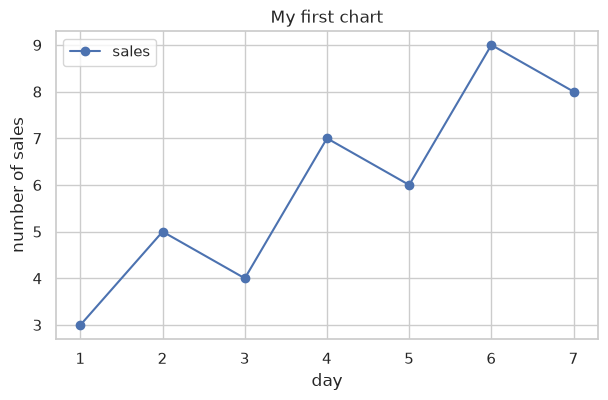

In [61]:
# Our first plot: a simple line
x = [1, 2, 3, 4, 5, 6, 7]
y = [3, 5, 4, 7, 6, 9, 8]

plt.figure(figsize=(7, 4))              # create a figure (width, height in inches)
plt.plot(x, y, marker="o", label="sales")  # draw a line with dot markers
plt.title("My first chart")             # title on top
plt.xlabel("day")                       # label of the horizontal (x) axis
plt.ylabel("number of sales")           # label of the vertical (y) axis
plt.legend()                            # box explaining each series
plt.show()                              # display the figure

**Remember this recipe** — almost every chart in this notebook follows it:

1. `plt.figure(...)` — start a figure
2. one or more *drawing* commands (`plt.plot`, `sns.histplot`, …)
3. `plt.title`, `plt.xlabel`, `plt.ylabel` — always label your chart!
4. `plt.show()` — display it

> ✏️ **Try it:** change the `marker` to `"s"` (square) and the figure size to `(10, 3)`, then re-run the cell.

### 2.1 What the human eye judges accurately

Before choosing any chart, it helps to know what people are actually good at reading. Cleveland and McGill
tested this experimentally, and the results are remarkably consistent — some visual encodings are read
accurately, others are guessed at:

| Rank | Visual encoding | Accuracy |
|---|---|---|
| 1 | Position along a common scale (bar heights, dot positions on one axis) | Best |
| 2 | Position along identical, non-aligned scales (small multiples) | |
| 3 | Length (bar lengths not sharing a baseline) | |
| 4 | Angle and slope (pie wedges) | |
| 5 | Area (bubble size, treemap rectangles) | |
| 6 | Volume, curvature | |
| 7 | Color saturation and hue (heatmaps, choropleths) | Worst |

This ranking explains most chart advice you will ever be given. Bar charts are the default recommendation
because they use rank 1. Pie charts are discouraged because they use rank 4. Bubble sizes and heatmap colors
are for *spotting patterns*, not for reading values — which is why a heatmap almost always needs a color bar
and a bubble chart usually needs labels.

Let's test it on yourself.

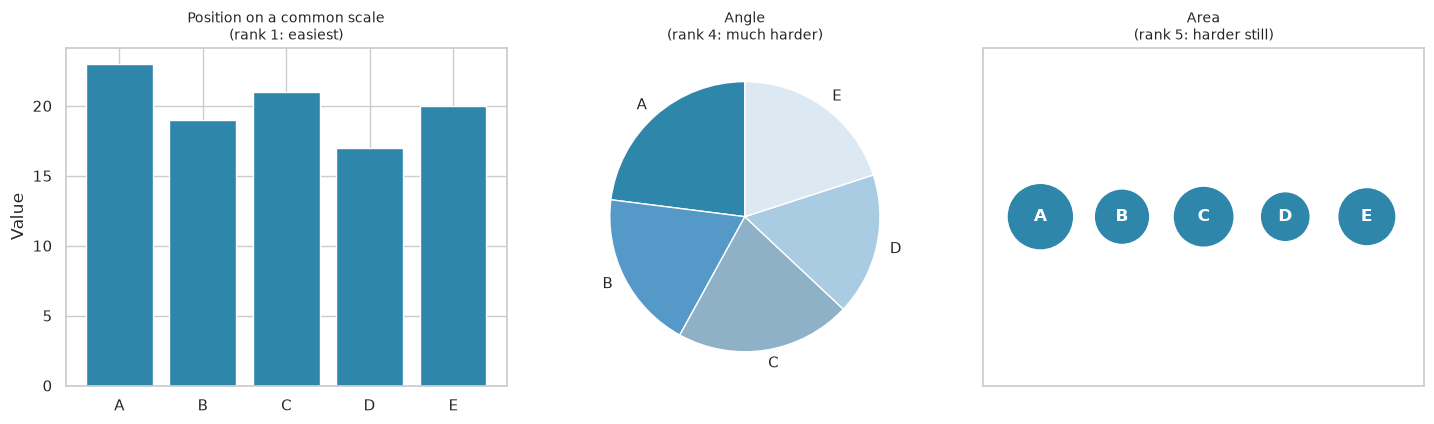

The actual values: {'A': np.int64(23), 'B': np.int64(19), 'C': np.int64(21), 'D': np.int64(17), 'E': np.int64(20)}
Ranked: A > C > E > B > D


In [62]:
# The same five values, encoded three ways. Try to rank them by eye BEFORE reading the numbers.
values = np.array([23, 19, 21, 17, 20])
labels = ["A", "B", "C", "D", "E"]

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4))

# Rank 1 — position along a common scale.
axes[0].bar(labels, values, color="#2E86AB")
axes[0].set_title("Position on a common scale\n(rank 1: easiest)", fontsize=10)
axes[0].set_ylabel("Value")

# Rank 4 — angle.
axes[1].pie(values, labels=labels, startangle=90,
            colors=["#2E86AB", "#5499C7", "#8FB1C7", "#A9CCE3", "#DCE9F2"])
axes[1].set_title("Angle\n(rank 4: much harder)", fontsize=10)

# Rank 5 — area.
axes[2].scatter(range(len(values)), np.zeros(len(values)), s=values ** 2 * 4, color="#2E86AB")
for i, label in enumerate(labels):
    axes[2].annotate(label, (i, 0), ha="center", va="center", color="white", fontweight="bold")
axes[2].set_xlim(-0.7, len(values) - 0.3)
axes[2].set_ylim(-1, 1)
axes[2].set_yticks([])
axes[2].set_xticks([])
axes[2].set_title("Area\n(rank 5: harder still)", fontsize=10)

plt.tight_layout()
plt.show()

print("The actual values:", dict(zip(labels, values)))
print("Ranked:", " > ".join(np.array(labels)[np.argsort(-values)]))

**How to read it:** the five values span only 17 to 23 — a 35% spread. In the bar chart the ranking is
immediate and you can estimate the differences. In the pie chart most people cannot reliably order the wedges
at all. In the area chart the differences look far smaller than they are, because doubling a value more than
doubles the circle's *radius* only if you are careless — and if you size by radius instead of area, the chart
lies outright.

**The practical rules that follow:**

1. Default to bars and dots. Reach for something else only when it does a job bars cannot.
2. Use pie charts for 2–5 categories where "share of the whole" is genuinely the point.
3. Treat bubble size and heatmap color as pattern-finders, not value-readers — always provide numbers too.
4. When you encode with area, scale the **area**, not the radius.

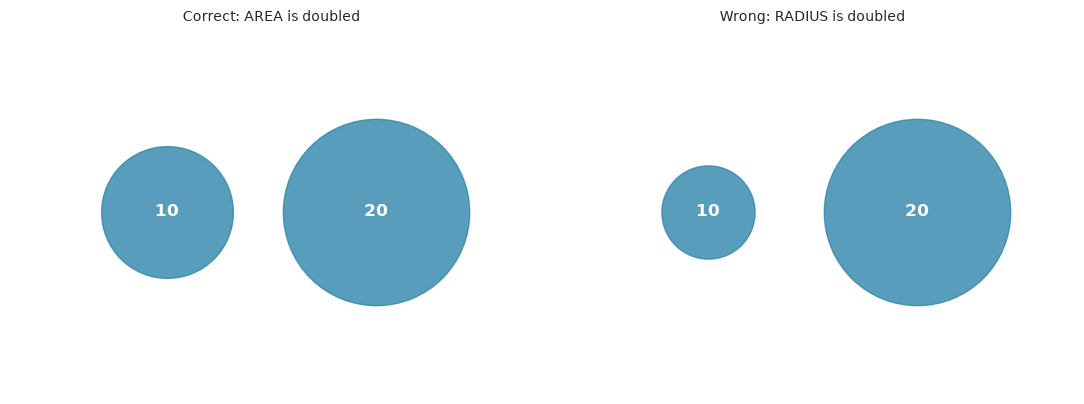

20 is exactly 2x 10.
Doubling the AREA   -> the circle looks about 1.41x wider. Correct.
Doubling the RADIUS -> the circle covers 4x the area, so 20 looks like 40.


In [63]:
# Scaling by radius instead of area: an easy and very common mistake.
value_small, value_large = 10, 20        # the second is exactly twice the first

fig, (ax_area, ax_radius) = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, mode, title in [(ax_area, "area", "Correct: AREA is doubled"),
                        (ax_radius, "radius", "Wrong: RADIUS is doubled")]:
    for x, value in [(0.3, value_small), (0.7, value_large)]:
        size = value * 900 if mode == "area" else (value ** 2) * 45
        ax.scatter([x], [0.5], s=size, color="#2E86AB", alpha=0.8)
        ax.annotate(str(value), (x, 0.5), ha="center", va="center",
                    color="white", fontweight="bold", fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.show()

print(f"20 is exactly 2x 10.")
print(f"Doubling the AREA   -> the circle looks about {np.sqrt(2):.2f}x wider. Correct.")
print(f"Doubling the RADIUS -> the circle covers {2**2}x the area, so 20 looks like 40.")

**How to read it:** on the right, the larger circle covers four times the area of the smaller one, so a reader
judging by area — which is what people do — perceives a value of 40 rather than 20. The chart has doubled the
apparent difference without a single wrong number.

matplotlib's `scatter` takes `s` as an **area** in points squared, which is the correct behavior. Many
spreadsheet tools default to radius. Check before you trust a bubble chart, including your own.

## 3. Visualization for numerical data

For **numerical** variables the lecture introduced these chart types:

| Chart | Best for |
|---|---|
| **Histogram** | Distribution of one numeric variable |
| **Density** | Smooth version of a histogram |
| **Boxplot** | Compact summary (quartiles) of one or several variables |
| **Violin** | Distribution shape for one or several groups |
| **Line** | Evolution of a variable (usually over time) |
| **Scatter** | Relationship between **2** numeric variables |
| **Heatmap** | A matrix of numbers shown as colors |
| **Bubble** | Scatter + a **3rd** variable shown as dot size |
| **Correlogram** | Correlation between every pair of variables |

### 3.1 Histogram

- A histogram takes as input a **numeric variable only**.
- The variable is cut into several **bins** (also called *intervals*, *classes*, or *buckets*) of equal width.
- The number of observations per bin is represented by the **height of the bar**.

💡 The lecture example: the **ages of passengers on the Titanic**. The raw data is a
long list of ages (34.5, 47, 62, 27, …). The histogram groups them into bins
(0–5, 6–10, 11–15, …) and counts how many passengers fall in each bin.

Let's reproduce it with the real Titanic dataset (loaded straight from the internet
by seaborn).

In [64]:
# Load the Titanic passenger data (needs internet the first time)
titanic = sns.load_dataset("titanic")

# Look at the first 5 rows — always inspect your data before plotting!
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [65]:
# How big is the table, and what is the age column like?
print("Number of rows (passengers):", len(titanic))
print("Passengers with a known age:", titanic["age"].notna().sum())
titanic["age"].describe()

Number of rows (passengers): 891
Passengers with a known age: 714


count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

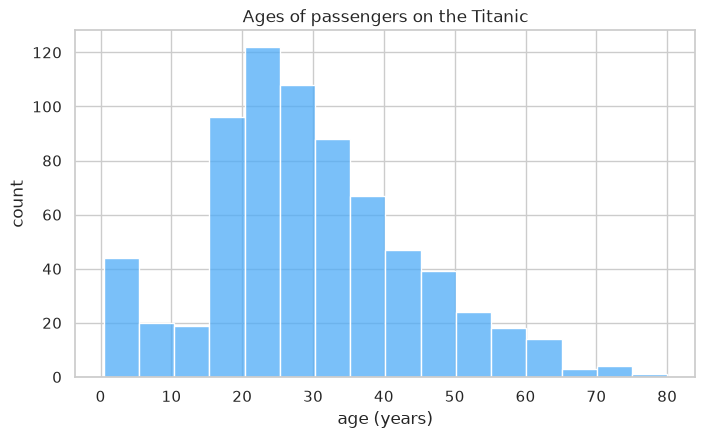

In [66]:
# Histogram of passenger ages, using bins of width 5 years (like the lecture slide)
plt.figure(figsize=(8, 4.5))
sns.histplot(data=titanic, x="age", binwidth=5, color="#4dabf7", edgecolor="white")
plt.title("Ages of passengers on the Titanic")
plt.xlabel("age (years)")
plt.ylabel("count")
plt.show()

**How to read it:** the tallest bar is around ages 20–30 → the most common age
group on board. The bars get shorter to the right → few elderly passengers.
The small bump at 0–5 shows there were quite a few young children.

The **number of bins changes the story** — too few bins hides detail, too many
makes it noisy:

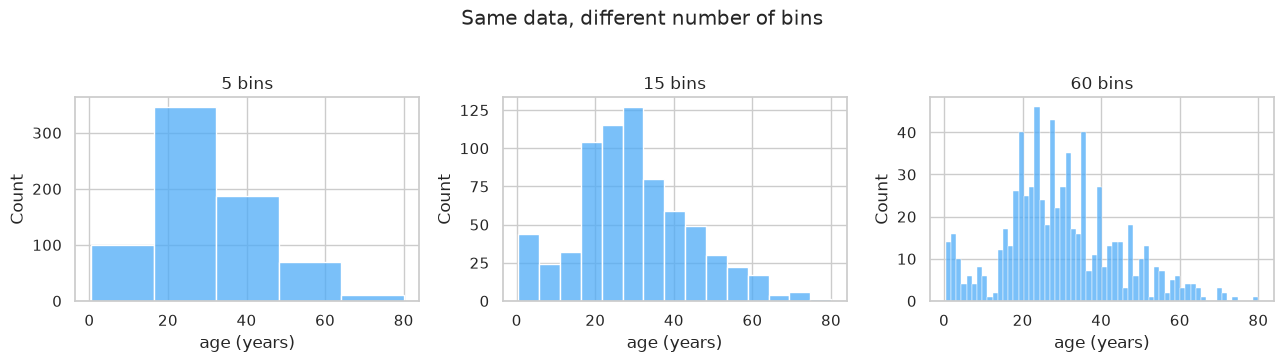

In [67]:
# The same data with 3 different bin settings — compare!
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=False)
for ax, bins in zip(axes, [5, 15, 60]):
    sns.histplot(titanic["age"].dropna(), bins=bins, ax=ax, color="#4dabf7", edgecolor="white")
    ax.set_title(f"{bins} bins")
    ax.set_xlabel("age (years)")
plt.suptitle("Same data, different number of bins", y=1.03)
plt.tight_layout()
plt.show()

> ✏️ **Try it:** plot a histogram of the `fare` column instead of `age`. What shape does it have?

### 3.2 Density plot

- A density plot visualizes the **underlying probability distribution** of the data by drawing an appropriate **continuous curve**.
- The curve is estimated with a method called **kernel density estimation (KDE)**.

Think of it as a *smooth histogram*. The y-axis becomes *density* instead of *count*
(the total area under the curve equals 1).

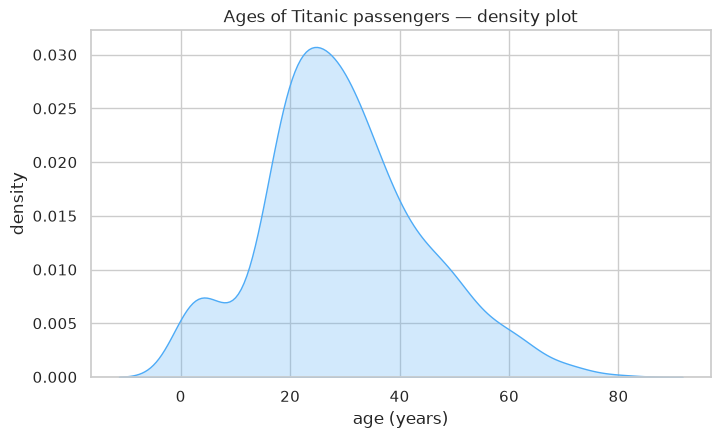

In [68]:
# Density (KDE) plot of the same Titanic ages
plt.figure(figsize=(8, 4.5))
sns.kdeplot(data=titanic, x="age", fill=True, color="#4dabf7")
plt.title("Ages of Titanic passengers — density plot")
plt.xlabel("age (years)")
plt.ylabel("density")
plt.show()

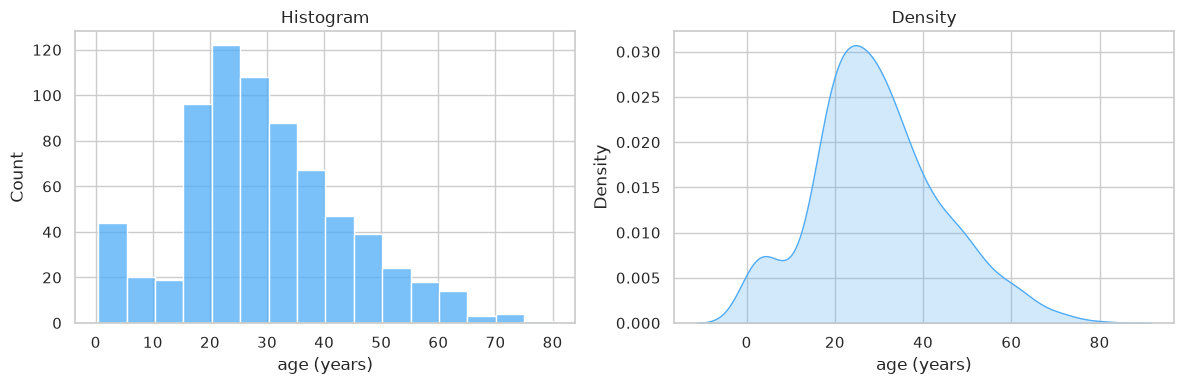

In [69]:
# Histogram and density side by side — same data, two views
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=titanic, x="age", binwidth=5, ax=axes[0], color="#4dabf7", edgecolor="white")
axes[0].set_title("Histogram")
axes[0].set_xlabel("age (years)")
sns.kdeplot(data=titanic, x="age", fill=True, ax=axes[1], color="#4dabf7")
axes[1].set_title("Density")
axes[1].set_xlabel("age (years)")
plt.tight_layout()
plt.show()

### 3.3 Boxplot

- A boxplot summarizes the distribution of **one or several numeric variables**.
- It divides the data into **quartiles** (quarters).

Anatomy of a boxplot (from bottom to top):

```
        •  ← outlier (unusually extreme value)
        |  ← maximum within the upper fence
   ┌────┐
   │    │  ← third quartile (Q3): 75% of the data is below this line
   ├────┤  ← MEDIAN: the middle value — divides the box in two
   │    │  ← first quartile (Q1): 25% of the data is below this line
   └────┘
        |  ← minimum
```

- The **box** contains the middle 50% of the data (from Q1 to Q3).
- The **whiskers** (extreme lines) show the highest and lowest values *excluding outliers*.
- Dots outside the whiskers are **outliers**.

The lecture example shows the **mean daily temperature in Lincoln, Nebraska** for
each month of the year (from Wilke, *Fundamentals of Data Visualization*, 2019).
We will simulate a very similar dataset:

In [70]:
# Simulate daily temperatures for Lincoln, NE (about 30 days per month)
rng = np.random.default_rng(42)   # a fixed "seed" so everyone gets the same data

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
typical_mean = [27, 35, 44, 50, 58, 74, 75, 72, 66, 55, 42, 29]   # °F, typical values

records = []
for month, mean_temp in zip(months, typical_mean):
    daily = rng.normal(loc=mean_temp, scale=6, size=30)   # 30 days around the mean
    for temp in daily:
        records.append({"month": month, "temperature": round(temp, 1)})

temps = pd.DataFrame(records)
temps.head()

,month,temperature
0,Jan,28.8
1,Jan,20.8
2,Jan,31.5
3,Jan,32.6
4,Jan,15.3


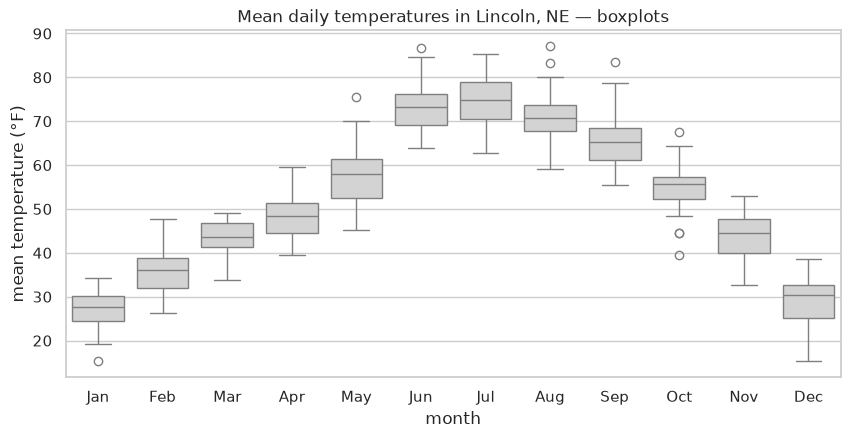

In [71]:
# One boxplot per month — 12 distributions in a single, compact picture
plt.figure(figsize=(10, 4.5))
sns.boxplot(data=temps, x="month", y="temperature", color="lightgray")
plt.title("Mean daily temperatures in Lincoln, NE — boxplots")
plt.xlabel("month")
plt.ylabel("mean temperature (°F)")
plt.show()

**How to read it:** temperatures rise from January, peak in June–August, and fall
again — you can compare the *median* (middle line), the *spread* (box height) and
spot *outliers* (dots) for every month at a glance.

> ✏️ **Try it:** make a boxplot of Titanic `age` split by passenger `class`
> (`sns.boxplot(data=titanic, x="class", y="age")`). Which class had the oldest passengers?

### 3.4 Violin plot

- A violin plot visualizes the **distribution of a numeric variable for one or several groups**.
- Violins are particularly useful when:
  - the amount of data is **huge**, and
  - showing individual observations gets impossible.

A violin is like a boxplot, but instead of a box it shows the **full shape** of the
distribution: the violin is **wide where many data points are** (maximum point
density) and **narrow where data is rare**. The top and bottom tips are the maximum
and minimum data values.

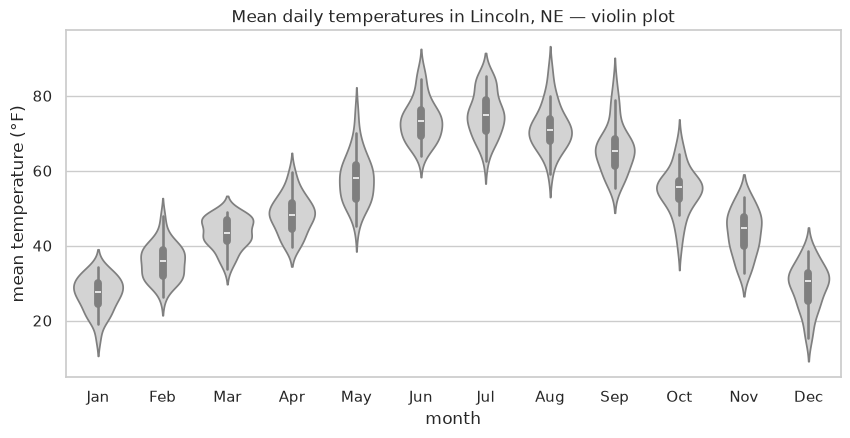

In [72]:
# Same temperature data, as violins
plt.figure(figsize=(10, 4.5))
sns.violinplot(data=temps, x="month", y="temperature", color="lightgray")
plt.title("Mean daily temperatures in Lincoln, NE — violin plot")
plt.xlabel("month")
plt.ylabel("mean temperature (°F)")
plt.show()

Compare with the boxplots above: the violins show *where* inside the range the
days concentrate — information a plain box hides.

### 3.5 Scatter plot

- A scatterplot displays the **relationship between 2 numeric variables**.
- For each data point, the value of its first variable is on the **X axis** and the second on the **Y axis**.

The lecture example: a dataset of **123 blue jay birds** with the head length
(tip of the bill to the back of the head), the skull size, and the body mass of each
bird. Birds with higher body mass are expected to have larger heads.

We will simulate this dataset so it looks just like the one in the lecture:

In [73]:
# Simulate the "123 blue jay birds" dataset from the lecture
rng = np.random.default_rng(7)
n_female, n_male = 60, 63          # 123 birds in total

def make_birds(n, sex, mass_mean, head_base):
    body_mass = rng.normal(mass_mean, 4.0, n).clip(58, 82)          # grams
    head_length = head_base + 0.17 * body_mass + rng.normal(0, 0.9, n)  # mm
    skull_size = 0.55 * head_length - 0.5 + rng.normal(0, 0.6, n)       # mm
    return pd.DataFrame({
        "sex": sex,
        "body_mass": body_mass.round(1),
        "head_length": head_length.round(1),
        "skull_size": skull_size.round(1),
    })

birds = pd.concat([
    make_birds(n_female, "female", mass_mean=69, head_base=43.0),
    make_birds(n_male,   "male",   mass_mean=73, head_base=44.2),
]).reset_index(drop=True)

print("Number of birds:", len(birds))
birds.head()

Number of birds: 123


,sex,body_mass,head_length,skull_size
0,female,69.0,54.9,29.8
1,female,70.2,54.5,29.1
2,female,67.9,54.7,29.5
3,female,65.4,53.1,27.5
4,female,67.2,53.9,28.5


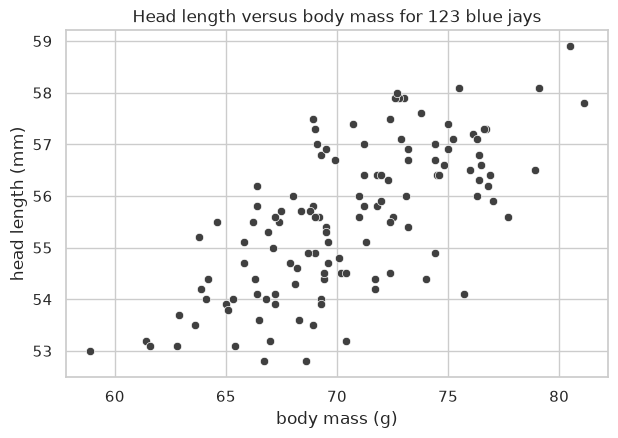

In [74]:
# Scatter plot: head length (y) against body mass (x) — each dot is one bird
plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=birds, x="body_mass", y="head_length", color="0.25")
plt.title("Head length versus body mass for 123 blue jays")
plt.xlabel("body mass (g)")
plt.ylabel("head length (mm)")
plt.show()

**How to read it:** the cloud of dots rises from bottom-left to top-right →
heavier birds tend to have longer heads. This is called a **positive relationship**
(positive correlation).

### 3.6 Line chart (and regression line)

- A line chart displays the **evolution of one or several numeric variables**. Data points are connected by straight line segments.
- It is similar to a scatter plot, except the points are **ordered** (typically by their x-axis value) and joined with line segments.

Two classic uses:

**(a) A trend over time** — e.g. average temperature per month:

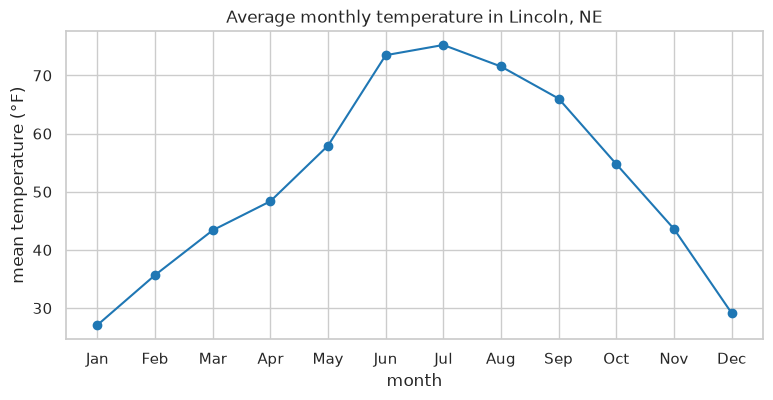

In [75]:
# Average temperature per month, as a line chart
monthly_avg = temps.groupby("month", sort=False)["temperature"].mean()

plt.figure(figsize=(9, 4))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o", color="#1f77b4")
plt.title("Average monthly temperature in Lincoln, NE")
plt.xlabel("month")
plt.ylabel("mean temperature (°F)")
plt.show()

**(b) A regression (trend) line on a scatter plot** — the lecture adds a line
through the blue jay cloud, then colors the birds by sex. At the same body mass,
**male birds tend to have longer heads** than female birds:

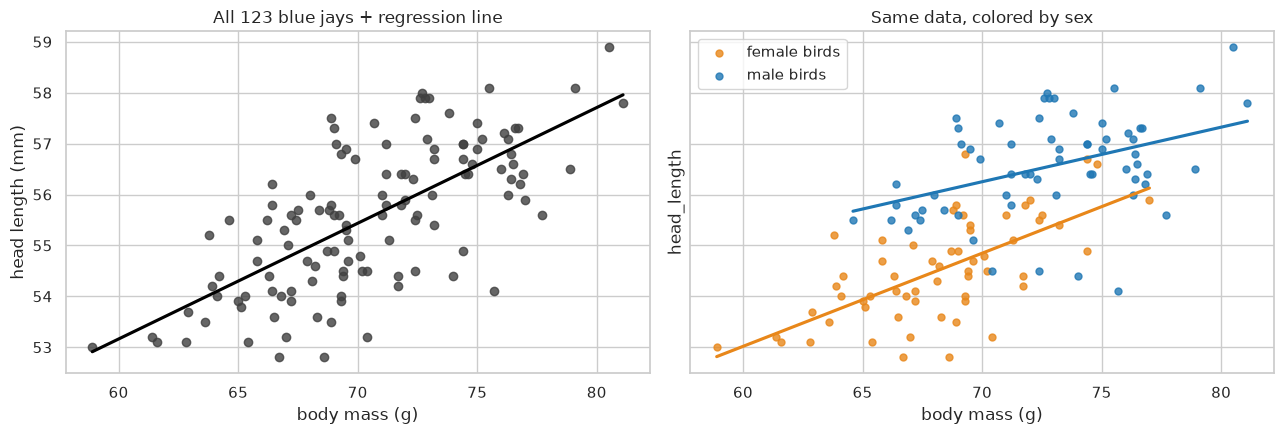

In [76]:
# Left: one regression line for all birds. Right: split by sex (color) — like the lecture
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

# (1) all birds together
sns.regplot(data=birds, x="body_mass", y="head_length", ax=axes[0],
            scatter_kws={"color": "0.25"}, line_kws={"color": "black"}, ci=None)
axes[0].set_title("All 123 blue jays + regression line")
axes[0].set_xlabel("body mass (g)")
axes[0].set_ylabel("head length (mm)")

# (2) separated by sex
for sex, color in [("female", "#e8871a"), ("male", "#1f77b4")]:
    subset = birds[birds["sex"] == sex]
    sns.regplot(data=subset, x="body_mass", y="head_length", ax=axes[1],
                scatter_kws={"color": color, "s": 25}, line_kws={"color": color},
                ci=None, label=f"{sex} birds")
axes[1].set_title("Same data, colored by sex")
axes[1].set_xlabel("body mass (g)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.7 Heatmap

- A heatmap is a graphical representation of data where the individual values contained in a **matrix** are represented as **colors**.
- It is really useful to display a **general view** of numerical data — not to extract one specific data point.

The lecture example: **averaged hourly traffic volumes over a week** (rows = days,
columns = hours, color = how heavy the traffic is).

In [77]:
# Simulate a week of traffic intensity: 7 days x 12 two-hour periods
rng = np.random.default_rng(1)
hours = ["0am", "2am", "4am", "6am", "8am", "10am", "12pm", "2pm", "4pm", "6pm", "8pm", "10pm"]
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

base_pattern = np.array([5, 3, 4, 30, 80, 55, 60, 55, 65, 85, 40, 15])  # weekday rush hours
traffic = []
for day in days:
    weekend = day in ("Sat", "Sun")
    row = base_pattern * (0.45 if weekend else 1.0) + rng.normal(0, 6, 12)
    traffic.append(row.clip(0))

traffic = pd.DataFrame(traffic, index=days, columns=hours).round(0)
traffic

,0am,2am,4am,6am,8am,10am,12pm,2pm,4pm,6pm,8pm,10pm
Mon,7.0,8.0,6.0,22.0,85.0,58.0,57.0,58.0,67.0,87.0,40.0,18.0
Tue,1.0,2.0,1.0,34.0,80.0,53.0,55.0,53.0,65.0,83.0,48.0,21.0
Wed,0.0,0.0,3.0,27.0,81.0,56.0,73.0,48.0,63.0,97.0,44.0,19.0
Thu,2.0,0.0,5.0,31.0,73.0,51.0,60.0,49.0,64.0,86.0,40.0,12.0
Fri,9.0,8.0,6.0,25.0,84.0,52.0,65.0,49.0,70.0,85.0,33.0,13.0
Sat,3.0,3.0,0.0,7.0,37.0,22.0,28.0,29.0,19.0,40.0,25.0,5.0
Sun,0.0,6.0,3.0,19.0,34.0,16.0,26.0,22.0,34.0,39.0,8.0,0.0


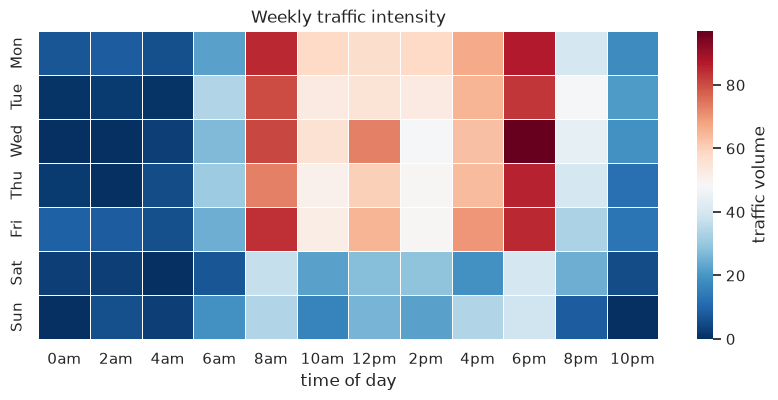

In [78]:
# The same matrix as a heatmap — patterns jump out immediately
plt.figure(figsize=(10, 4))
sns.heatmap(traffic, cmap="RdBu_r", linewidths=0.5, cbar_kws={"label": "traffic volume"})
plt.title("Weekly traffic intensity")
plt.xlabel("time of day")
plt.ylabel("")
plt.show()

**How to read it:** dark red cells = heavy traffic. You can instantly see the
morning (8am) and evening (6pm) **rush hours** on weekdays, and much lighter traffic
during the weekend. Reading the same pattern from the table of numbers above takes
far longer — that is the power of a heatmap!

### 3.8 Bubble plot

A bubble plot is a scatterplot where a **third dimension** is added: the value of an
additional numeric variable is represented through the **size of the dots**.

The lecture example: blue jays again — x = body mass, y = head length, color = sex,
and **dot size = skull size**.

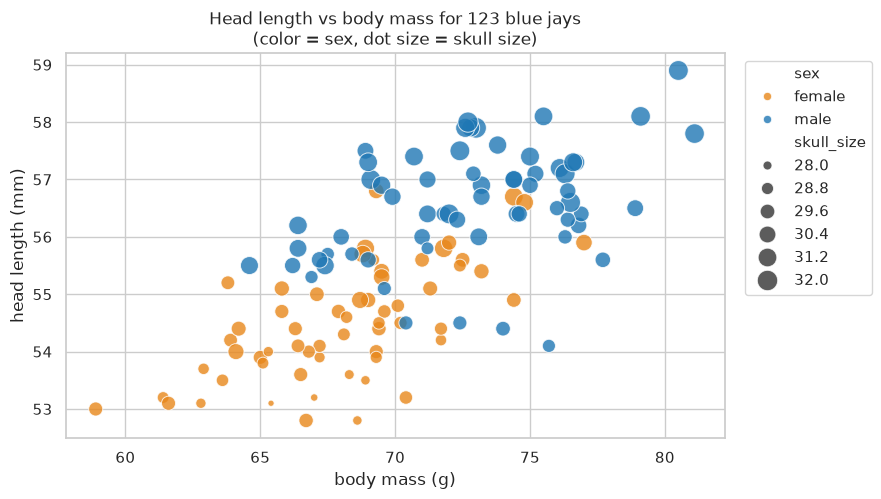

In [79]:
# Bubble plot: dot size shows the skull size (3rd numeric variable)
plt.figure(figsize=(8.5, 5))
sns.scatterplot(data=birds, x="body_mass", y="head_length",
                hue="sex", size="skull_size", sizes=(20, 220),
                palette={"female": "#e8871a", "male": "#1f77b4"}, alpha=0.8)
plt.title("Head length vs body mass for 123 blue jays\n(color = sex, dot size = skull size)")
plt.xlabel("body mass (g)")
plt.ylabel("head length (mm)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

One picture now shows **four** pieces of information about every bird:
body mass (x), head length (y), sex (color), and skull size (dot size).

### 3.9 Correlogram (correlation matrix)

- A correlogram or **correlation matrix** analyzes the relationship between **each pair** of numeric variables in a dataset.
- The correlation between each pair is visualized through a scatterplot, or a symbol/color that represents the correlation.

**Correlation** is a number between −1 and +1:

- **+1** → perfect positive relationship (both grow together)
- **0** → no relationship
- **−1** → perfect negative relationship (one grows, the other shrinks)

In [80]:
# Correlation between every pair of numeric variables of the blue jay data
corr = birds[["body_mass", "head_length", "skull_size"]].corr()
corr.round(2)

,body_mass,head_length,skull_size
body_mass,1.00,0.69,0.52
head_length,0.69,1.00,0.84
skull_size,0.52,0.84,1.00


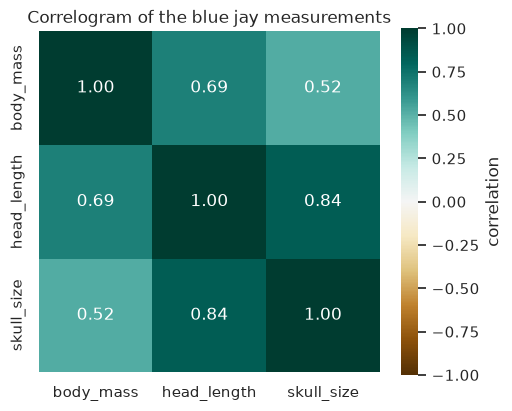

In [81]:
# The correlation matrix as a colored heatmap = a correlogram
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="BrBG", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "correlation"})
plt.title("Correlogram of the blue jay measurements")
plt.show()

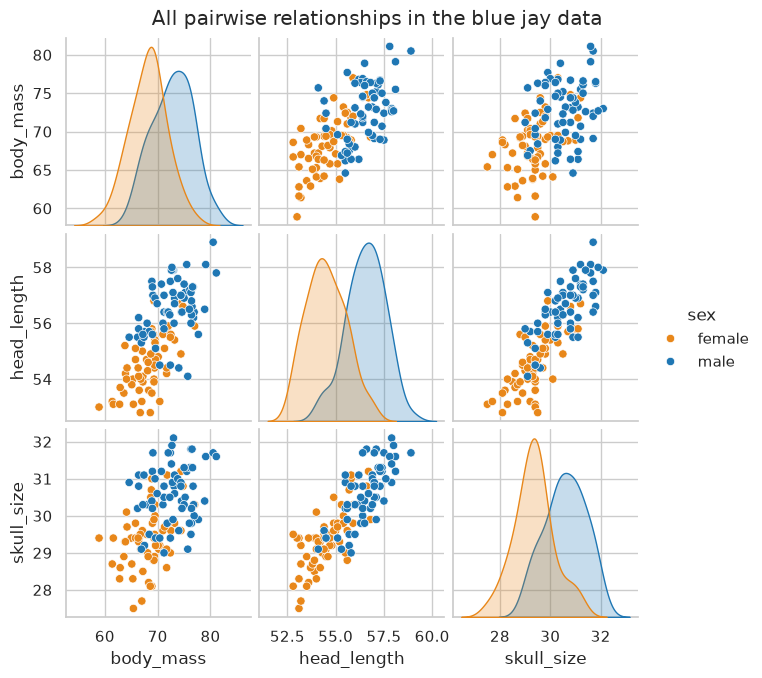

In [82]:
# Bonus: a "pairplot" draws the scatterplot of every pair + histograms on the diagonal
sns.pairplot(birds, vars=["body_mass", "head_length", "skull_size"], hue="sex",
             palette={"female": "#e8871a", "male": "#1f77b4"}, height=2.2)
plt.suptitle("All pairwise relationships in the blue jay data", y=1.02)
plt.show()

## 4. Visualization for categorical data

For **categorical** variables (labels/groups) the lecture introduced:

| Chart | Best for |
|---|---|
| **Bar plot** | Compare a numeric value across categories |
| **Clustered (grouped) bar plot** | Compare values of *multiple* variables at once |
| **Stacked bar plot** | How a larger category divides into smaller ones |
| **100% stacked bar plot** | The *percentage* share within each group |
| **Pie chart** | Proportions of a whole (sectors sum to 100%) |
| **Treemap** | Hierarchical data as nested rectangles |

### 4.1 Bar plot

- Each entity of the **categorical variable** is represented as a **bar**.
- The **size of the bar** represents its numeric value.

The lecture example: **highest grossing movies for the weekend of December 22–24,
2017** (data source: Box Office Mojo).

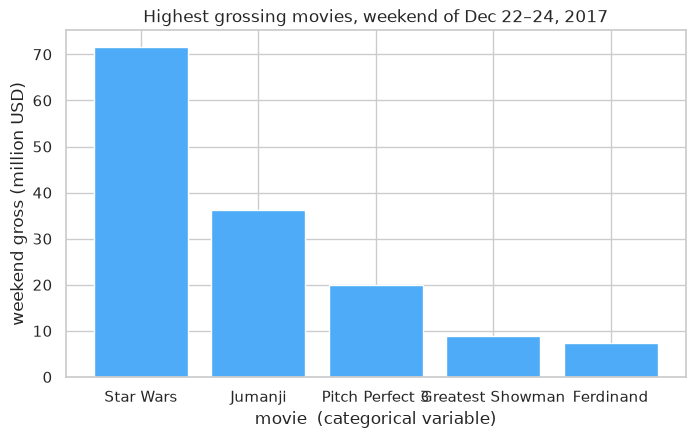

In [83]:
# The movie data from the lecture slide
movies = pd.DataFrame({
    "movie": ["Star Wars", "Jumanji", "Pitch Perfect 3", "Greatest Showman", "Ferdinand"],
    "weekend_gross": [71.6, 36.2, 19.9, 8.8, 7.3],   # million USD
})

plt.figure(figsize=(8, 4.5))
plt.bar(movies["movie"], movies["weekend_gross"], color="#4dabf7", edgecolor="white")
plt.title("Highest grossing movies, weekend of Dec 22–24, 2017")
plt.xlabel("movie  (categorical variable)")
plt.ylabel("weekend gross (million USD)")
plt.show()

> ⚠️ **Histogram vs bar plot — don't confuse them!**
> A *histogram* shows the distribution of **one numeric** variable cut into bins.
> A *bar plot* compares a numeric value across **categories**. They look similar but answer different questions.

> ✏️ **Try it:** turn it into a *horizontal* bar chart with `plt.barh(...)` — often easier to read when category names are long.

### 4.2 Clustered (grouped) bar plot

A **grouped bar plot** uses bars grouped together to visualise the values of
**multiple variables at once** — e.g. one group of bars per category, one bar per
sub-category.

The lecture's second bar example uses the Titanic again: the number of **female and
male passengers traveling in 1st, 2nd, and 3rd class**. These are the exact numbers
from the slide:

In [84]:
# Titanic passengers by class and sex (numbers from the lecture slide)
passengers = pd.DataFrame(
    {"female": [143, 107, 212],
     "male":   [179, 172, 499]},
    index=["1st class", "2nd class", "3rd class"],
)
passengers

,female,male
1st class,143,179
2nd class,107,172
3rd class,212,499


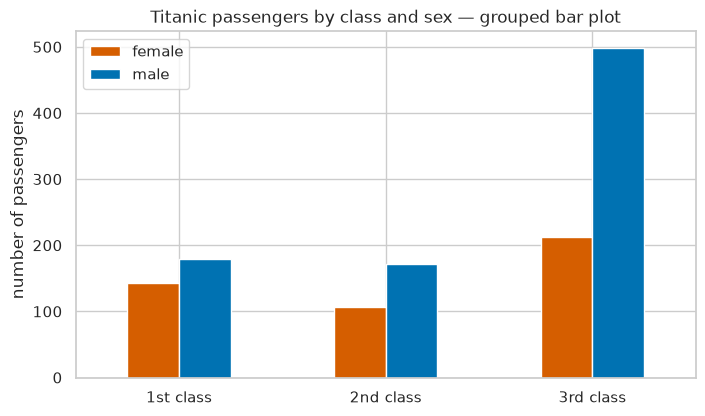

In [85]:
# Grouped bar plot: for every class, two bars side by side (female / male)
passengers.plot(kind="bar", figsize=(8, 4.5),
                color={"female": "#d55e00", "male": "#0072b2"}, edgecolor="white")
plt.title("Titanic passengers by class and sex — grouped bar plot")
plt.xlabel("")
plt.ylabel("number of passengers")
plt.xticks(rotation=0)
plt.legend(title="")
plt.show()

### 4.3 Stacked bar plot

**Stacked bar graphs** are used to show how a **larger category is divided into
smaller categories**, and what relationship each part has to the **total amount**.

Same Titanic data — but now the female and male bars are stacked on top of each
other, so the *total height* = all passengers in that class:

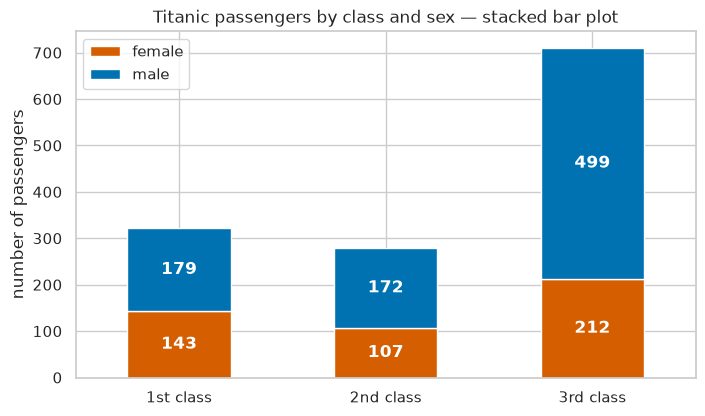

In [86]:
# Stacked bar plot: total bar height = all passengers of the class
ax = passengers.plot(kind="bar", stacked=True, figsize=(8, 4.5),
                     color={"female": "#d55e00", "male": "#0072b2"}, edgecolor="white")
plt.title("Titanic passengers by class and sex — stacked bar plot")
plt.ylabel("number of passengers")
plt.xticks(rotation=0)
plt.legend(title="")

# write the number inside each block (nice touch, exactly like the slide)
for container in ax.containers:
    ax.bar_label(container, label_type="center", color="white", fontweight="bold")
plt.show()

**How to read it:** 3rd class was by far the biggest group (mostly male
passengers), while 1st and 2nd class were smaller and more balanced.

### 4.4 100% stacked bar plot

**100% stack bar graphs** show the **percentage-of-the-whole** of each group: every
bar is stretched to 100%, and the blocks show each value as a *percentage of the
group total*.

Use it when you care about **proportions**, not absolute counts:

In [87]:
# Convert counts to percentages within each class (each row sums to 100)
percentages = passengers.div(passengers.sum(axis=1), axis=0) * 100
percentages.round(0)

,female,male
1st class,44.0,56.0
2nd class,38.0,62.0
3rd class,30.0,70.0


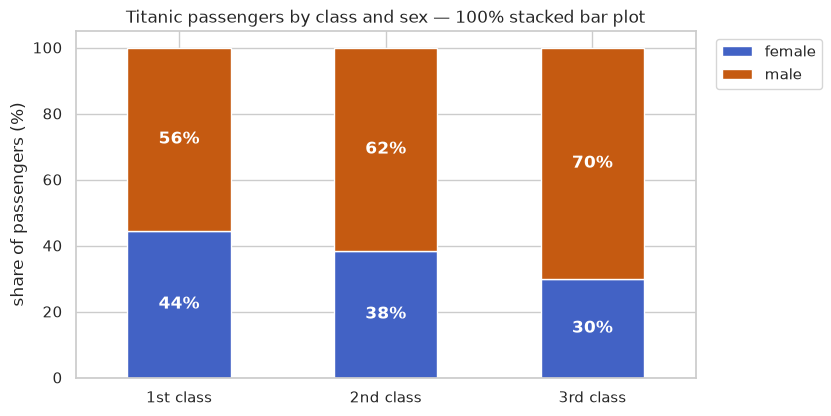

In [88]:
# 100% stacked bar plot
ax = percentages.plot(kind="bar", stacked=True, figsize=(8, 4.5),
                      color={"female": "#4262c5", "male": "#c55a11"}, edgecolor="white")
plt.title("Titanic passengers by class and sex — 100% stacked bar plot")
plt.ylabel("share of passengers (%)")
plt.xticks(rotation=0)
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", label_type="center", color="white", fontweight="bold")
plt.show()

**Compare 4.3 and 4.4:** the stacked plot shows 3rd class was the *largest*;
the 100% version reveals it was also the *most male-dominated* (70% male vs 56% in
1st class). Different chart → different insight from the same data!

### 4.5 Pie chart

- A pie chart is a **circle divided into sectors** that each represent a **proportion of the whole**.
- It is often used to show proportion, where the sum of the sectors equals **100%**.

The lecture example: from 1961 to 1983 the German parliament (the *Bundestag*) was
composed of three parties. In the 8th Bundestag (1976–1980) **CDU/CSU held 243
seats, SPD 214, and FDP 39** — a total of 496:

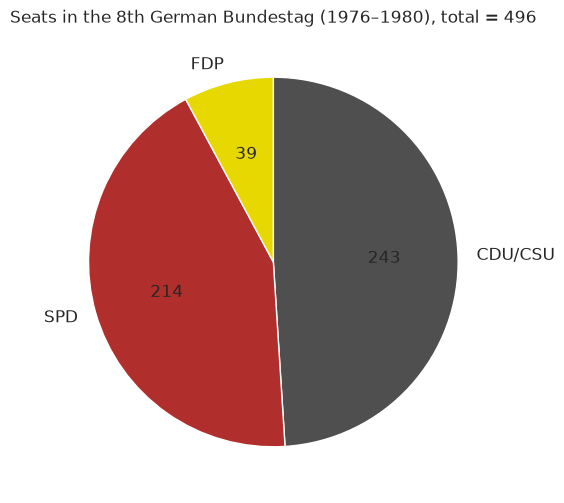

In [89]:
# Seats in the 8th German Bundestag (1976-1980)
parties = ["CDU/CSU", "SPD", "FDP"]
seats = [243, 214, 39]
colors = ["#4f4f4f", "#b02f2c", "#e6d800"]

plt.figure(figsize=(6, 6))
plt.pie(seats, labels=parties, colors=colors, startangle=90, counterclock=False,
        autopct=lambda pct: f"{round(pct / 100 * sum(seats))}",   # show seat counts
        textprops={"fontsize": 12}, wedgeprops={"edgecolor": "white"})
plt.title("Seats in the 8th German Bundestag (1976–1980), total = 496")
plt.show()

> 💡 **Tip:** pie charts work best with **few categories** (2–4). With many
> slices, humans struggle to compare angles — a bar plot is usually the safer choice.

### 4.6 Treemap

- A treemap displays **hierarchical data** as a set of **nested rectangles**.
- Each group is a rectangle whose **area is proportional to its value**. With color schemes you can represent several dimensions: groups, subgroups, etc.

The lecture example: the **bridges of Pittsburgh** broken down by construction
material (steel, wood, iron) and era of construction (crafts, emerging, mature,
modern). We need one extra small library: `squarify`
(install once with `pip install squarify`).

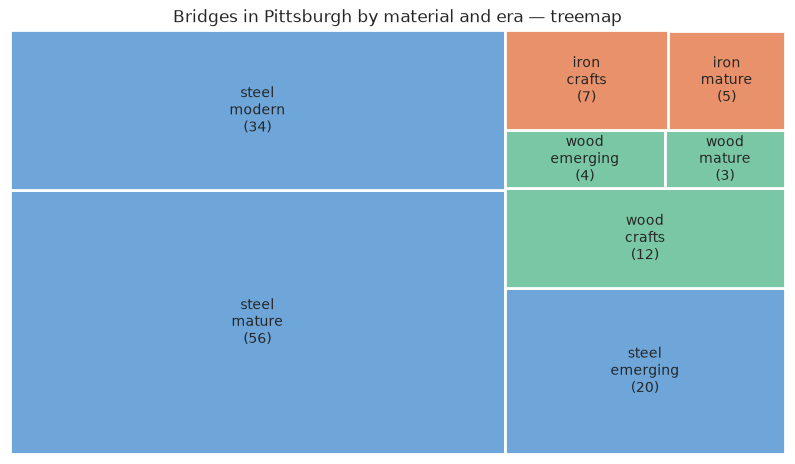

In [90]:
# Treemap of Pittsburgh bridges by material and era (counts approximated from the lecture)
import squarify   # pip install squarify

bridges = pd.DataFrame({
    "material": ["steel", "steel", "steel", "wood", "wood", "wood", "iron", "iron"],
    "era":      ["mature", "modern", "emerging", "crafts", "emerging", "mature", "crafts", "mature"],
    "count":    [56, 34, 20, 12, 4, 3, 7, 5],
})

material_color = {"steel": "#6ea6d9", "wood": "#79c7a4", "iron": "#e8916a"}

plt.figure(figsize=(10, 5.5))
squarify.plot(
    sizes=bridges["count"],
    label=[f"{m}\n{e}\n({c})" for m, e, c in zip(bridges["material"], bridges["era"], bridges["count"])],
    color=[material_color[m] for m in bridges["material"]],
    edgecolor="white", linewidth=2, text_kwargs={"fontsize": 10},
)
plt.title("Bridges in Pittsburgh by material and era — treemap")
plt.axis("off")
plt.show()

**How to read it:** the biggest rectangle = steel/mature bridges — steel
(blue) clearly dominates. Area = number of bridges, color = material.

## 5. Map and network

The last family of visualizations in the lecture places data on **geography** or
shows **connections** between entities.

### 5.1 Choropleth map

- A choropleth map displays **divided geographical areas or regions colored in relation to a numeric variable**.
- It shows how a variable evolves **along a territory**.
- Lecture example: the map of **COVID-19 cases by province in Thailand** (darker red = more cases).

### 5.2 Bubble map

- A bubble map uses **circles of different size** to represent a numeric value on a territory.
- Lecture example: **COVID-19 cases by county in the USA** — one bubble per county, bigger bubble = more cases.

Interactive maps are easiest with the **plotly** library (`pip install plotly`).
Here is a complete choropleth example you can try (it opens an interactive world map):

```python
import plotly.express as px

# Life expectancy per country in 2007 (a classic built-in dataset)
gapminder = px.data.gapminder().query("year == 2007")

fig = px.choropleth(gapminder, locations="iso_alpha", color="lifeExp",
                    hover_name="country", color_continuous_scale="Reds",
                    title="Life expectancy by country (2007) — choropleth map")
fig.show()
```

And a bubble map — same data, bubbles sized by population:

```python
fig = px.scatter_geo(gapminder, locations="iso_alpha", size="pop",
                     hover_name="country", color="continent",
                     title="Population by country (2007) — bubble map")
fig.show()
```

### 5.3 Network diagram

- Network diagrams (aka **graphs**) show **interconnections between a set of entities**.
- Each entity is a **node** (or *vertex*).
- Connections between nodes are represented by **links** (or *edges*).
- Lecture example: the global network of countries doing research on the Chikungunya vaccine — node size = importance (degree centrality), link thickness = collaboration intensity.

Let's draw a small version of that co-authorship network with the `networkx` library:

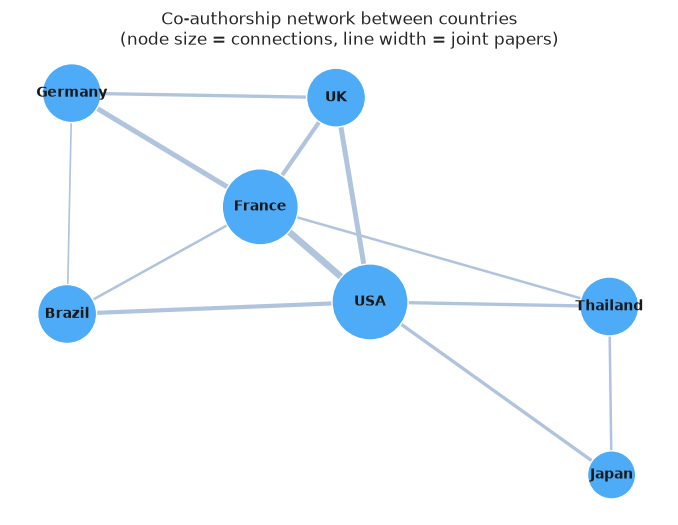

In [91]:
# A mini co-authorship network (which countries publish papers together?)
import networkx as nx   # pip install networkx

G = nx.Graph()
collaborations = [           # (country A, country B, number of joint papers)
    ("USA", "France", 8), ("USA", "UK", 6), ("USA", "Thailand", 4),
    ("USA", "Brazil", 5), ("France", "UK", 5), ("France", "Germany", 6),
    ("France", "Thailand", 3), ("UK", "Germany", 4), ("Germany", "Brazil", 2),
    ("Thailand", "Japan", 3), ("Japan", "USA", 4), ("Brazil", "France", 3),
]
for a, b, weight in collaborations:
    G.add_edge(a, b, weight=weight)

# node size = number of connections (degree), edge width = collaboration strength
node_sizes = [600 * G.degree(node) for node in G.nodes]
edge_widths = [G[a][b]["weight"] * 0.6 for a, b in G.edges]

plt.figure(figsize=(8.5, 6))
pos = nx.spring_layout(G, seed=5)                     # automatic layout
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color="lightsteelblue")
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#4dabf7", edgecolors="white")
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
plt.title("Co-authorship network between countries\n(node size = connections, line width = joint papers)")
plt.axis("off")
plt.show()

**How to read it:** the USA and France have the biggest nodes → they
collaborate with the most countries. Thick lines = strong collaborations.

### 5.4 A runnable bubble map — and the mistake choropleths invite

The plotly examples above need an extra library and an internet connection. A bubble map is simple enough to
build from a plain scatter plot, using longitude as x and latitude as y — which is worth doing once, because
it makes clear that a map is just a scatter plot with meaningful axes.

In [92]:
# Approximate coordinates and populations for a handful of Thai provinces.
provinces = pd.DataFrame([
    ("Bangkok",      100.50, 13.75, 5_500_000, 4_180),
    ("Chiang Mai",    98.99, 18.79, 1_780_000,   712),
    ("Chiang Rai",    99.83, 19.91, 1_290_000,   309),
    ("Khon Kaen",    102.83, 16.44, 1_790_000,   358),
    ("Phuket",        98.39,  7.88,   420_000,   378),
    ("Songkhla",     100.60,  7.20, 1_430_000,   315),
    ("Nakhon Ratchasima", 102.10, 14.97, 2_630_000, 447),
    ("Ubon Ratchathani",  104.86, 15.24, 1_870_000, 243),
], columns=["province", "lon", "lat", "population", "cases"])

provinces["cases_per_100k"] = (provinces["cases"] / provinces["population"] * 100_000).round(1)
provinces.sort_values("cases", ascending=False)

,province,lon,lat,population,cases,cases_per_100k
0,Bangkok,100.50,13.75,5500000,4180,76.0
1,Chiang Mai,98.99,18.79,1780000,712,40.0
6,Nakhon Ratchasima,102.10,14.97,2630000,447,17.0
4,Phuket,98.39,7.88,420000,378,90.0
3,Khon Kaen,102.83,16.44,1790000,358,20.0
5,Songkhla,100.60,7.20,1430000,315,22.0
2,Chiang Rai,99.83,19.91,1290000,309,24.0
7,Ubon Ratchathani,104.86,15.24,1870000,243,13.0


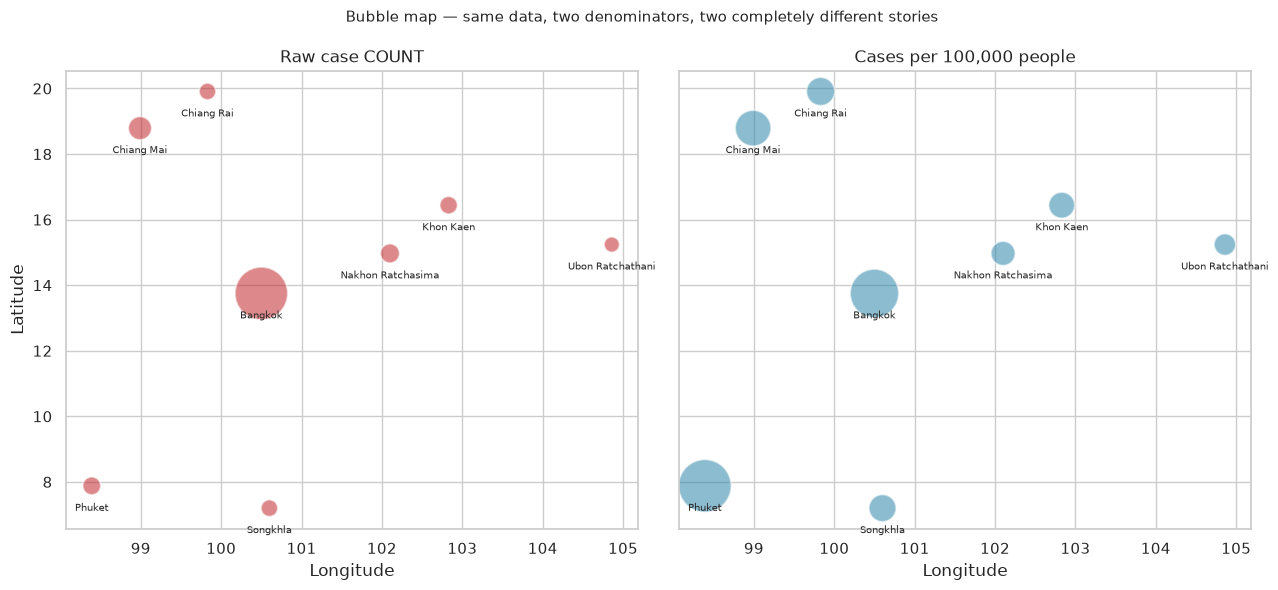

Ranked by raw count : Bangkok > Chiang Mai > Nakhon Ratchasima > Phuket
Ranked by rate      : Phuket > Bangkok > Chiang Mai > Chiang Rai


In [93]:
fig, (ax_count, ax_rate) = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)

for ax, column, title, color in [
    (ax_count, "cases", "Raw case COUNT", "#C1292E"),
    (ax_rate, "cases_per_100k", "Cases per 100,000 people", "#2E86AB"),
]:
    sizes = provinces[column] / provinces[column].max() * 1400 + 40
    ax.scatter(provinces["lon"], provinces["lat"], s=sizes, color=color, alpha=0.55,
               edgecolor="white", linewidth=1.2)
    for _, row in provinces.iterrows():
        ax.annotate(row["province"], (row["lon"], row["lat"]), fontsize=7.5,
                    textcoords="offset points", xytext=(0, -18), ha="center")
    ax.set_xlabel("Longitude")
    ax.set_title(title)
ax_count.set_ylabel("Latitude")
fig.suptitle("Bubble map — same data, two denominators, two completely different stories", fontsize=11)
plt.tight_layout()
plt.show()

print("Ranked by raw count :", " > ".join(provinces.sort_values("cases", ascending=False)["province"][:4]))
print("Ranked by rate      :", " > ".join(provinces.sort_values("cases_per_100k", ascending=False)["province"][:4]))

**How to read it:** by raw count Bangkok dominates the map, which is almost entirely a statement about how
many people live there. By rate, the ranking reorders substantially — Phuket rises sharply because its case
count is large *relative to a small population*.

**This is the standard trap with choropleths and bubble maps alike.** A map colored or sized by a raw count
mostly shows you where the people are, or how large the region is. It is a population map wearing the costume
of an outbreak map.

> **Normalize by population or area before mapping a count.** If you genuinely need to show totals — for
> resource planning, say — label the map clearly as counts, and pair it with the rate version.

**Choropleth vs. bubble map**, since the lecture contrasts them:

| | Choropleth | Bubble map |
|---|---|---|
| Encodes value as | Color of a region | Size of a circle |
| Bound by | Region borders (provinces, states) | Nothing — works at any point |
| Needs | Boundary geometry for every region | Just a latitude and longitude |
| Distorts by | Region area — big empty provinces shout | Overlap in dense areas |
| Best for | Rates across administrative units | Values at exact cities or coordinates |

Both encode value with a rank-5 or rank-7 channel from Section 2.1, so **neither is good for reading precise
values** — they are for seeing spatial pattern. Pair a map with a sorted bar chart when the numbers matter.

## 6. Summary — how to choose the right chart

Ask yourself two questions: **what type of data do I have**, and **what do I want to show**?

| I want to show… | Data type | Use |
|---|---|---|
| The distribution of one numeric variable | numerical | **Histogram** / **Density** |
| Compare distributions across groups | numerical + categorical | **Boxplot** / **Violin** |
| A trend over time | numerical (ordered) | **Line chart** |
| The relationship between 2 numeric variables | numerical | **Scatter plot** |
| … with a 3rd numeric variable | numerical | **Bubble plot** |
| A whole matrix of values at a glance | numerical | **Heatmap** |
| Relationships between all pairs of variables | numerical | **Correlogram** |
| Compare a value across categories | categorical | **Bar plot** |
| Compare sub-groups inside categories | categorical | **Grouped / Stacked bar** |
| Proportions (%) inside each group | categorical | **100% stacked bar** |
| Parts of a whole (few categories) | categorical | **Pie chart** |
| Hierarchical parts of a whole | categorical | **Treemap** |
| A value across geographic regions | geo + numerical | **Choropleth / Bubble map** |
| Connections between entities | relational | **Network diagram** |

**Golden rules** (always!):

1. Give every chart a **title**.
2. Label the **x and y axes** (with units!).
3. Add a **legend** whenever you use colors or sizes for groups.
4. Choose the chart that matches your **data type** and your **question**.

---
## 7. How the same data can tell three different stories

A chart is an argument. The same numbers, drawn differently, can support opposite conclusions — usually
without a single false value anywhere. Recognizing these moves protects you from making them by accident, and
from being persuaded by someone who made them on purpose.

### 7.1 The truncated y-axis

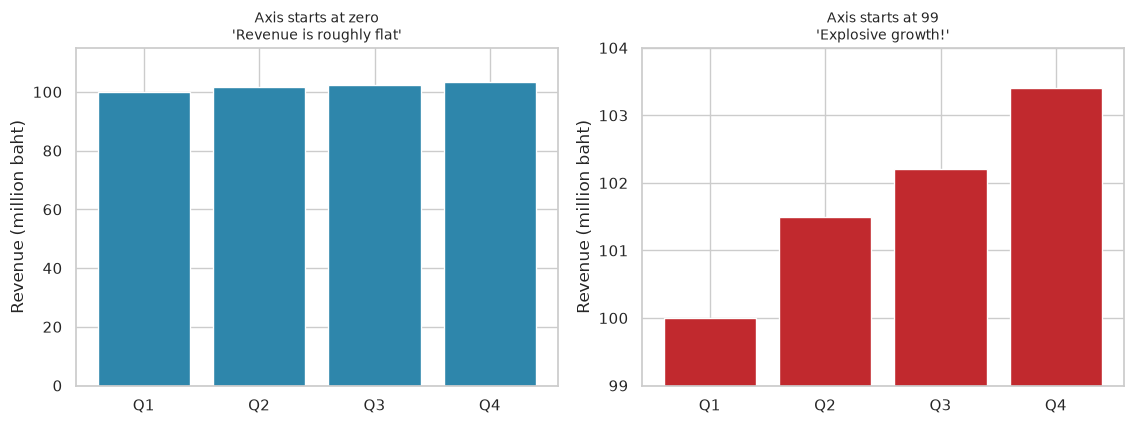

Actual change from Q1 to Q4: +3.4%
Apparent bar-height change on the left : 3.0% of the axis
Apparent bar-height change on the right: 68% of the axis


In [94]:
quarters = ["Q1", "Q2", "Q3", "Q4"]
revenue = np.array([100.0, 101.5, 102.2, 103.4])     # a 3.4% rise over the year

fig, (ax_honest, ax_truncated) = plt.subplots(1, 2, figsize=(11.5, 4.4))

ax_honest.bar(quarters, revenue, color="#2E86AB")
ax_honest.set_ylim(0, 115)
ax_honest.set_ylabel("Revenue (million baht)")
ax_honest.set_title("Axis starts at zero\n'Revenue is roughly flat'", fontsize=10)

ax_truncated.bar(quarters, revenue, color="#C1292E")
ax_truncated.set_ylim(99, 104)
ax_truncated.set_ylabel("Revenue (million baht)")
ax_truncated.set_title("Axis starts at 99\n'Explosive growth!'", fontsize=10)

plt.tight_layout()
plt.show()

print(f"Actual change from Q1 to Q4: {(revenue[-1]/revenue[0]-1)*100:+.1f}%")
print(f"Apparent bar-height change on the left : {(revenue[-1]-revenue[0])/115*100:.1f}% of the axis")
print(f"Apparent bar-height change on the right: {(revenue[-1]-revenue[0])/(104-99)*100:.0f}% of the axis")

**How to read it:** both charts plot the same four numbers. The right-hand one turns a 3.4% rise into bars
that differ by most of the plot height.

The rule is not "always start at zero" — that would make many line charts useless, and temperature or stock
prices have no meaningful zero. The rule follows from Section 2.1:

> **Bars encode value by length, so a bar chart's axis must start at zero.** Lines and dots encode by
> position, so they may be truncated — but say so clearly.

### 7.2 Dual axes

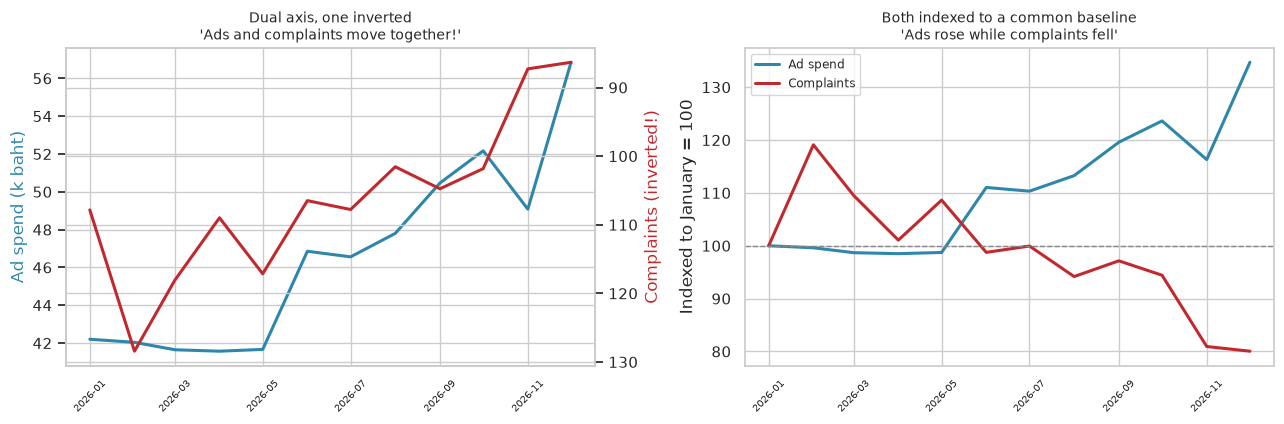

Correlation between ad spend and complaints: -0.80  (they move in OPPOSITE directions)


In [95]:
months = pd.date_range("2026-01-01", periods=12, freq="MS")
rng_dual = np.random.default_rng(17)
ad_spend = np.linspace(40, 55, 12) + rng_dual.normal(0, 2, 12)
complaints = np.linspace(120, 90, 12) + rng_dual.normal(0, 6, 12)   # actually FALLING

fig, (ax_dual, ax_pair) = plt.subplots(1, 2, figsize=(13, 4.4))

ax_left = ax_dual
ax_right = ax_left.twinx()
ax_left.plot(months, ad_spend, color="#2E86AB", linewidth=2.2, label="Ad spend")
ax_right.plot(months, complaints, color="#C1292E", linewidth=2.2, label="Complaints")
ax_right.invert_yaxis()                       # the trick: quietly flip one axis
ax_left.set_ylabel("Ad spend (k baht)", color="#2E86AB")
ax_right.set_ylabel("Complaints (inverted!)", color="#C1292E")
ax_dual.set_title("Dual axis, one inverted\n'Ads and complaints move together!'", fontsize=10)
ax_dual.tick_params(axis="x", rotation=45, labelsize=7)

ax_pair.plot(months, ad_spend / ad_spend[0] * 100, color="#2E86AB", linewidth=2.2, label="Ad spend")
ax_pair.plot(months, complaints / complaints[0] * 100, color="#C1292E", linewidth=2.2, label="Complaints")
ax_pair.axhline(100, color="#888", linestyle="--", linewidth=1)
ax_pair.set_ylabel("Indexed to January = 100")
ax_pair.set_title("Both indexed to a common baseline\n'Ads rose while complaints fell'", fontsize=10)
ax_pair.tick_params(axis="x", rotation=45, labelsize=7)
ax_pair.legend(fontsize=8.5)

plt.tight_layout()
plt.show()

print(f"Correlation between ad spend and complaints: "
      f"{np.corrcoef(ad_spend, complaints)[0,1]:+.2f}  (they move in OPPOSITE directions)")

**How to read it:** the left chart makes two series that move in opposite directions appear to move together,
using nothing but two independent y-axes and one quiet `invert_yaxis()`. Both scales are labeled; nothing is
factually false.

**Dual axes let the author choose the apparent relationship**, because the two scales can be slid and
stretched independently until the lines do whatever is wanted. The honest alternatives are on the right:
index both series to a common baseline, or draw two stacked panels sharing an x-axis.

### 7.3 Color that helps rather than decorates

In [96]:
gradient = np.linspace(0, 1, 256).reshape(1, -1)

palettes = [
    ("viridis",  "Sequential — low to high, one direction"),
    ("Blues",    "Sequential — the same idea, single hue"),
    ("RdBu_r",   "Diverging — meaningful midpoint (e.g. zero)"),
    ("tab10",    "Qualitative — unordered categories"),
    ("jet",      "Rainbow — AVOID: invents bands that are not in the data"),
]

fig, axes = plt.subplots(len(palettes), 1, figsize=(10, 5.2))
for ax, (name, description) in zip(axes, palettes):
    ax.imshow(gradient, aspect="auto", cmap=name)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylabel(name, rotation=0, ha="right", va="center", fontsize=9, fontweight="bold")
    ax.text(260, 0, description, va="center", fontsize=8.5, transform=ax.get_yaxis_transform())
    ax.grid(False)
fig.suptitle("Choose the colormap family that matches the data", fontsize=11)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1867996/4075317459.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


**How to read it:** look at the `jet` strip and notice the sharp bands — a distinct cyan stripe, a distinct
yellow stripe. Those boundaries are artifacts of the colormap, not features of the data, and on a heatmap they
appear as contours that do not exist. `viridis` and `Blues` change smoothly and monotonically in perceived
lightness, so equal steps in value look like equal steps in color.

| Data | Colormap family | Examples |
|---|---|---|
| Runs low → high | **Sequential** | `viridis`, `Blues`, `Reds` |
| Has a meaningful midpoint (zero, a target, an average) | **Diverging** | `RdBu`, `coolwarm`, `PiYG` |
| Unordered categories | **Qualitative** | `tab10`, `Set2` |
| Anything | **Never rainbow** | avoid `jet`, `rainbow` |

⚠️ **Colorblindness.** Roughly 8% of men have some form of red–green color vision deficiency, so a red-versus-
green encoding is unreadable for a substantial part of any audience. `viridis` was designed to survive it.
When color carries essential meaning, back it up with a second channel — direct labels, different markers, or
position — so the chart still works in grayscale.

### 7.4 Small multiples beat one crowded chart

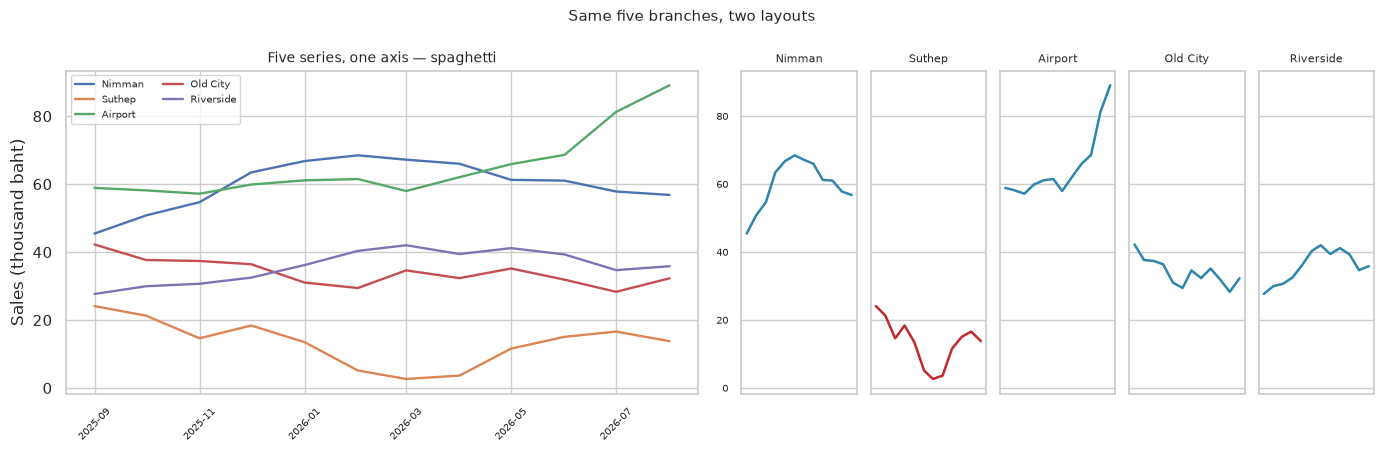

In [97]:
fig = plt.figure(figsize=(14, 4.6))

# One crowded chart.
ax_all = fig.add_subplot(1, 2, 1)
for column in data.columns:
    ax_all.plot(data.index, data[column], linewidth=1.7, label=column)
ax_all.legend(fontsize=7, ncol=2)
ax_all.set_title("Five series, one axis — spaghetti", fontsize=10)
ax_all.set_ylabel("Sales (thousand baht)")
ax_all.tick_params(axis="x", rotation=45, labelsize=7)

# The same data as small multiples, sharing one scale.
inner = fig.add_gridspec(1, 2)[1].subgridspec(1, len(data.columns), wspace=0.12)
shared = None
for i, column in enumerate(data.columns):
    ax = fig.add_subplot(inner[0, i], sharey=shared)
    shared = shared or ax
    ax.plot(data.index, data[column], color="#CCCCCC", linewidth=1)
    ax.plot(data.index, data[column],
            color="#C1292E" if column == "Suthep" else "#2E86AB", linewidth=1.8)
    ax.set_title(column, fontsize=8)
    ax.set_xticks([])
    if i:
        ax.tick_params(labelleft=False)
    ax.tick_params(labelsize=7)

fig.suptitle("Same five branches, two layouts", fontsize=11)
plt.tight_layout()
plt.show()

**How to read it:** the left panel needs a legend and constant back-and-forth between line and label. The
right panel gives each branch its own panel on a **shared y-axis**, so shapes are directly comparable and
Suthep's decline is visible instantly.

This is Section 2.1's rank 2 — *position along identical, non-aligned scales* — and it beats the color-matching
that the left panel demands. Small multiples scale gracefully to dozens of panels, where a single axis becomes
unreadable past about five series.

**The shared scale is essential.** If each panel got its own y-range, every branch would look similarly
shaped and the comparison would be meaningless.

---
## 8. Glossary — Part II

| Term | Meaning |
|---|---|
| **Record / explore / explain** | The three jobs a chart can do; each wants a different design |
| **Cleveland–McGill ranking** | Position beats length beats angle beats area beats color, for accuracy |
| **Histogram** | Distribution of one numeric variable, using bins |
| **Bin width** | The chosen grouping interval; it can hide or invent structure |
| **Density / KDE** | A smoothed estimate of a distribution, with no bin edges |
| **Boxplot** | Median, quartiles, whiskers, and outliers — the IQR rule, drawn |
| **Violin plot** | A boxplot's summary plus the full distribution shape |
| **Scatter plot** | Two numeric variables, one dot per observation |
| **Line chart** | A scatter plot whose x-axis has a natural order, with points joined |
| **Heatmap** | A numeric matrix drawn as colored tiles |
| **Bubble plot** | A scatter plot with a third variable encoded as dot area |
| **Correlogram** | The correlation of every pair of variables, drawn as a matrix |
| **Bar plot** | One bar per category; the default for categorical comparison |
| **Grouped vs. stacked bar** | Compare the parts / show the total |
| **100% stacked bar** | Every bar rescaled to equal height, to compare shares |
| **Pie chart** | Shares of one whole, encoded as angle; best with 2–5 categories |
| **Treemap** | Nested rectangles sized by value; two grouping levels at once |
| **Choropleth** | Regions shaded by a numeric value |
| **Bubble map** | Circles sized by value, placed at coordinates |
| **Network diagram** | Nodes and edges; the layout itself is the finding |
| **Degree centrality** | How many connections a node has |
| **Truncated axis** | A y-axis not starting at zero; dishonest on a bar chart |
| **Dual axis** | Two independent y-scales; lets the author choose the apparent relationship |
| **Sequential / diverging / qualitative** | The three colormap families |
| **Small multiples** | Many small panels on a shared scale, instead of one crowded chart |

---
## 9. Check your understanding — Part II

**Q1.** You are presenting one finding to the university council in a three-minute slot. Should your chart show
all twelve departments?

<details><summary>Answer</summary>

Almost certainly not. That is an *explain* chart: highlight the one or two departments the finding is about,
gray out the rest as context, and make the title state the conclusion. Keep the twelve-series version for
your own exploration and the appendix.
</details>

**Q2.** Why is a bar chart usually a better choice than a pie chart?

<details><summary>Answer</summary>

Bars encode value as position along a common scale, which people read most accurately; pies encode value as
angle, which is rank 4 in the Cleveland–McGill ordering. Pies earn their place with 2–5 categories where share
of a whole is genuinely the point.
</details>

**Q3.** A bar chart's y-axis starts at 99 and the bars differ by most of the plot height. What is the real
change?

<details><summary>Answer</summary>

Unknown from the picture — you must read the numbers. That is the problem. Because bars encode value as
*length*, truncating the axis breaks the encoding and exaggerates the difference arbitrarily. Bar charts must
start at zero; line charts may be truncated if labeled.
</details>

**Q4.** A chart shows ad spend and complaints "moving together" on a dual axis. What would you check?

<details><summary>Answer</summary>

Whether either axis is inverted, and how each scale's range was chosen. Dual axes can be slid and stretched
independently, so almost any apparent relationship can be manufactured. Index both series to a common baseline
instead, or use two stacked panels sharing an x-axis.
</details>

**Q5.** A heatmap of temperature uses the `jet` colormap and shows sharp bands. Is that a weather pattern?

<details><summary>Answer</summary>

No — it is an artifact. Rainbow colormaps do not change smoothly in perceived lightness, so they create
apparent contours where the data changes gradually. Use a sequential map such as `viridis`, or a diverging one
if there is a meaningful midpoint.
</details>

**Q6.** A bubble map of COVID-19 cases shows Bangkok's bubble dwarfing everything. What does it mostly show?

<details><summary>Answer</summary>

Where the people live. A raw count mapped over regions of very different population is largely a population
map. Normalize to cases per 100,000 before drawing conclusions about outbreak severity.
</details>

**Q7.** You want to compare the shape of monthly sales across fifteen branches. One chart or fifteen?

<details><summary>Answer</summary>

Fifteen small multiples on a **shared** y-axis. Fifteen lines on one axis is unreadable, and the shared scale
is what makes the panels comparable — giving each its own range would make every branch look alike.
</details>

**Q8.** When would you choose a violin plot over a boxplot?

<details><summary>Answer</summary>

When the distribution might have more than one peak. A boxplot shows only five summary numbers, so a
two-humped distribution and a flat one can produce an identical box. A violin shows the shape.
</details>

**Q9.** A treemap and a pie chart both show parts of a whole. What can the treemap do that the pie cannot?

<details><summary>Answer</summary>

Two grouping levels at once — categories nested inside categories — and it copes with many more categories.
Both encode by area or angle, so neither is good for reading precise values; pair either with a table or a
sorted bar chart if the numbers matter.
</details>

**Q10.** You doubled the radius of a bubble to represent a value that doubled. What did the reader see?

<details><summary>Answer</summary>

A value four times larger, because doubling the radius quadruples the area and people judge by area. Scale the
**area**, not the radius. matplotlib's `scatter` already takes `s` as an area; many spreadsheet tools do not.
</details>

---
## 10. Summary — key takeaways for Part II

1. **Match the chart to the data type.** Numeric variables get histograms, densities, boxplots, and scatter
   plots; categories get bars, pies, and treemaps.
2. **Know the job.** Record, explore, or explain — the same data needs three very different charts, and
   showing an exploratory chart to an audience is the most common mistake there is.
3. **Position beats angle beats area beats color.** That single ranking explains nearly all chart advice.
4. **Bin width is a choice**, and so is a heatmap's color scale. Both can hide or invent patterns.
5. **Stacked is not grouped.** Stacking answers "what is the total"; grouping answers "how do the parts
   compare"; 100% stacking answers "how do the shares compare".
6. **Bars must start at zero**, because they encode by length. Lines may be truncated, if you say so.
7. **Dual axes let the author choose the relationship.** Index to a common baseline instead.
8. **Never rainbow.** Use sequential, diverging, or qualitative colormaps, and never let color be the only
   channel carrying meaning.
9. **Normalize before you map.** A choropleth or bubble map of raw counts is largely a population map.
10. **State the finding in the title** when you are explaining, and let a chart's caption say what the reader
    should conclude.

### Where this goes next

- **Chapter 8 — Statistics and Probability**: the numbers behind the boxplot's quartiles and the density
  plot's shape.
- **Chapters 9–11 — Machine learning**: the encoding and scaling from Part I are the required input, and
  every model is evaluated with charts from Part II.
- **Chapter 12 — Text Mining**: visualizing data that has no numeric axis at all.

## 7. Homework B (Data Visualization) 📝

**Instructions**

- Complete all **6 exercises** (plus the bonus if you want an extra challenge).
- Write your code in the empty cells below each question — replace `# YOUR CODE HERE`.
- Every chart must have a **title** and **axis labels**; add a **legend** where needed.
- Answer the short interpretation questions **in the markdown cell** provided (double-click the cell to edit, `Shift + Enter` when done).
- When finished: `File ▸ Save`, then submit this `.ipynb` file.

First, fill in your details:

### 👤 Student information

- **Name:** *(double-click here and type your name)*
- **Student ID:**
- **Date:**

### The homework dataset — ☕ Campus Coffee

You are the data analyst of *Campus Coffee*, a small coffee shop at the university.
Run the cell below to create the dataset (do **not** modify it). It contains **300
orders** from the last 30 days with these columns:

| Column | Meaning | Type |
|---|---|---|
| `day` | day of the month (1–30) | numerical |
| `weekday` | Mon–Sun | categorical |
| `drink` | Espresso, Latte, Green Tea, Smoothie | categorical |
| `price` | price of the order (baht) | numerical |
| `payment` | Cash, Card, QR code | categorical |
| `temperature` | outdoor temperature that day (°C) | numerical |

In [98]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
rng = np.random.default_rng(888102)
n_orders = 300

day = rng.integers(1, 31, n_orders)
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekday = [weekday_names[(d - 1) % 7] for d in day]
daily_temp = {d: round(t, 1) for d, t in
              zip(range(1, 31), rng.normal(31, 3, 30).clip(24, 38))}

drink = rng.choice(["Espresso", "Latte", "Green Tea", "Smoothie"],
                   n_orders, p=[0.30, 0.35, 0.20, 0.15])
base_price = {"Espresso": 45, "Latte": 60, "Green Tea": 50, "Smoothie": 75}
price = [base_price[d] + rng.choice([0, 5, 10, 15]) for d in drink]
payment = rng.choice(["Cash", "Card", "QR code"], n_orders, p=[0.35, 0.15, 0.50])

orders = pd.DataFrame({
    "day": day, "weekday": weekday, "drink": drink,
    "price": price, "payment": payment,
    "temperature": [daily_temp[d] for d in day],
}).sort_values("day").reset_index(drop=True)

print("Dataset created:", orders.shape[0], "orders")
orders.head()

Dataset created: 300 orders


,day,weekday,drink,price,payment,temperature
0,1,Mon,Smoothie,90,Cash,27.0
1,1,Mon,Espresso,55,Cash,27.0
2,1,Mon,Latte,70,Cash,27.0
3,1,Mon,Latte,65,Cash,27.0
4,1,Mon,Green Tea,65,QR code,27.0


---
### Exercise 1 — Histogram (numerical data)

Plot a **histogram** of the order `price`.

1. Use bins of width **5 baht** (hint: `binwidth=5`).
2. Add a title and axis labels.

**Question 1:** What is the most common price range? Is the distribution symmetric?

In [99]:
# YOUR CODE HERE (Exercise 1)


**✍️ Your answer to Question 1:** *(double-click to edit)*

---
### Exercise 2 — Boxplot (numerical × categorical)

Draw **one boxplot of `price` per `drink`** (4 boxplots in one figure).

Hint: `sns.boxplot(data=orders, x=..., y=...)`

**Question 2:** Which drink is the most expensive on average? Which drink has the
widest price spread?

In [100]:
# YOUR CODE HERE (Exercise 2)


**✍️ Your answer to Question 2:**

---
### Exercise 3 — Bar plot (categorical data)

Count how many orders each **drink** received, and show the counts as a **bar plot**.

Hint: `orders["drink"].value_counts()` gives the counts;
then `.plot(kind="bar")` — or use `sns.countplot`.

**Question 3:** Which drink is the best-seller?

In [101]:
# YOUR CODE HERE (Exercise 3)


**✍️ Your answer to Question 3:**

---
### Exercise 4 — Pie chart (proportions)

Show the share of each **payment method** as a **pie chart** with percentage labels.

Hint: `orders["payment"].value_counts()` then `plt.pie(..., autopct="%1.0f%%")`.

**Question 4:** What percentage of customers pay with QR code? Is a pie chart a good
choice here — why / why not?

In [102]:
# YOUR CODE HERE (Exercise 4)


**✍️ Your answer to Question 4:**

---
### Exercise 5 — Scatter plot (relationship between 2 numeric variables)

Does hot weather increase smoothie sales? 🥤

1. Run the *helper cell* below — it builds a small table `daily` with one row per day:
   the outdoor `temperature` and the number of `smoothies` sold that day.
2. Make a **scatter plot** with temperature on the x-axis and smoothies sold on the y-axis.

**Question 5:** Do you see a positive relationship, a negative relationship, or no
relationship?

In [103]:
# Helper cell — run it, do not modify
smoothies_per_day = (orders[orders["drink"] == "Smoothie"]
                     .groupby("day").size().rename("smoothies"))
temp_per_day = orders.groupby("day")["temperature"].first()
daily = pd.concat([temp_per_day, smoothies_per_day], axis=1).fillna(0).reset_index()
daily.head()

,day,temperature,smoothies
0,1,27.0,1.0
1,2,27.9,3.0
2,3,30.8,3.0
3,4,30.2,3.0
4,5,29.3,4.0


In [104]:
# YOUR CODE HERE (Exercise 5)


**✍️ Your answer to Question 5:**

---
### Exercise 6 — Heatmap (a matrix of values)

When is the shop busiest?

1. Build a matrix that counts orders per **weekday** × **drink**:
   `matrix = pd.crosstab(orders["weekday"], orders["drink"])`
2. (Optional) reorder the rows Mon→Sun:
   `matrix = matrix.reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])`
3. Show the matrix as a **heatmap** with the numbers written in the cells
   (hint: `sns.heatmap(matrix, annot=True, fmt="d", cmap="YlOrRd")`).

**Question 6:** Which weekday–drink combination is the most popular?

In [105]:
# YOUR CODE HERE (Exercise 6)


**✍️ Your answer to Question 6:**

---
### ⭐ Bonus exercise — 100% stacked bar plot

For each **drink**, what share of customers uses each **payment method**?

1. Build the counts: `pd.crosstab(orders["drink"], orders["payment"])`
2. Convert each row to percentages (see section 4.4).
3. Draw a **100% stacked bar plot** with a legend.

**Bonus question:** Are payment habits similar for all drinks?

In [106]:
# YOUR CODE HERE (Bonus)


**✍️ Your answer to the bonus question:**

---
🎉 **Well done!** You have practiced every major chart type from Chapter 7:
histograms, boxplots, bar plots, pie charts, scatter plots, heatmaps and stacked bars.

**Checklist before submitting:**

- [ ] Every cell runs without errors (`Kernel ▸ Restart & Run All` is a good final test)
- [ ] Every chart has a title and axis labels
- [ ] All six ✍️ answers are filled in
- [ ] Your name and student ID are at the top of the homework section